# Solución

## Ejercicio 1. Análisis Exploratorio de datos

## Ejercicio 2. Aplicación de modelos estadísticos

### Simple Exponential Smoothing (Sin Librería)

Resultados para τ = 7
                 Métrica                   Valor
0                    MAE             1667.915794
1                    MSE          4003802.195792
2                   RMSE             2000.950323
3                   MAPE                3.563091
4                     R2                0.081828
5    Ljung-Box (p-value)                0.009285
6          BDS (p-value)  1.2274647250301175e-15
7  Jarque-Bera (p-value)                 0.68794


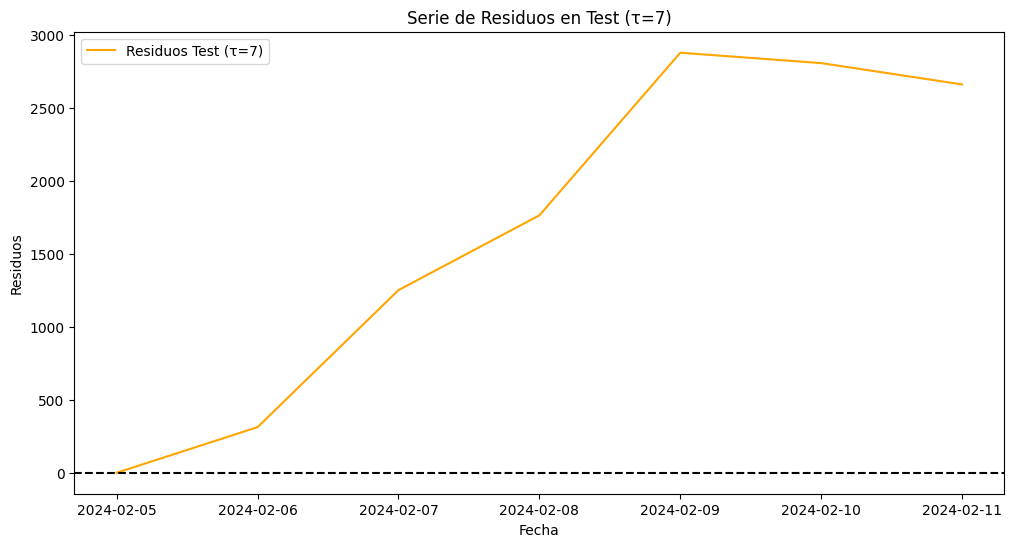

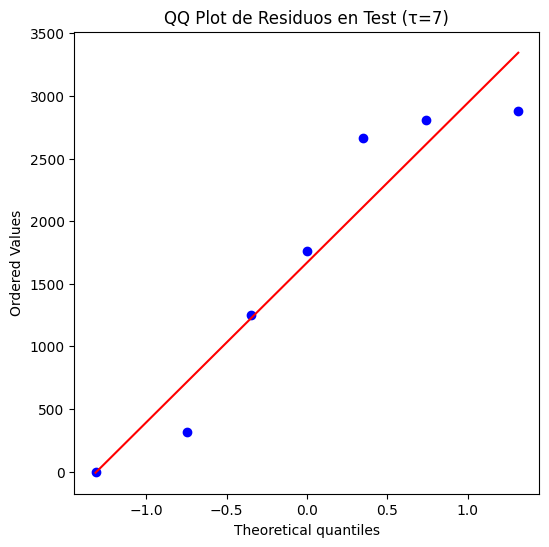

<Figure size 1000x500 with 0 Axes>

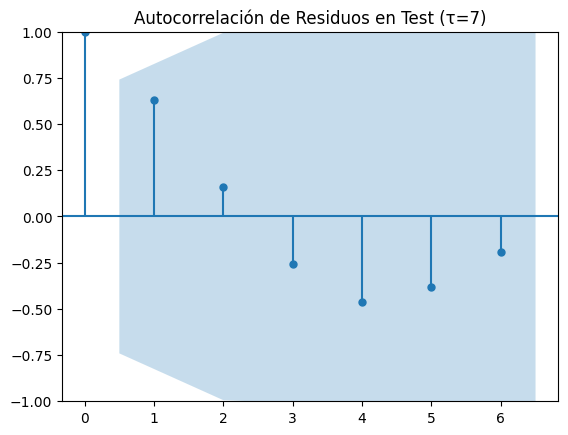

Resultados para τ = 14
                 Métrica                  Valor
0                    MAE              592.99957
1                    MSE          563144.080626
2                   RMSE             750.429264
3                   MAPE               1.145405
4                     R2               0.026111
5    Ljung-Box (p-value)               0.046531
6          BDS (p-value)  6.859181491635466e-17
7  Jarque-Bera (p-value)               0.789756


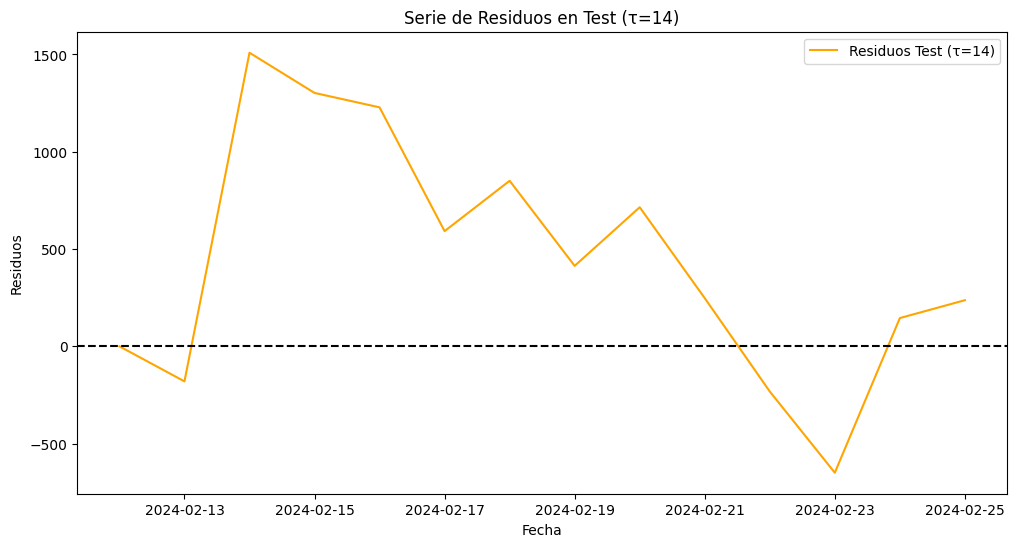

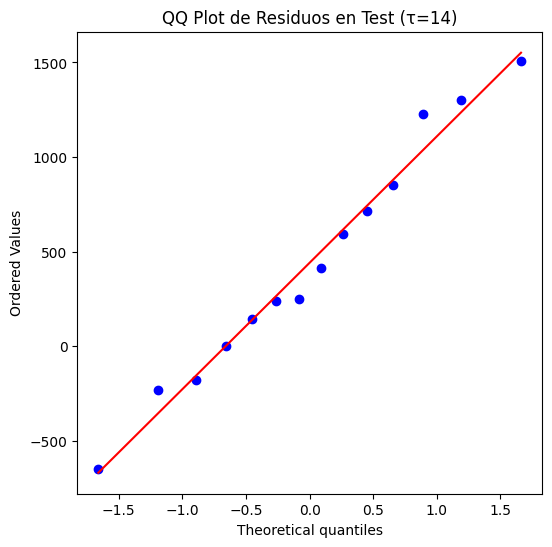

<Figure size 1000x500 with 0 Axes>

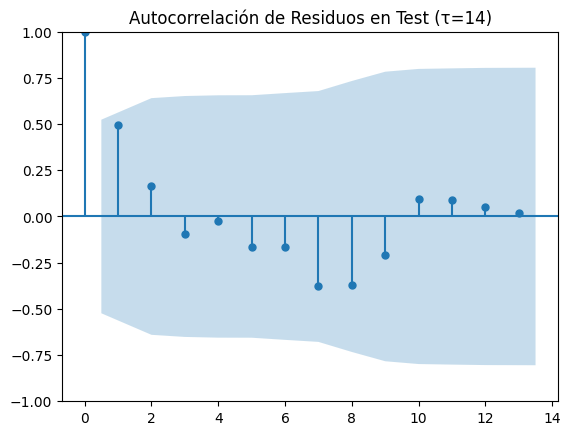

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE            2814.462051
1                    MSE        12741228.084718
2                   RMSE            3569.485689
3                   MAPE               4.447895
4                     R2               0.716172
5    Ljung-Box (p-value)               0.000088
6          BDS (p-value)  2.579386964705035e-09
7  Jarque-Bera (p-value)               0.724956


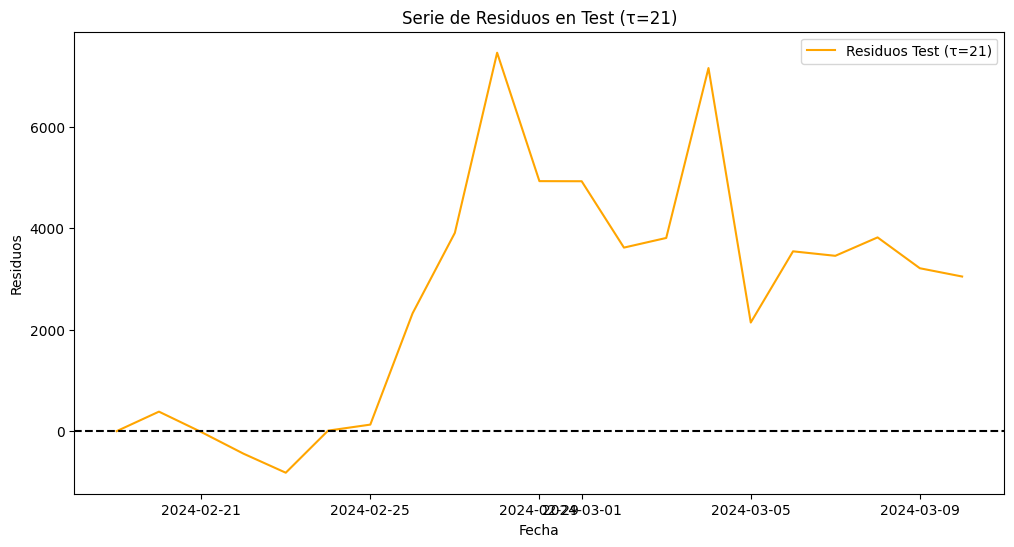

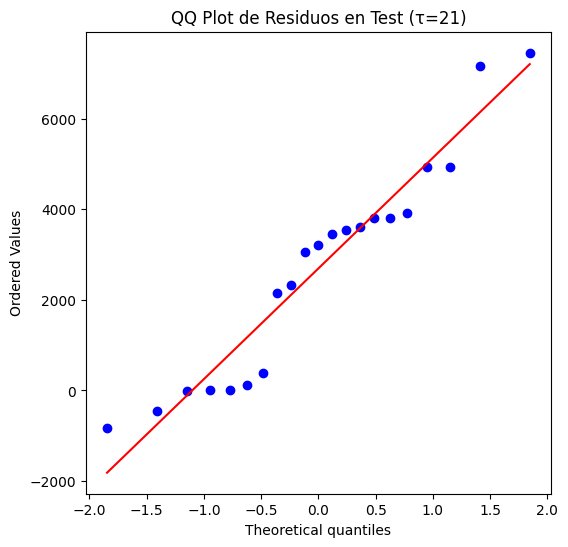

<Figure size 1000x500 with 0 Axes>

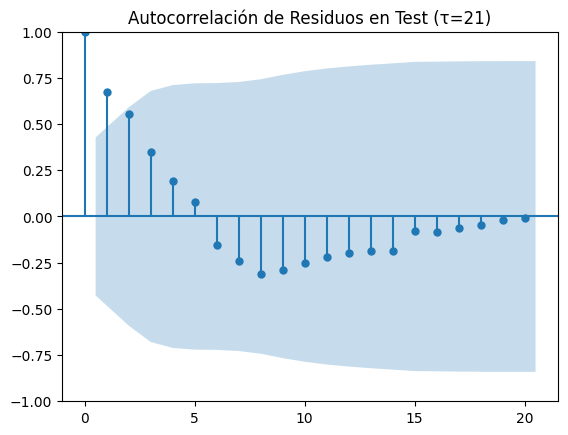

Resultados para τ = 28
                 Métrica                  Valor
0                    MAE            2759.089026
1                    MSE         10437558.14384
2                   RMSE            3230.720994
3                   MAPE               4.192194
4                     R2               0.427494
5    Ljung-Box (p-value)               0.000029
6          BDS (p-value)  1.865654328691599e-05
7  Jarque-Bera (p-value)               0.505192


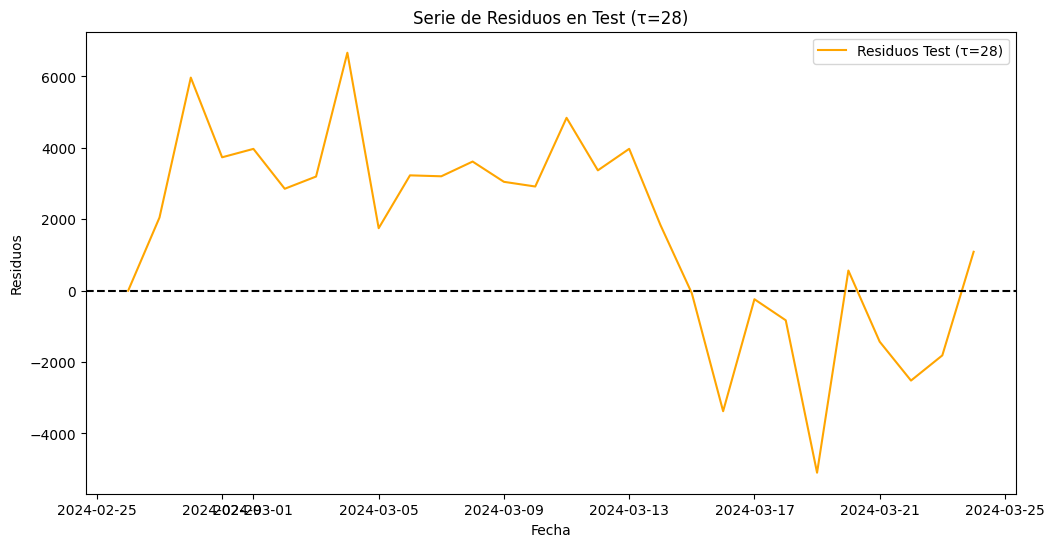

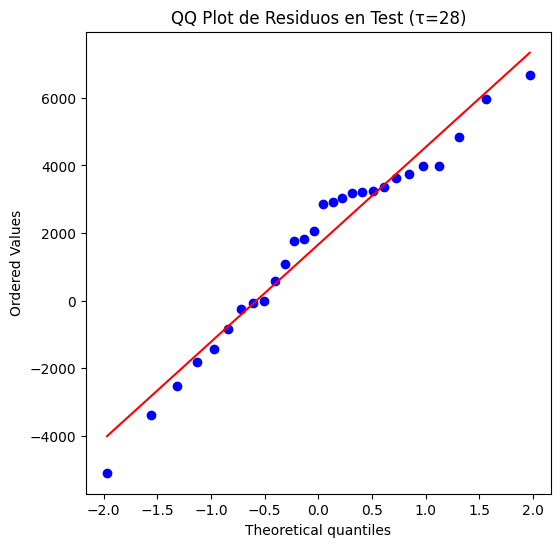

<Figure size 1000x500 with 0 Axes>

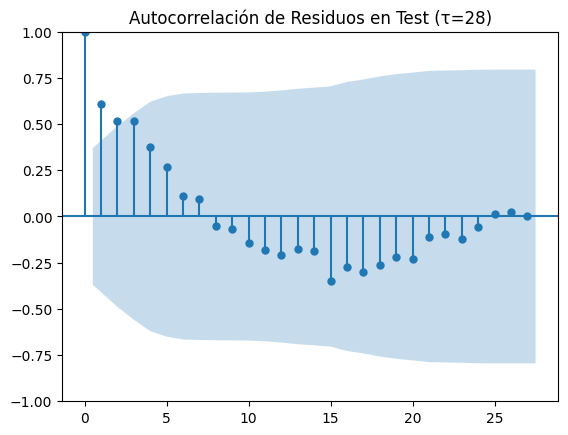

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Precio"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de precios
    train_series = train_data['Price'].values
    val_series = val_data['Price'].values
    test_series = test_data['Price'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica                  Valor
0                    MAE               0.037563
1                    MSE               0.002014
2                   RMSE               0.044873
3                   MAPE               0.161077
4                     R2               0.073466
5    Ljung-Box (p-value)               0.010624
6          BDS (p-value)  7.993565503834804e-25
7  Jarque-Bera (p-value)               0.689301


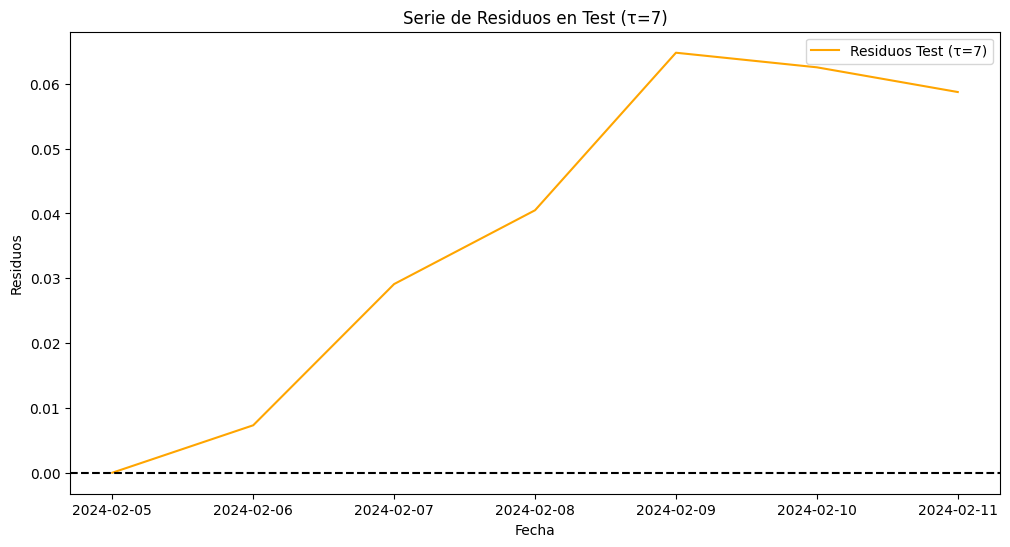

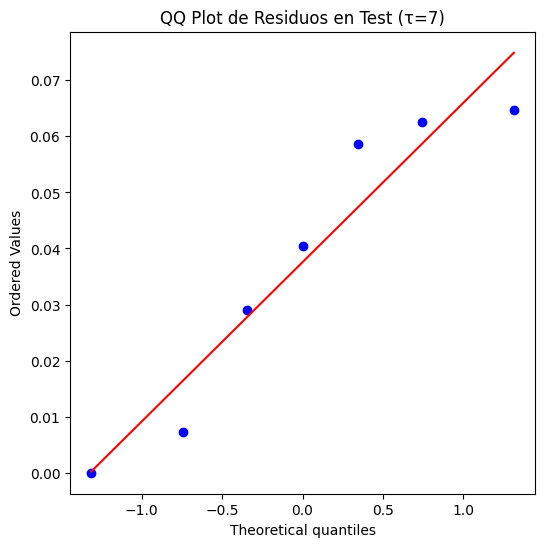

<Figure size 1000x500 with 0 Axes>

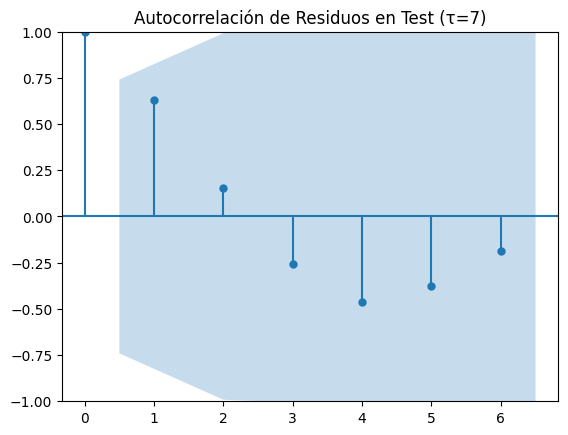

Resultados para τ = 14
                 Métrica                  Valor
0                    MAE               0.011867
1                    MSE               0.000225
2                   RMSE               0.015016
3                   MAPE               0.050663
4                     R2                0.02469
5    Ljung-Box (p-value)                0.05065
6          BDS (p-value)  7.586718562477651e-16
7  Jarque-Bera (p-value)                0.78198


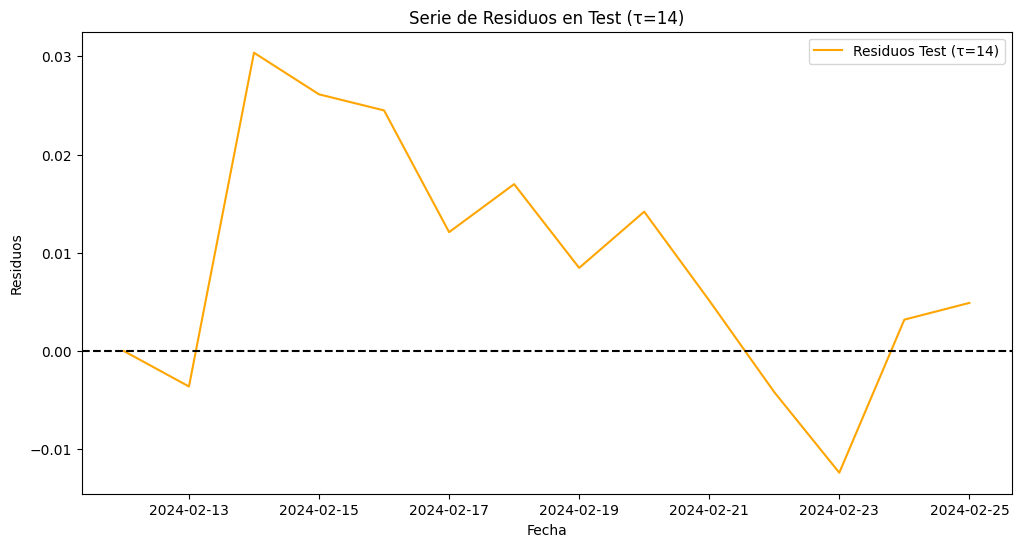

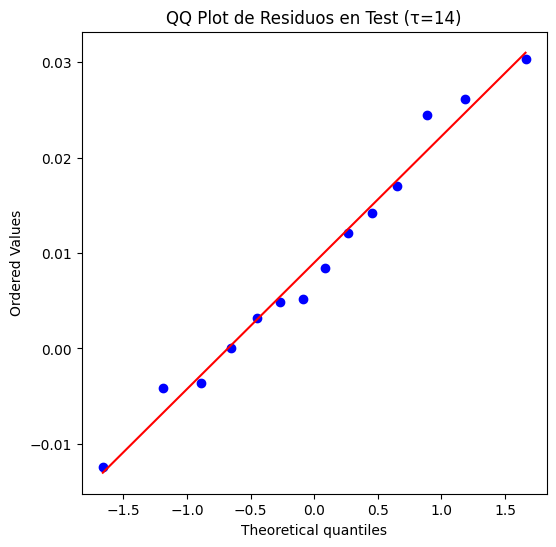

<Figure size 1000x500 with 0 Axes>

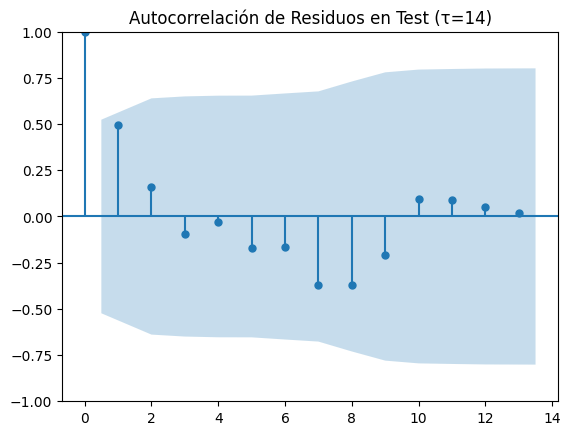

Resultados para τ = 21
                 Métrica                 Valor
0                    MAE               0.05015
1                    MSE              0.004001
2                   RMSE              0.063254
3                   MAPE              0.212219
4                     R2              0.716682
5    Ljung-Box (p-value)              0.000018
6          BDS (p-value)  9.23583906434974e-13
7  Jarque-Bera (p-value)               0.73229


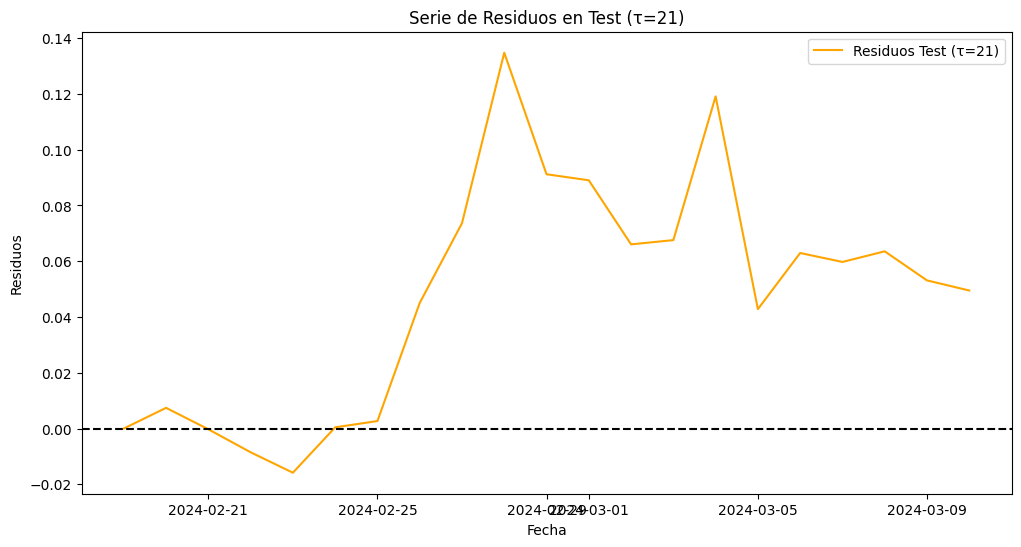

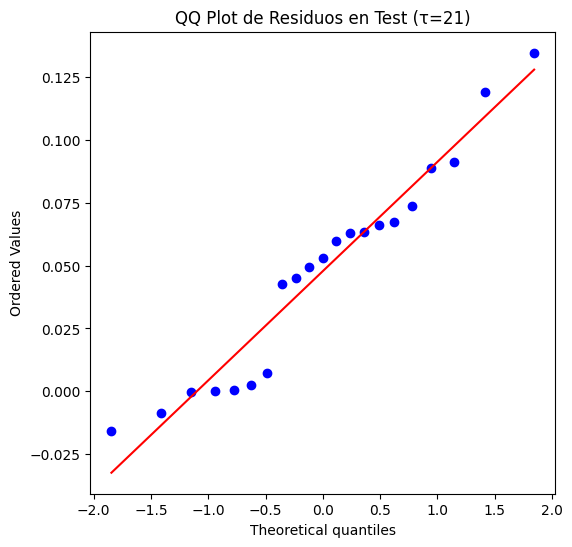

<Figure size 1000x500 with 0 Axes>

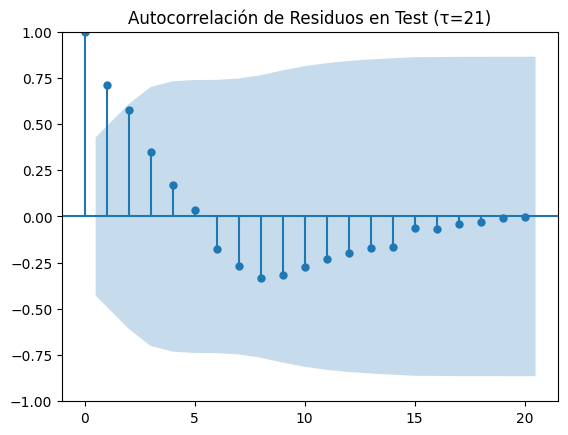

Resultados para τ = 28
                 Métrica                   Valor
0                    MAE                0.044853
1                    MSE                0.002801
2                   RMSE                0.052924
3                   MAPE                0.189446
4                     R2                0.428621
5    Ljung-Box (p-value)                0.000026
6          BDS (p-value)  3.0056614975136057e-05
7  Jarque-Bera (p-value)                0.622324


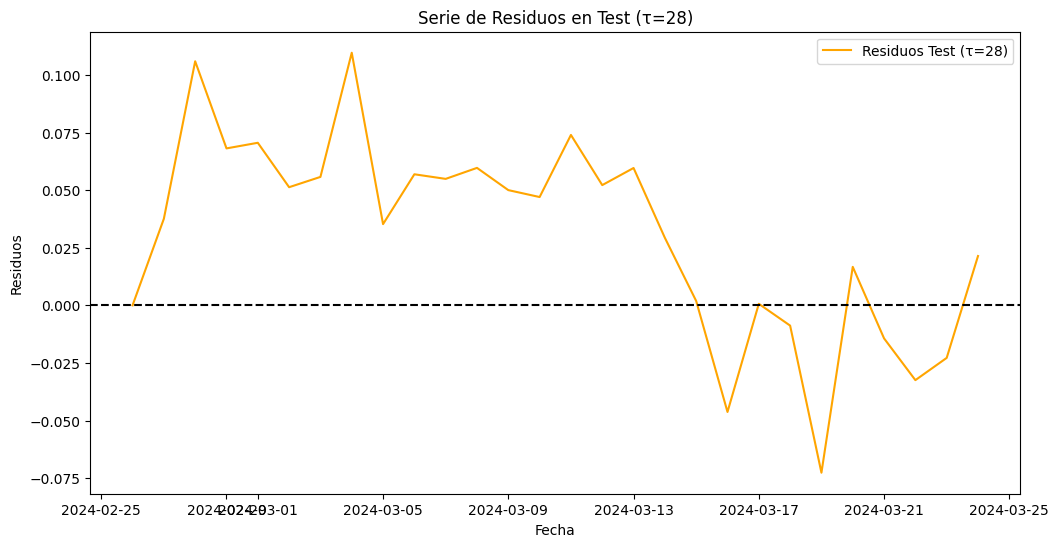

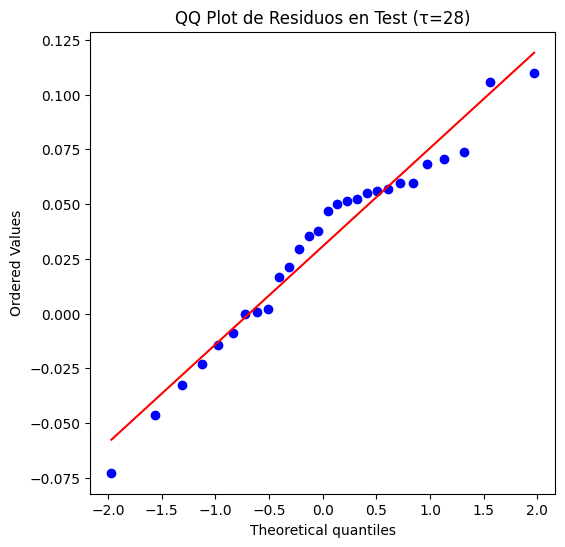

<Figure size 1000x500 with 0 Axes>

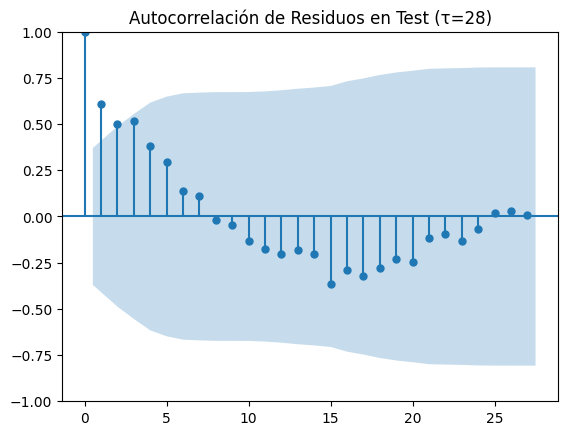

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Cumulative_Return"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna del Retorno Acumulado
    train_series = train_data['Cumulative_Return'].values
    val_series = val_data['Cumulative_Return'].values
    test_series = test_data['Cumulative_Return'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica      Valor
0                    MAE   0.002732
1                    MSE   0.000013
2                   RMSE   0.003619
3                   MAPE  17.865763
4                     R2  -0.007839
5    Ljung-Box (p-value)   0.149633
6          BDS (p-value)        0.0
7  Jarque-Bera (p-value)   0.773878


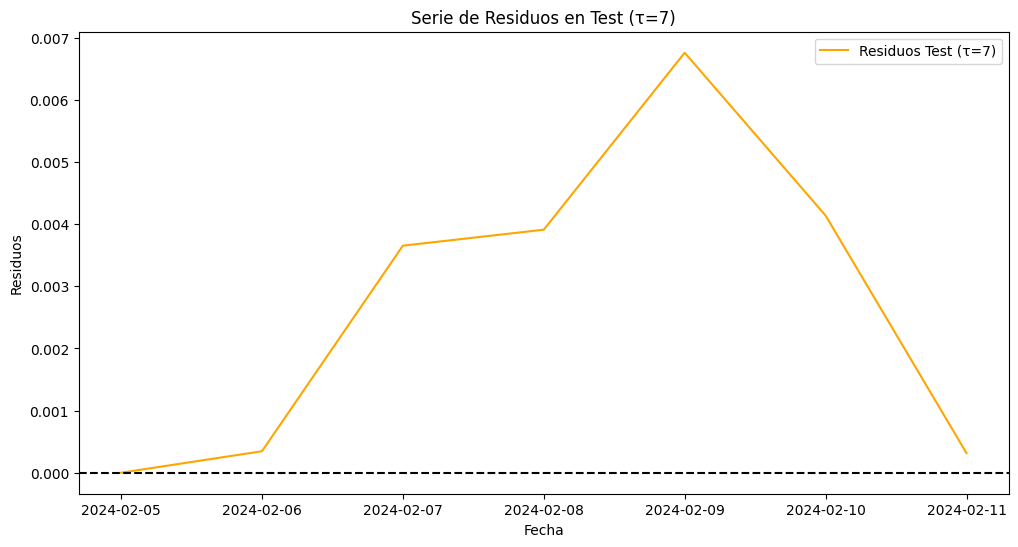

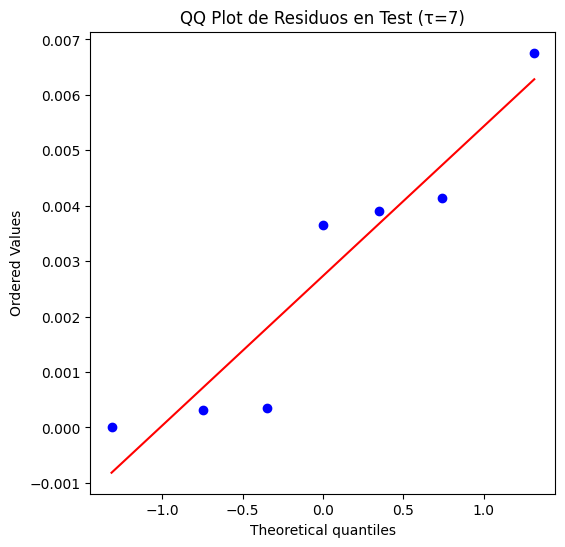

<Figure size 1000x500 with 0 Axes>

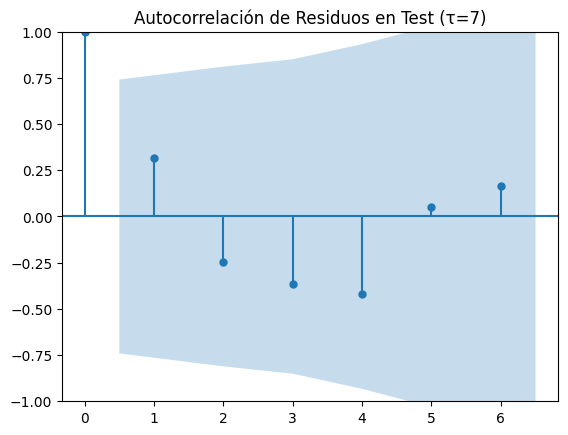

Resultados para τ = 14
                 Métrica                  Valor
0                    MAE               0.002634
1                    MSE               0.000011
2                   RMSE               0.003266
3                   MAPE              22.404583
4                     R2               0.345103
5    Ljung-Box (p-value)               0.000327
6          BDS (p-value)  4.168743262433421e-07
7  Jarque-Bera (p-value)               0.521452


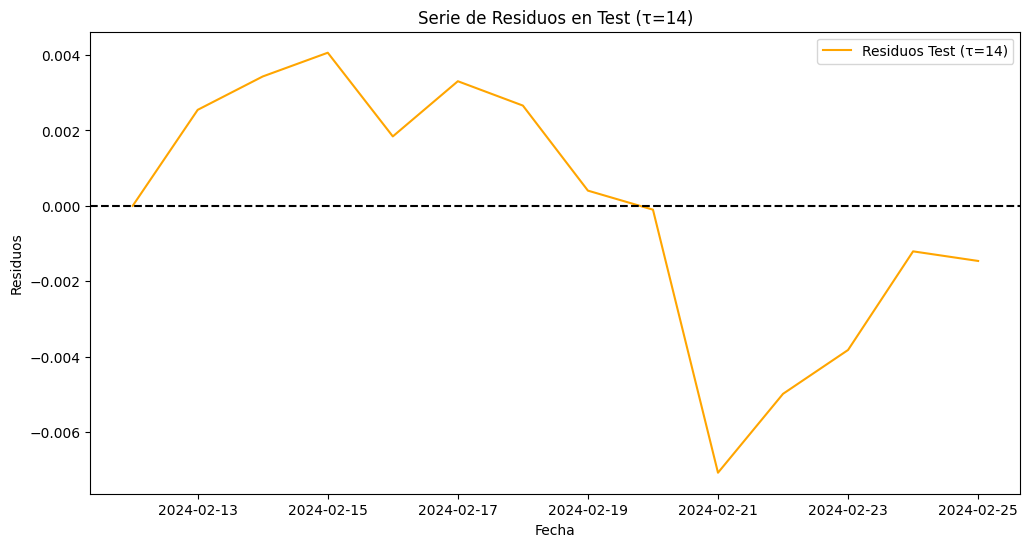

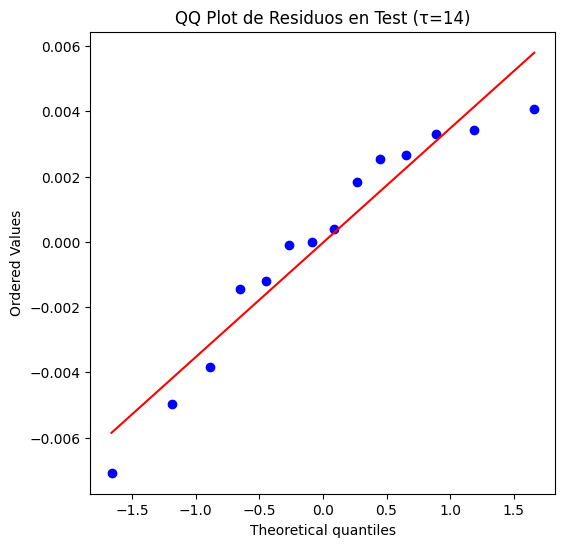

<Figure size 1000x500 with 0 Axes>

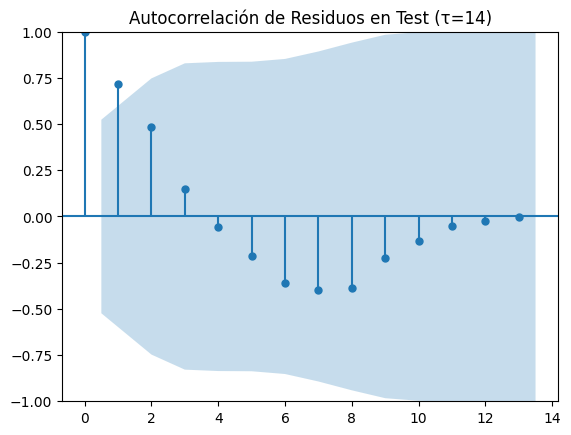

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE               0.006694
1                    MSE               0.000073
2                   RMSE               0.008559
3                   MAPE              25.518433
4                     R2               0.682919
5    Ljung-Box (p-value)               0.000001
6          BDS (p-value)  1.101019285304143e-31
7  Jarque-Bera (p-value)               0.662067


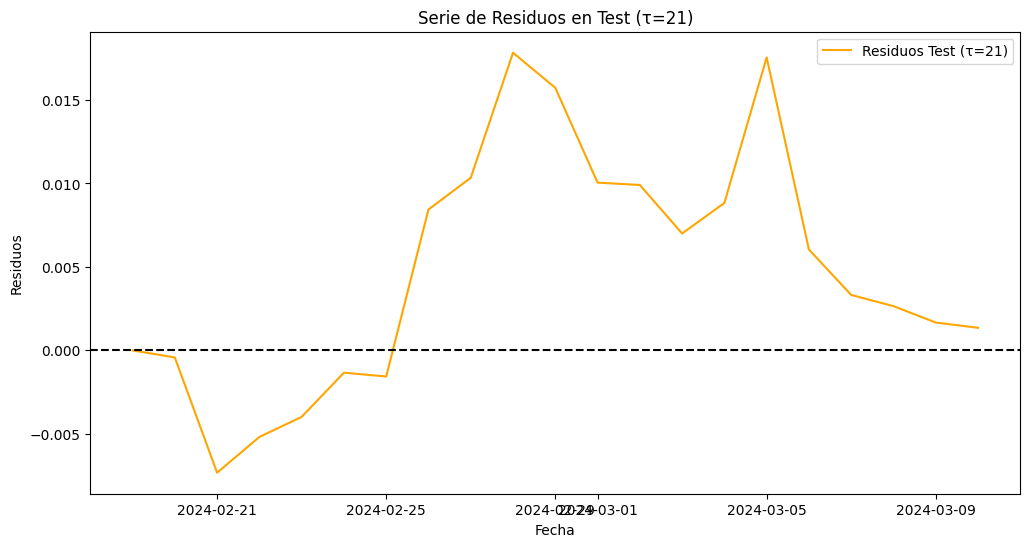

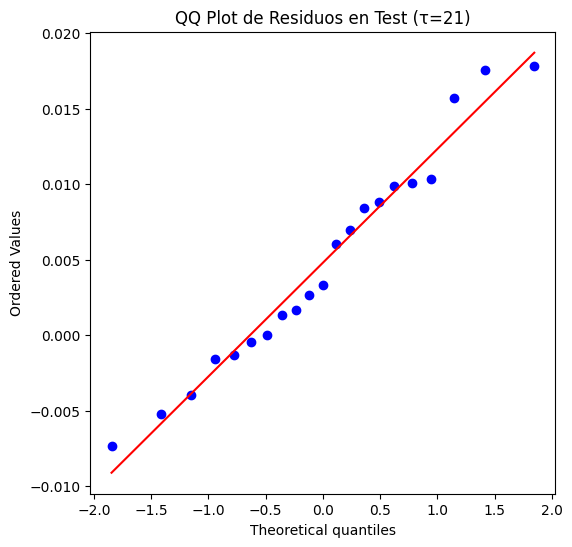

<Figure size 1000x500 with 0 Axes>

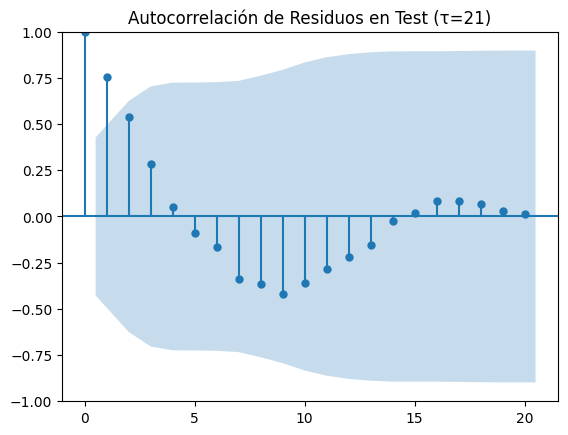

Resultados para τ = 28
                 Métrica                  Valor
0                    MAE               0.007826
1                    MSE               0.000092
2                   RMSE                0.00961
3                   MAPE              21.829471
4                     R2               0.405954
5    Ljung-Box (p-value)                    0.0
6          BDS (p-value)  5.805413304284706e-08
7  Jarque-Bera (p-value)               0.276391


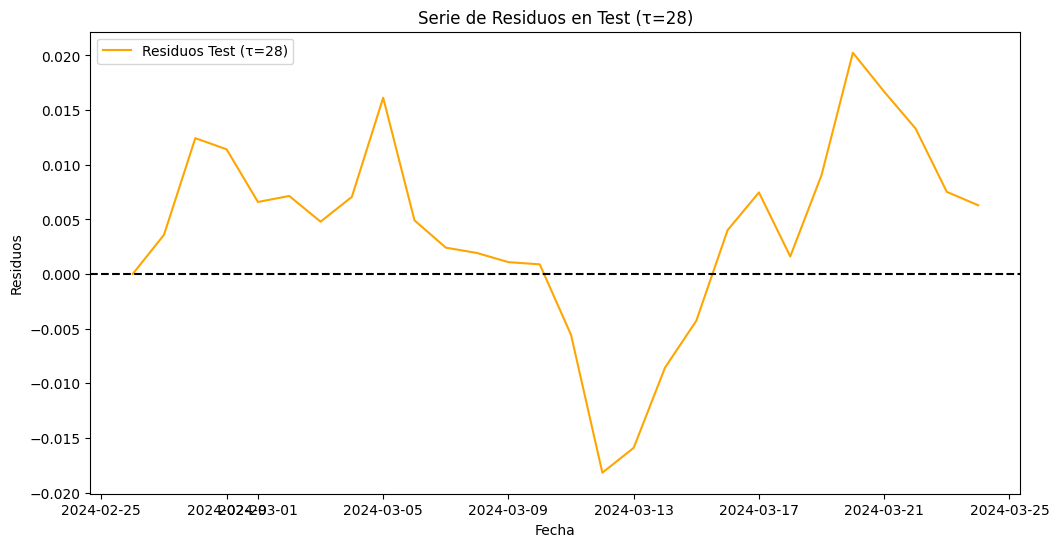

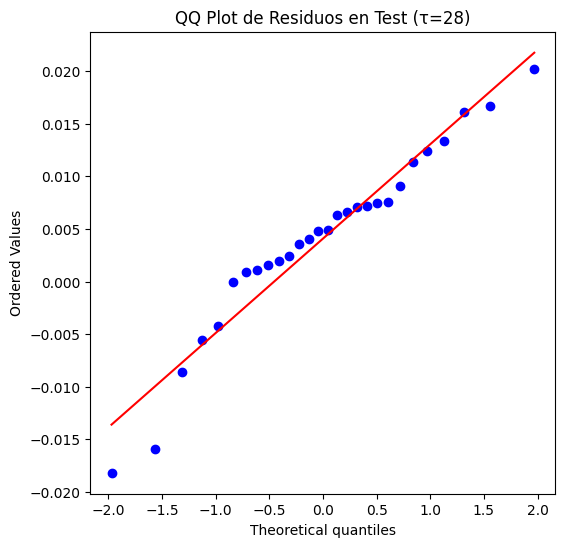

<Figure size 1000x500 with 0 Axes>

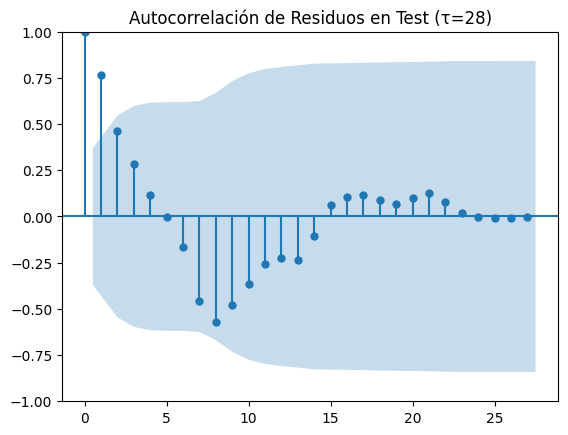

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Volatility_7d"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_7d"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de la Volatilidad para 07 dias
    train_series = train_data['Volatility_7d'].values
    val_series = val_data['Volatility_7d'].values
    test_series = test_data['Volatility_7d'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica                 Valor
0                    MAE              0.000346
1                    MSE                   0.0
2                   RMSE              0.000501
3                   MAPE              2.070731
4                     R2              0.106068
5    Ljung-Box (p-value)              0.458791
6          BDS (p-value)  0.054807398814541865
7  Jarque-Bera (p-value)              0.592149


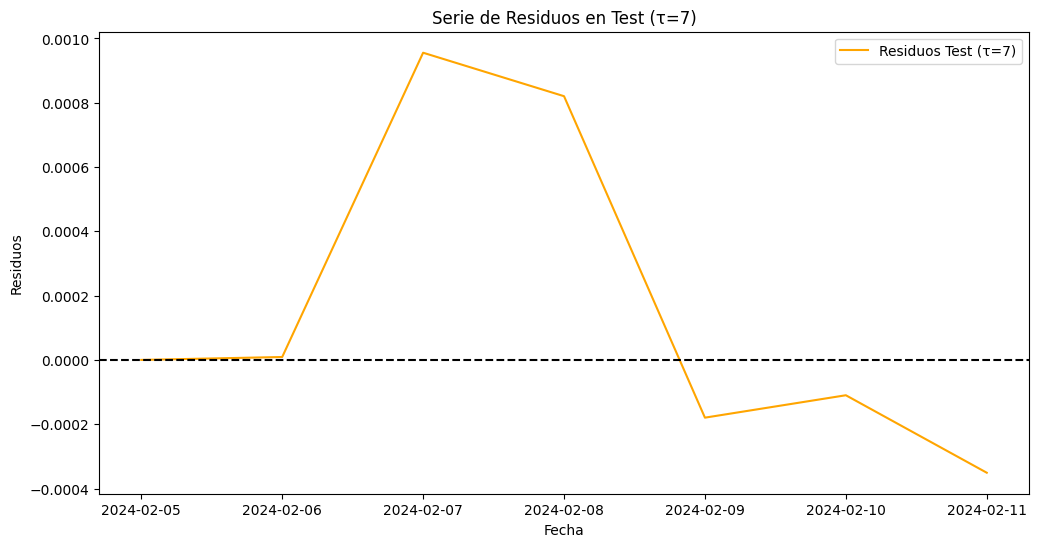

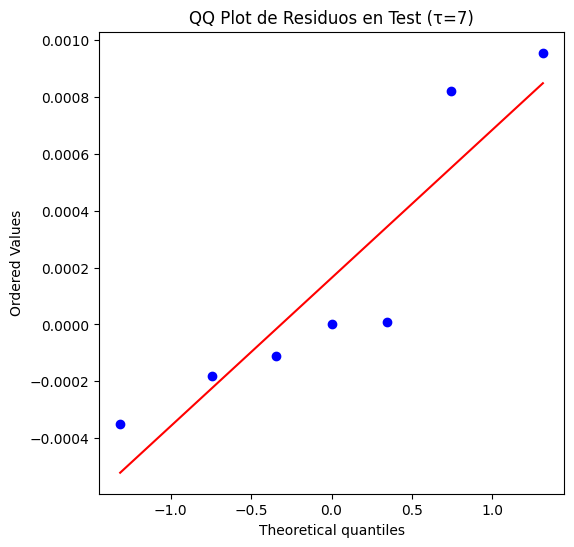

<Figure size 1000x500 with 0 Axes>

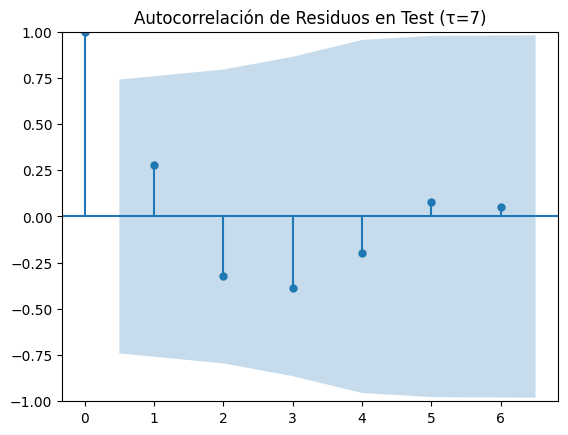

Resultados para τ = 14
                 Métrica                  Valor
0                    MAE               0.000455
1                    MSE                    0.0
2                   RMSE               0.000512
3                   MAPE               2.681394
4                     R2               0.190148
5    Ljung-Box (p-value)               0.150867
6          BDS (p-value)  5.797264284597484e-50
7  Jarque-Bera (p-value)                0.56783


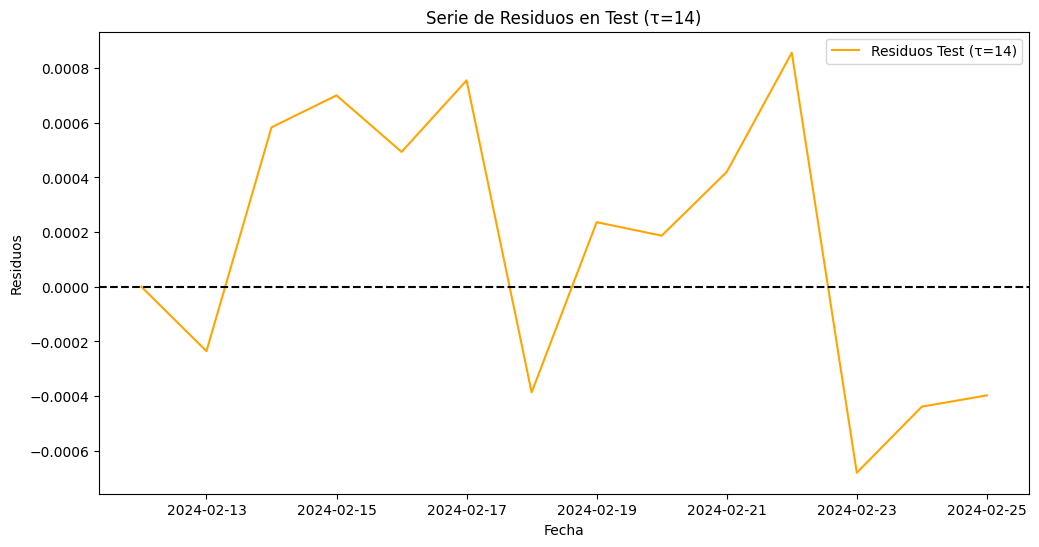

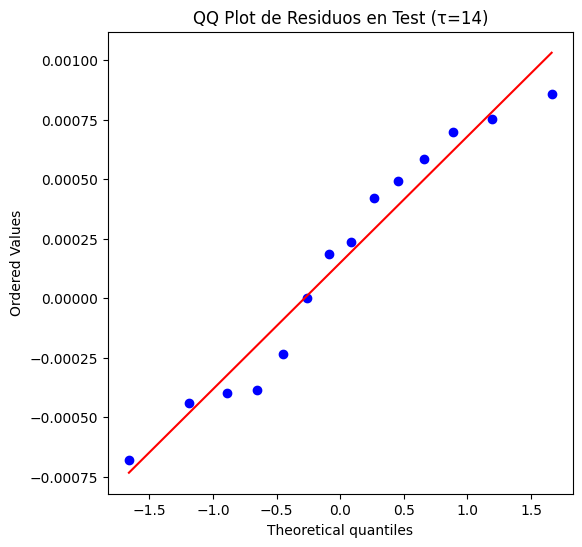

<Figure size 1000x500 with 0 Axes>

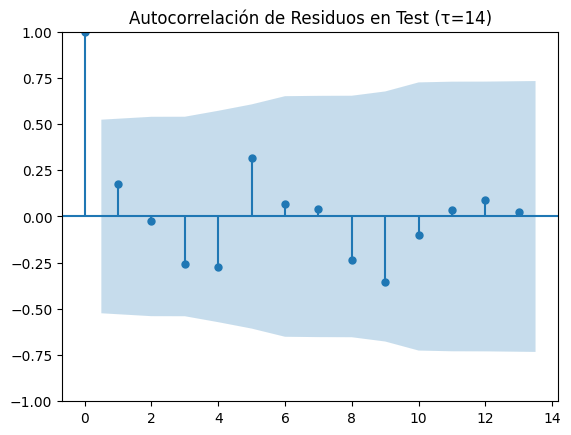

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE               0.004176
1                    MSE               0.000029
2                   RMSE               0.005413
3                   MAPE              12.580723
4                     R2               0.718553
5    Ljung-Box (p-value)               0.000004
6          BDS (p-value)  5.609924367454026e-37
7  Jarque-Bera (p-value)               0.485836


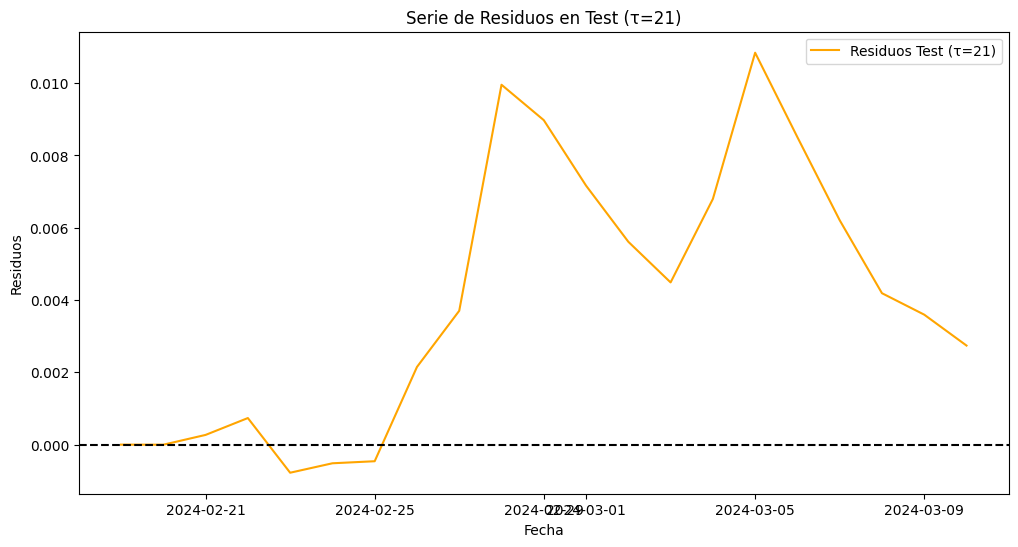

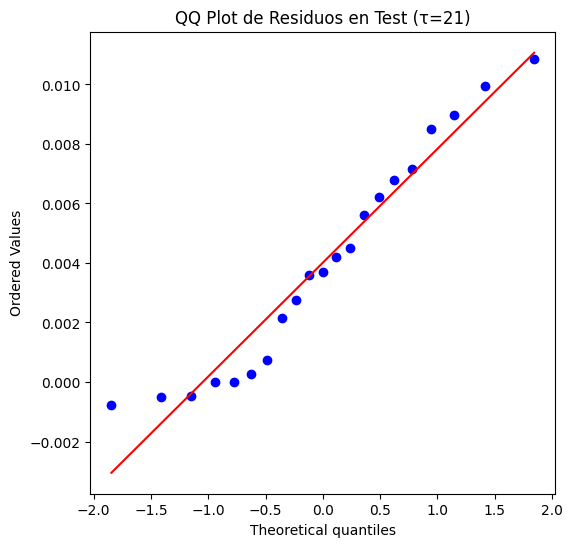

<Figure size 1000x500 with 0 Axes>

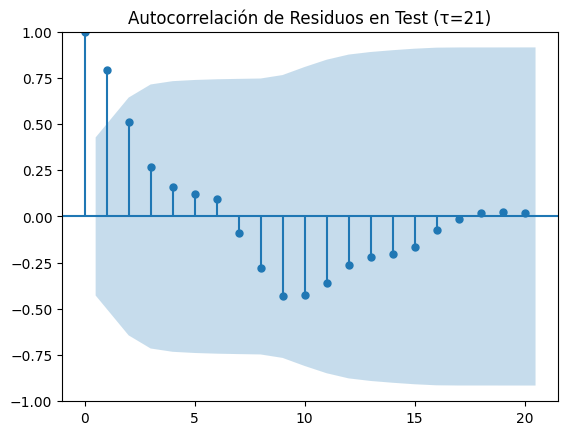

Resultados para τ = 28
                 Métrica                   Valor
0                    MAE                0.004206
1                    MSE                0.000024
2                   RMSE                0.004903
3                   MAPE               11.249736
4                     R2                0.467024
5    Ljung-Box (p-value)                0.000004
6          BDS (p-value)  2.9615956508120335e-05
7  Jarque-Bera (p-value)                0.782821


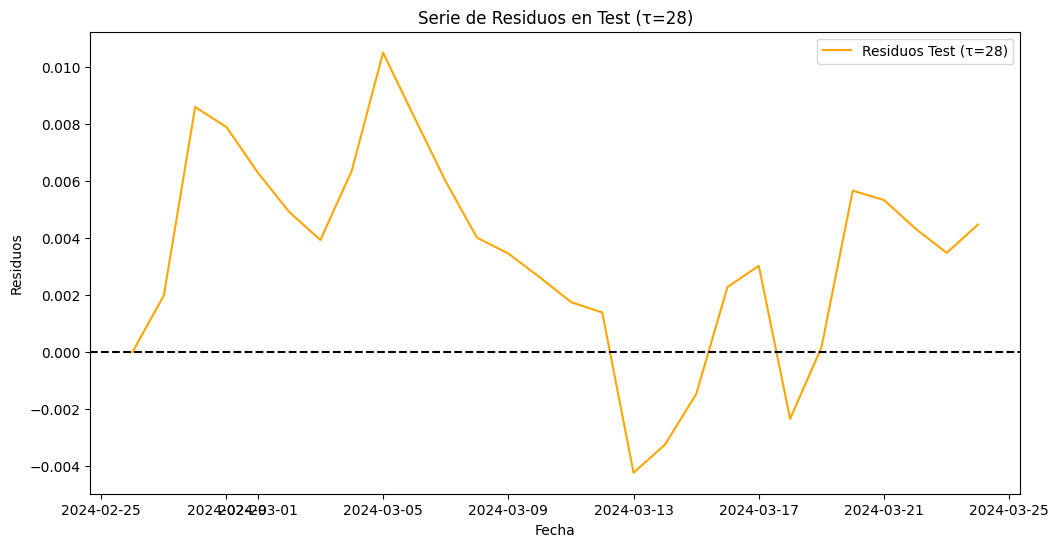

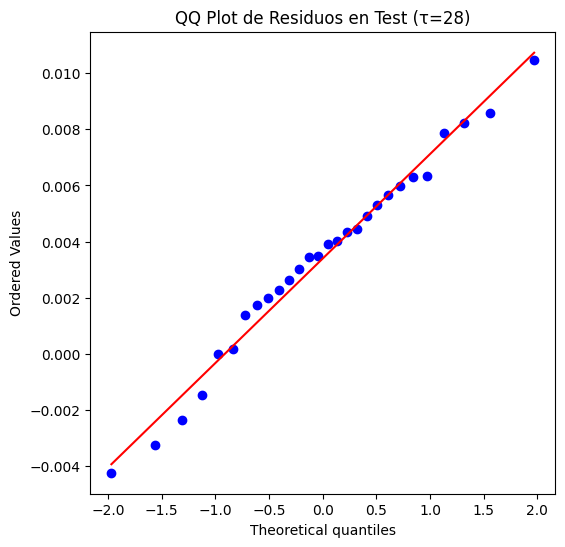

<Figure size 1000x500 with 0 Axes>

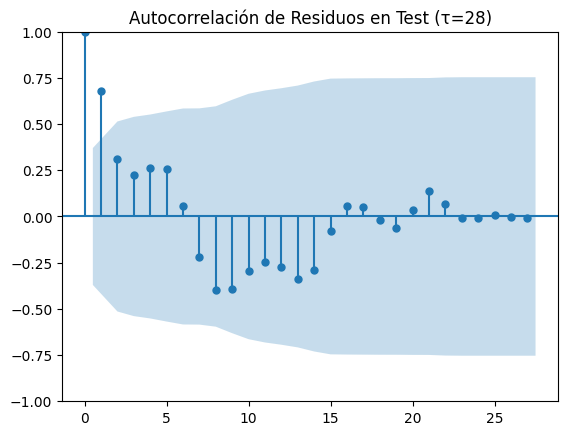

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Volatility_14d"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_14d"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de la Volatilidad para 14 dias
    train_series = train_data['Volatility_14d'].values
    val_series = val_data['Volatility_14d'].values
    test_series = test_data['Volatility_14d'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica                 Valor
0                    MAE              0.000445
1                    MSE                   0.0
2                   RMSE              0.000514
3                   MAPE              2.227228
4                     R2              0.218705
5    Ljung-Box (p-value)              0.897904
6          BDS (p-value)  0.006375035730260818
7  Jarque-Bera (p-value)              0.693142


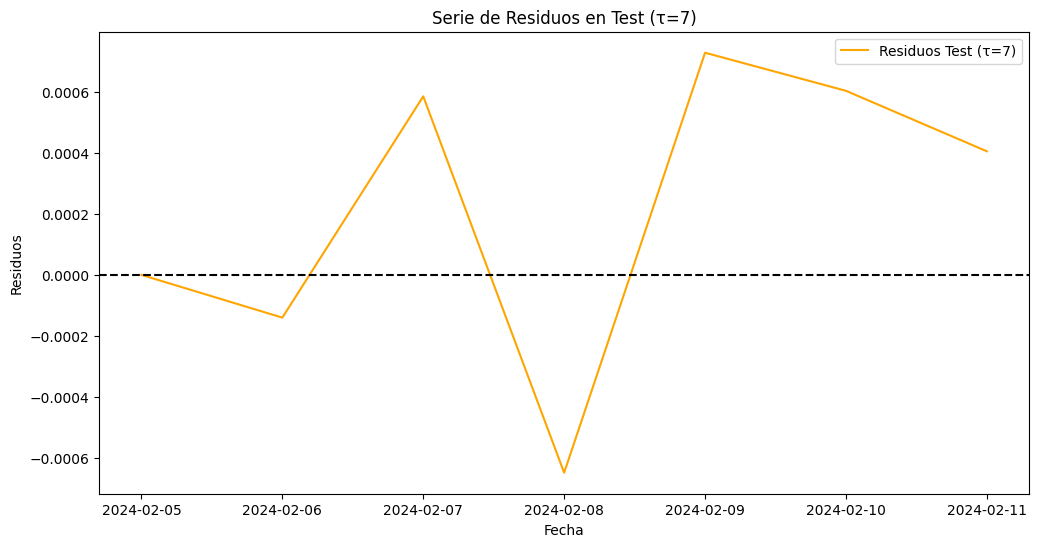

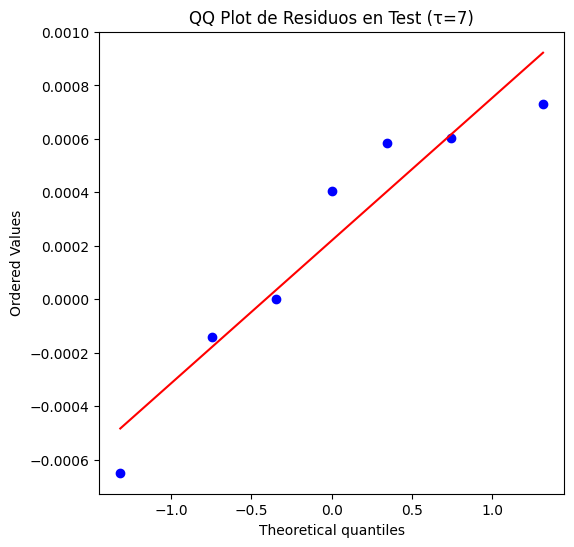

<Figure size 1000x500 with 0 Axes>

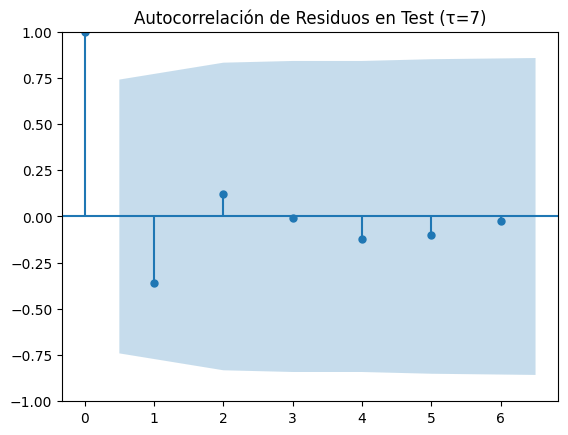

Resultados para τ = 14
                 Métrica               Valor
0                    MAE            0.000439
1                    MSE                 0.0
2                   RMSE            0.000548
3                   MAPE            2.610016
4                     R2            0.317536
5    Ljung-Box (p-value)            0.220962
6          BDS (p-value)  0.0822081976222411
7  Jarque-Bera (p-value)            0.605898


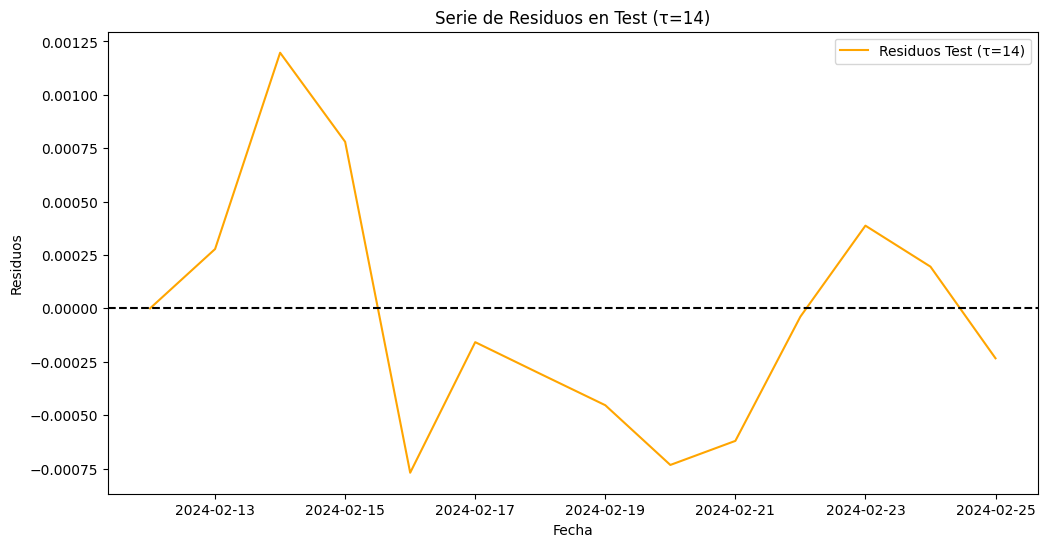

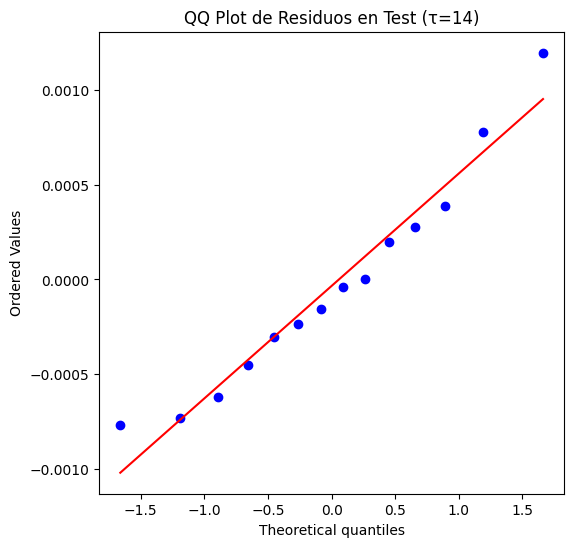

<Figure size 1000x500 with 0 Axes>

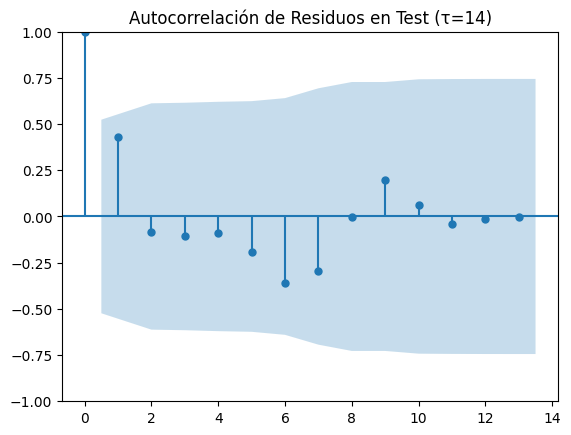

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE               0.003218
1                    MSE               0.000017
2                   RMSE               0.004125
3                   MAPE              11.029666
4                     R2               0.725984
5    Ljung-Box (p-value)               0.000002
6          BDS (p-value)  1.807509024911329e-57
7  Jarque-Bera (p-value)               0.486947


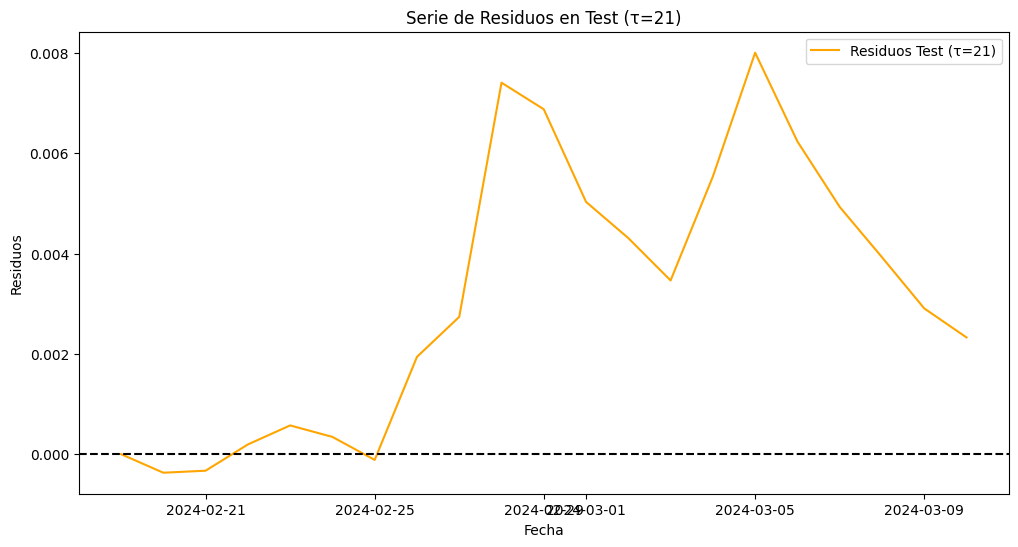

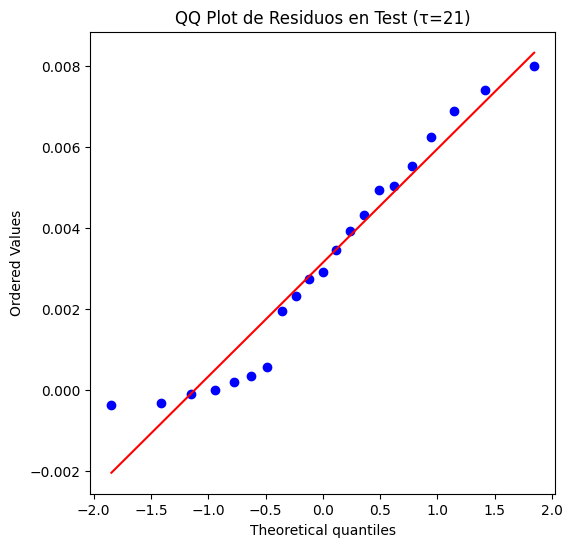

<Figure size 1000x500 with 0 Axes>

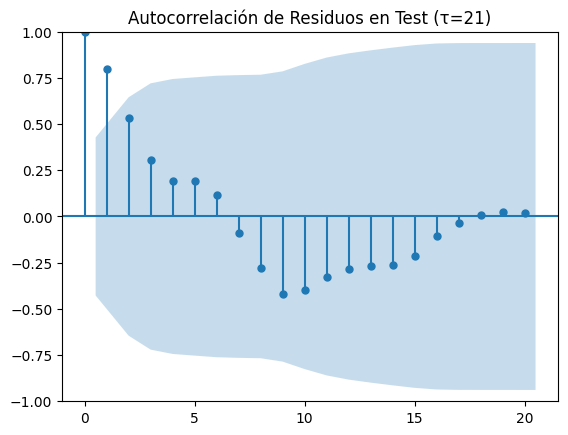

Resultados para τ = 28
                 Métrica                Valor
0                    MAE             0.003462
1                    MSE             0.000015
2                   RMSE             0.003872
3                   MAPE             9.998507
4                     R2             0.707474
5    Ljung-Box (p-value)             0.002078
6          BDS (p-value)  0.05892935377347646
7  Jarque-Bera (p-value)             0.729403


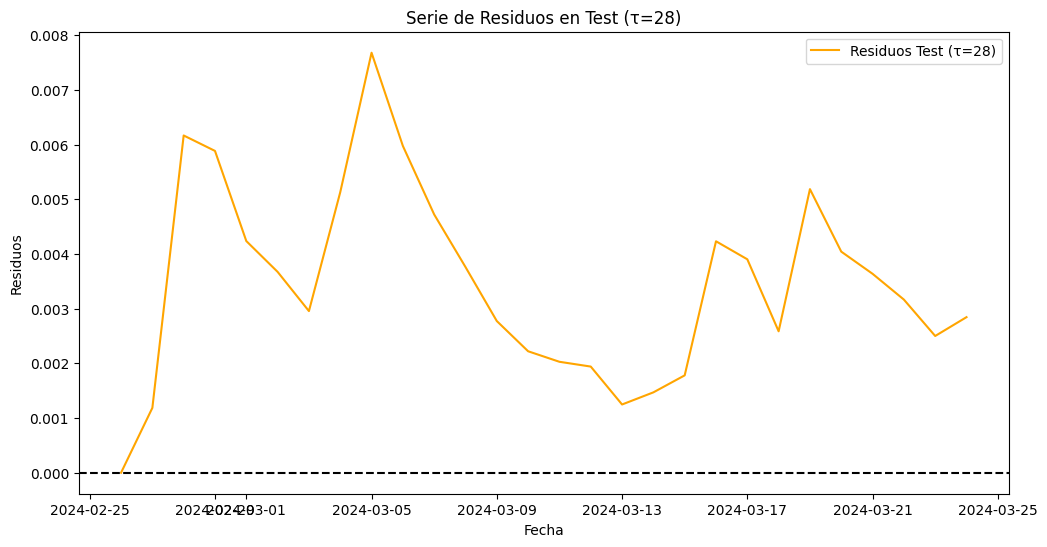

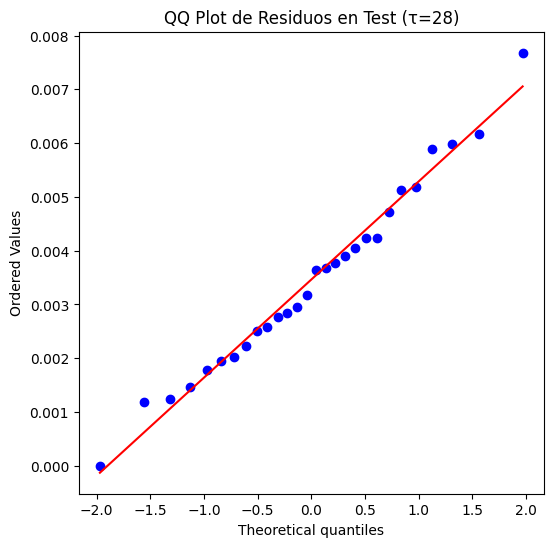

<Figure size 1000x500 with 0 Axes>

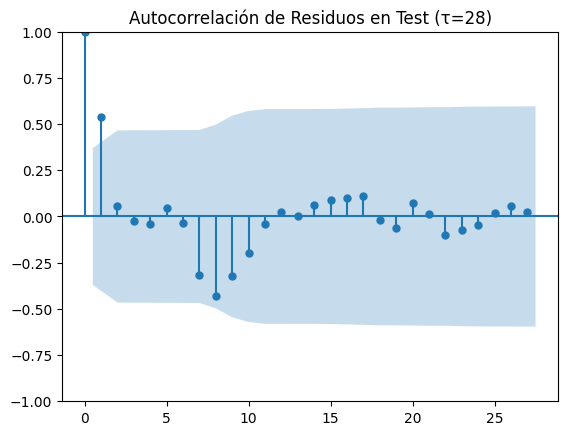

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Volatility_21d"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_21d"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de la Volatilidad para 21 dias
    train_series = train_data['Volatility_21d'].values
    val_series = val_data['Volatility_21d'].values
    test_series = test_data['Volatility_21d'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


Resultados para τ = 7
                 Métrica                 Valor
0                    MAE              0.001095
1                    MSE              0.000002
2                   RMSE              0.001456
3                   MAPE               5.28325
4                     R2              0.272089
5    Ljung-Box (p-value)              0.262786
6          BDS (p-value)  0.025237089354517666
7  Jarque-Bera (p-value)              0.618571


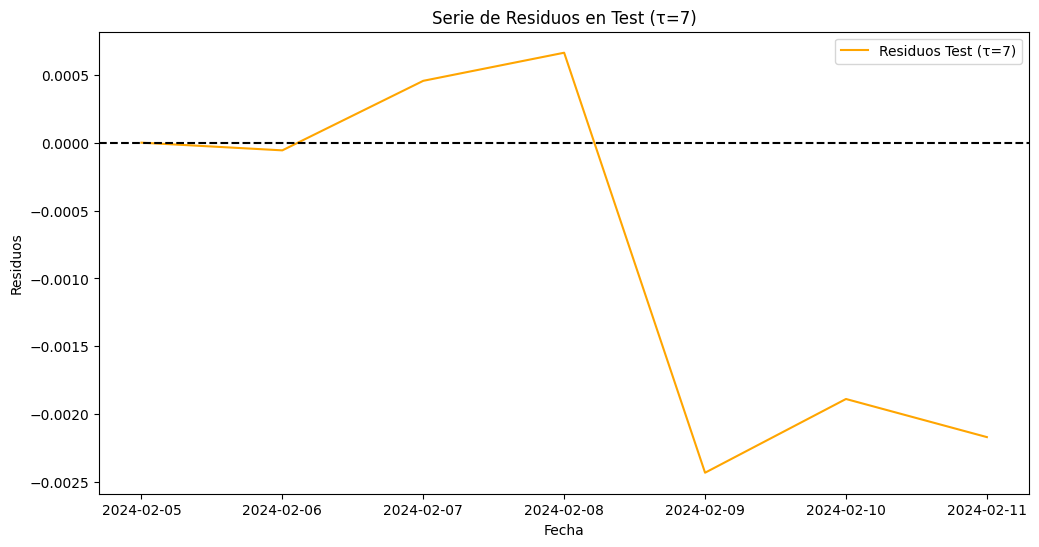

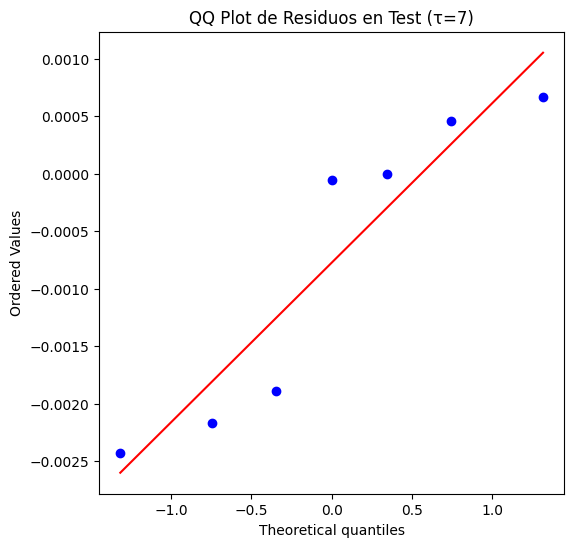

<Figure size 1000x500 with 0 Axes>

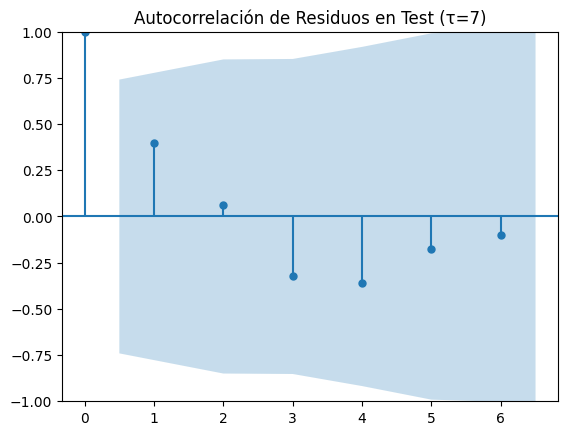

Resultados para τ = 14
                 Métrica                Valor
0                    MAE             0.001021
1                    MSE             0.000002
2                   RMSE             0.001299
3                   MAPE             5.995267
4                     R2             0.529255
5    Ljung-Box (p-value)             0.025611
6          BDS (p-value)  0.06840193413328799
7  Jarque-Bera (p-value)             0.832433


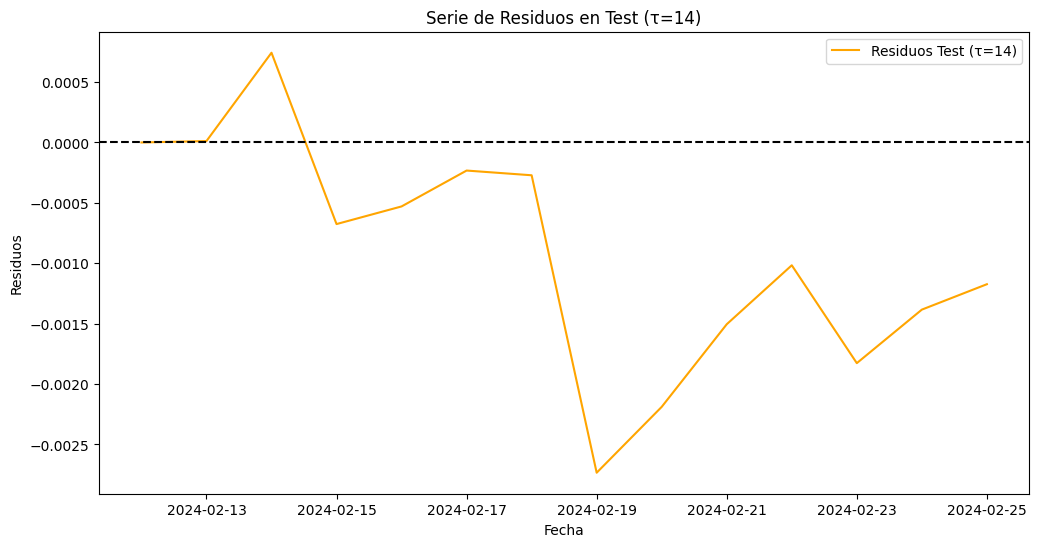

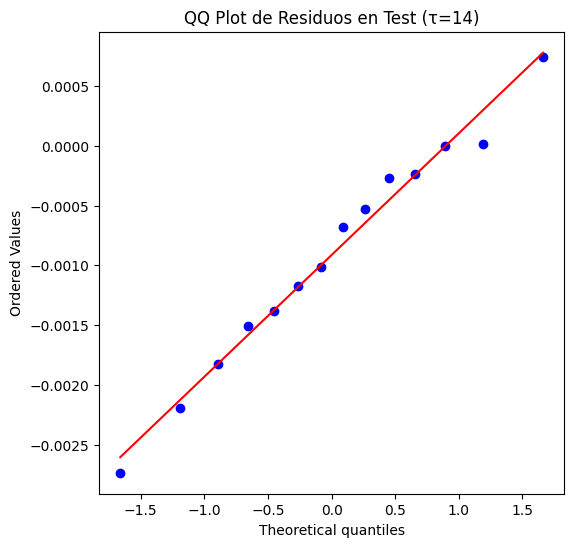

<Figure size 1000x500 with 0 Axes>

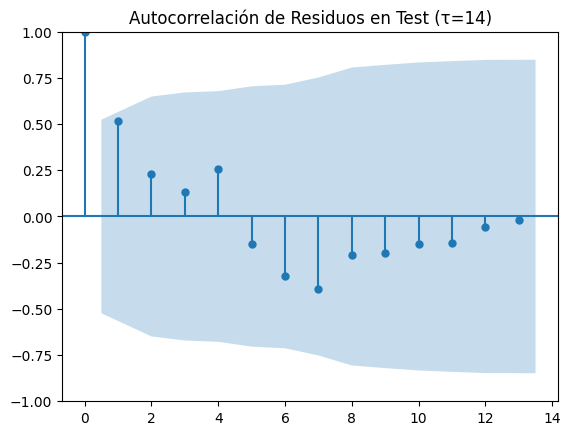

Resultados para τ = 21
                 Métrica                  Valor
0                    MAE               0.002608
1                    MSE               0.000011
2                   RMSE               0.003343
3                   MAPE               9.798349
4                     R2               0.719415
5    Ljung-Box (p-value)               0.000005
6          BDS (p-value)  7.847150532494606e-47
7  Jarque-Bera (p-value)               0.478852


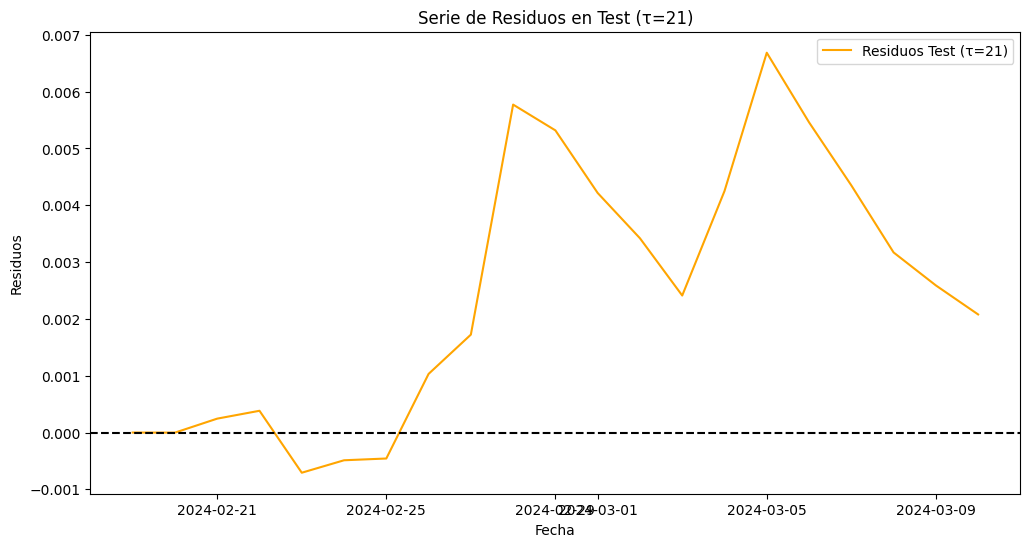

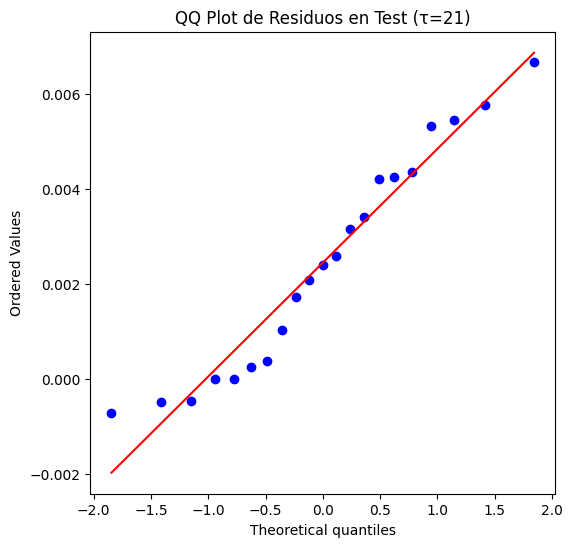

<Figure size 1000x500 with 0 Axes>

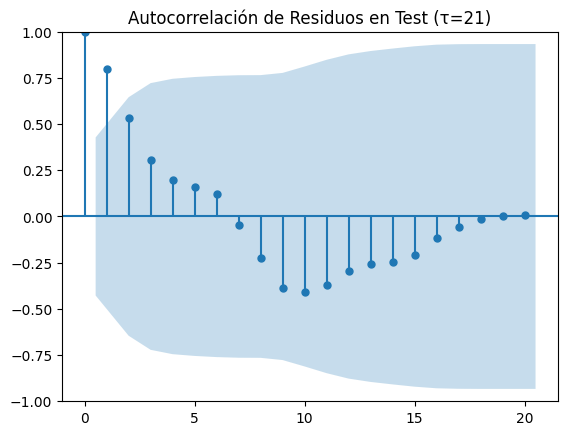

Resultados para τ = 28
                 Métrica                 Valor
0                    MAE              0.003375
1                    MSE              0.000014
2                   RMSE              0.003797
3                   MAPE             10.291224
4                     R2              0.732755
5    Ljung-Box (p-value)              0.000002
6          BDS (p-value)  2.03821140515232e-09
7  Jarque-Bera (p-value)              0.648471


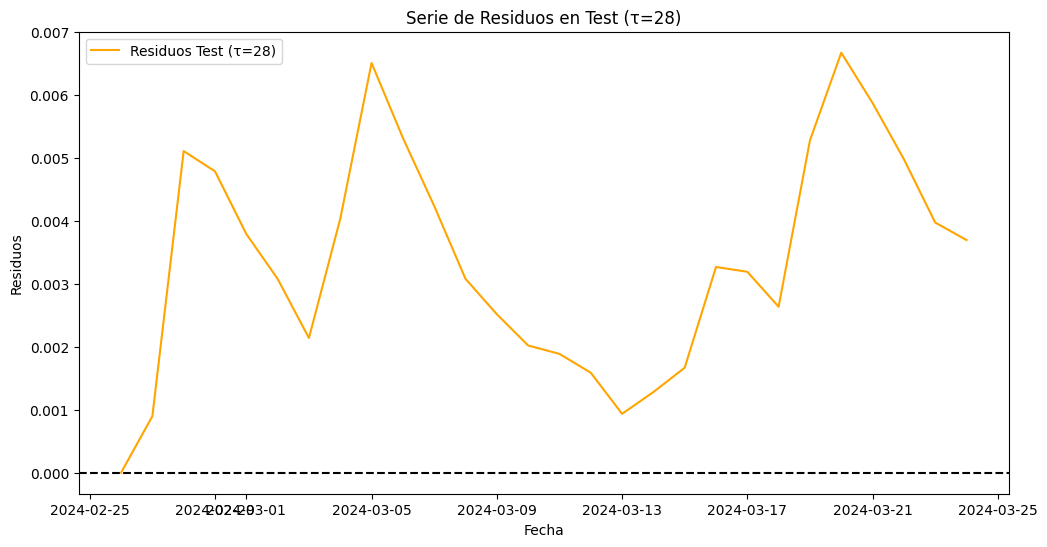

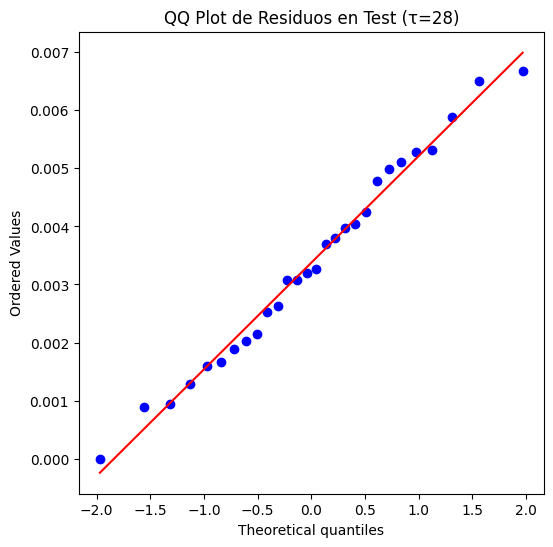

<Figure size 1000x500 with 0 Axes>

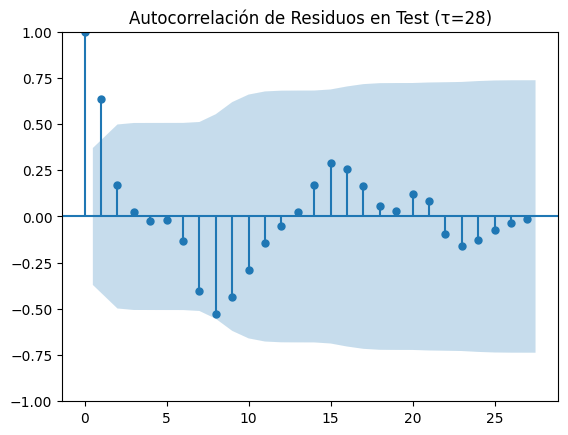

In [ ]:
# Simple Exponential Smoothing (Sin Librería) para la columna "Volatility_28d"

import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
 
# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_28d"]]

# Función para Suavizamiento Exponencial Simple (SES)
def simple_exponential_smoothing(series, alpha):
    """
    Aplica el Suavizamiento Exponencial Simple (SES) a una serie temporal.
    Parámetros:
        series (array-like): Serie de tiempo original.
        alpha (float): Factor de suavizado (0 < alpha ≤ 1).
    Retorna:
        np.array: Serie suavizada.
    """
    smoothed_values = np.zeros(len(series))
    smoothed_values[0] = series[0]  # Inicializar con el primer valor
    for t in range(1, len(series)):
        smoothed_values[t] = alpha * series[t] + (1 - alpha) * smoothed_values[t-1]
    return smoothed_values

# Definir los tamaños de validación y test
tau_values = [7, 14, 21, 28]
for tau in tau_values:
    val_size = tau
    test_size = tau
    train_size = len(df) - (28 + 28)
    
    train_data = df.iloc[:train_size]
    val_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:train_size + val_size + test_size]
    
    # Extraer la columna de la Volatilidad para 28 dias
    train_series = train_data['Volatility_28d'].values
    val_series = val_data['Volatility_28d'].values
    test_series = test_data['Volatility_28d'].values
    
    # Aplicar SES con un alpha de 0.2
    alpha = 0.2
    smoothed_train = simple_exponential_smoothing(train_series, alpha)
    smoothed_val = simple_exponential_smoothing(val_series, alpha)
    smoothed_test = simple_exponential_smoothing(test_series, alpha)
    
    # Calcular residuos
    test_residuals = test_series - smoothed_test

    # Evaluar en test
    test_mae, test_mse, test_rmse, test_mape, test_r2 = mean_absolute_error(test_series, smoothed_test), \
                                                         mean_squared_error(test_series, smoothed_test), \
                                                         np.sqrt(mean_squared_error(test_series, smoothed_test)), \
                                                         np.mean(np.abs((test_series - smoothed_test) / test_series)) * 100, \
                                                         r2_score(test_series, smoothed_test)
    
    # Ajustar número de lags para Ljung-Box
    max_lags = min(10, len(test_residuals) - 1)
    test_ljung_box_pvalue = acorr_ljungbox(test_residuals, lags=[max_lags], return_df=True)['lb_pvalue'].values[0] if max_lags > 0 else np.nan
    
    test_bds_stat, test_bds_pvalue = bds(test_residuals)
    test_jarque_bera_pvalue = jarque_bera(test_residuals)[1]
    
    # Crear DataFrame de resultados en test
    test_results = pd.DataFrame({
        'Métrica': ['MAE', 'MSE', 'RMSE', 'MAPE', 'R2', 'Ljung-Box (p-value)', 'BDS (p-value)', 'Jarque-Bera (p-value)'],
        'Valor': [test_mae, test_mse, test_rmse, test_mape, test_r2, test_ljung_box_pvalue, test_bds_pvalue, test_jarque_bera_pvalue]
    })
    print(f"Resultados para τ = {tau}")
    print(test_results)
    
    # Graficar residuos en test
    plt.figure(figsize=(12,6))
    plt.plot(test_data.index, test_residuals, label=f'Residuos Test (τ={tau})', color='orange')
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Fecha')
    plt.ylabel('Residuos')
    plt.title(f'Serie de Residuos en Test (τ={tau})')
    plt.legend()
    plt.show()
    
    # QQPlot en test
    plt.figure(figsize=(6,6))
    probplot(test_residuals, dist="norm", plot=plt)
    plt.title(f"QQ Plot de Residuos en Test (τ={tau})")
    plt.show()
    
    # ACF de Residuos en test
    max_lags_acf = min(30, len(test_residuals) - 1)  # Ajustar lags para evitar errores
    if max_lags_acf > 0:
        plt.figure(figsize=(10,5))
        plot_acf(test_residuals, lags=max_lags_acf)
        plt.title(f"Autocorrelación de Residuos en Test (τ={tau})")
        plt.show()


### Simple Exponential Smoothing (con librería)

Price

Tamaño de train: 3499
Tamaño de validación: 749
Tamaño de test: 751

Métricas del modelo (Entrenamiento) + Pruebas de hipótesis:
       MAPE       MAE        RMSE           MSE        R2  Ljung-Box p-value  \
0  3.287273  70.27908  204.939594  42000.237219  0.996586       1.923596e-21   

   Jarque-Bera p-value  
0                  0.0  


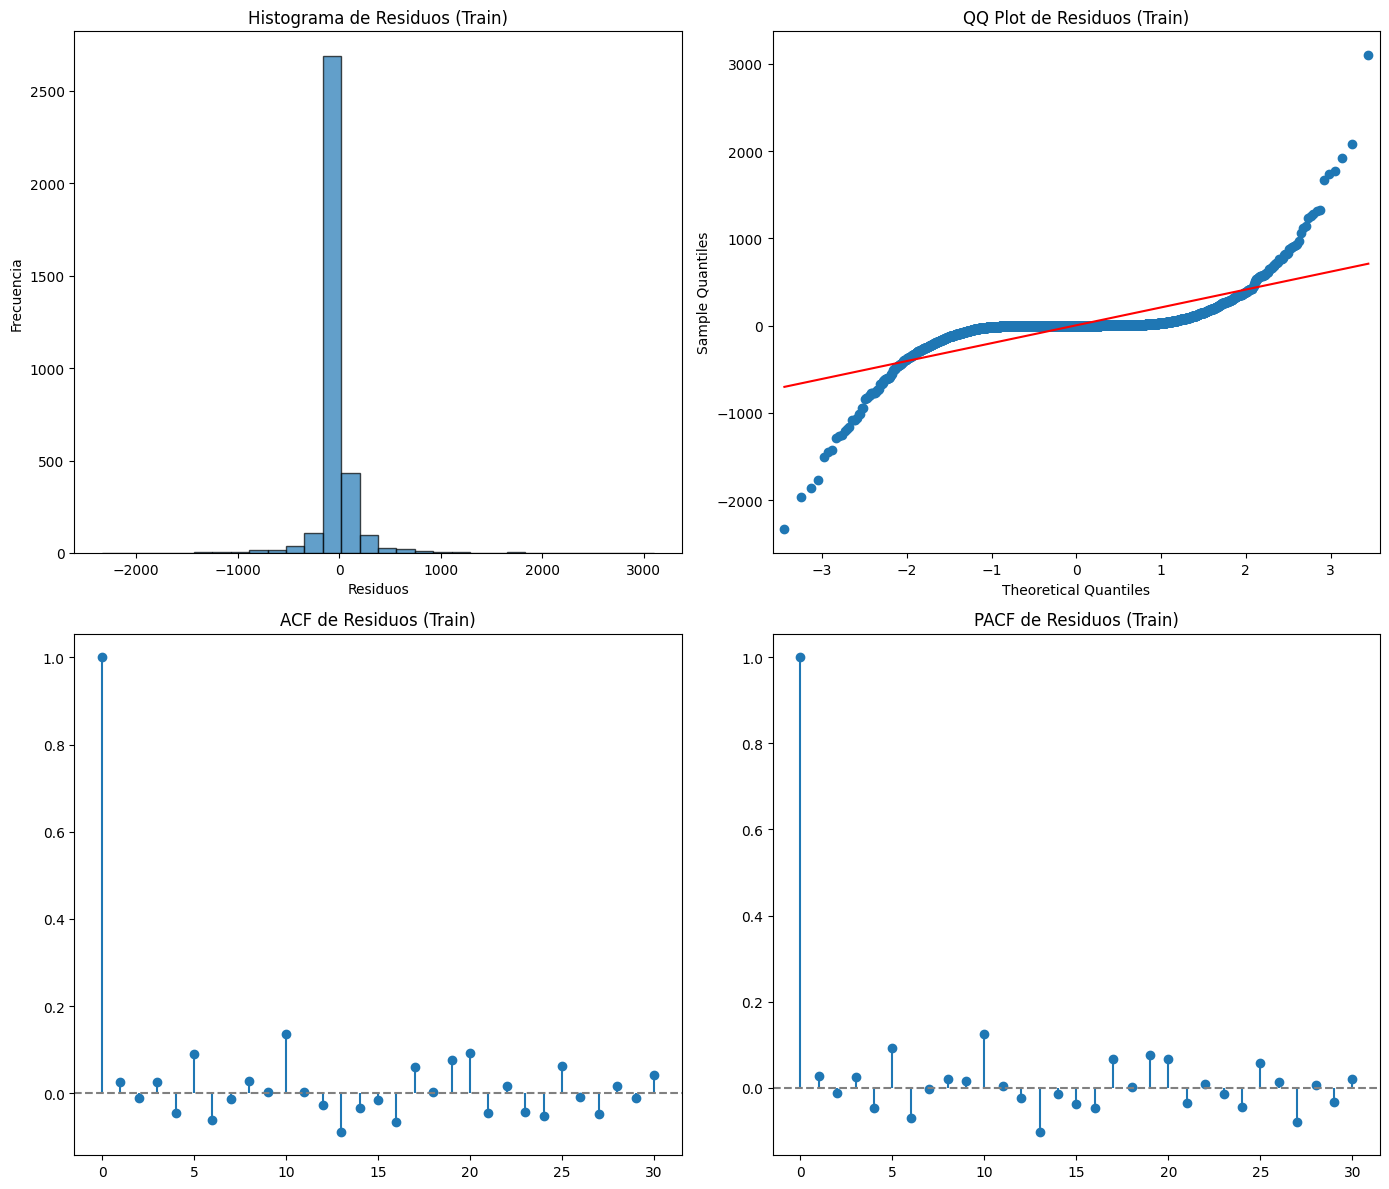

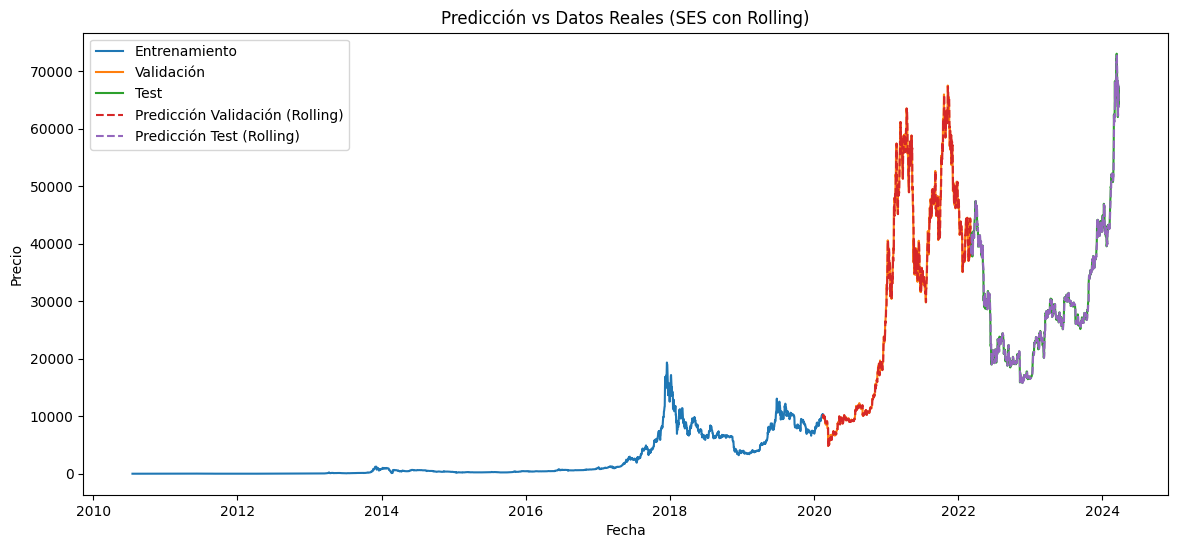

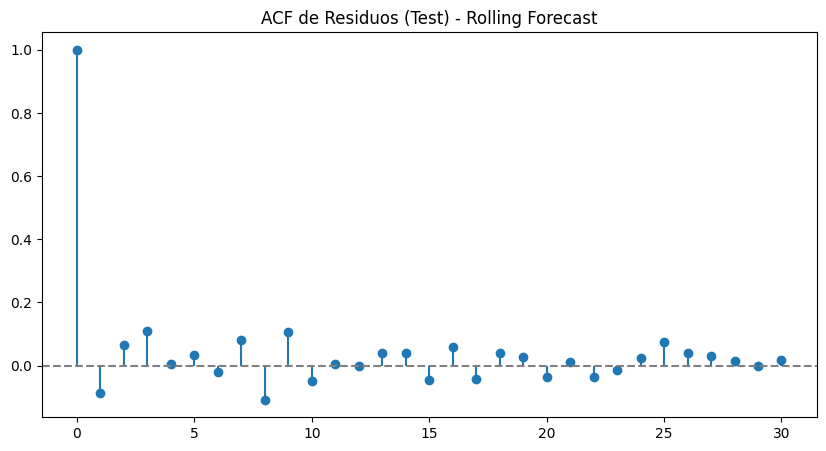

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Price"]]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import jarque_bera

# -------------------------------------------------------------------------
# 1) División del dataset en Train (70%), Validación (15%) y Test (15%)
# -------------------------------------------------------------------------
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15  # = 1 - train_ratio - val_ratio

total_data = len(df)
train_size = int(total_data * train_ratio)
val_size = int(total_data * val_ratio)
# test_size = total_data - train_size - val_size  # (se infiere)

train = df.iloc[:train_size]
validation = df.iloc[train_size : train_size + val_size]
test = df.iloc[train_size + val_size :]

print(f"Tamaño de train: {len(train)}")
print(f"Tamaño de validación: {len(validation)}")
print(f"Tamaño de test: {len(test)}")

# -------------------------------------------------------------------------
# 2) Ajustar el modelo SES en el conjunto de entrenamiento para obtener 'fitted'
#    (Solo para ver cómo ajusta en TRAIN; luego haremos rolling para VALID y TEST)
# -------------------------------------------------------------------------
model_train = SimpleExpSmoothing(train["Price"]).fit()
train["fitted"] = model_train.fittedvalues  # valores ajustados en train

# -------------------------------------------------------------------------
# 3) Función para realizar predicción "rolling" (walk-forward)
# -------------------------------------------------------------------------
def rolling_ses_forecast(train_series, forecast_series):
    """
    Toma un conjunto 'train_series' (Series) y un conjunto 'forecast_series' (Series).
    Realiza predicciones de 1 paso adelante de forma iterativa, reentrenando el modelo
    cada vez con todos los datos disponibles hasta ese punto.
    Retorna una Serie con las predicciones (mismo índice que 'forecast_series').
    """
    # Copiamos la serie de entrenamiento para ir agregando los datos reales conforme avanzamos
    history = train_series.copy()
    predictions = []
    
    for t in range(len(forecast_series)):
        # Ajustamos SES con los datos 'history'
        model_rolling = SimpleExpSmoothing(history).fit()
        # Pronóstico 1 paso adelante
        yhat = model_rolling.forecast(1)[0]
        predictions.append(yhat)
        # Agregamos el valor real recién observado a 'history'
        history.loc[forecast_series.index[t]] = forecast_series.iloc[t]
        
    return pd.Series(predictions, index=forecast_series.index)

# -------------------------------------------------------------------------
# 4) Generar predicciones rolling para Validación y Test
# -------------------------------------------------------------------------
# Rolling en Validación (comenzando desde 'train')
validation_pred = rolling_ses_forecast(train["Price"], validation["Price"])

# Rolling en Test (comenzando desde 'train + validation')
train_val_series = pd.concat([train["Price"], validation["Price"]])
test_pred = rolling_ses_forecast(train_val_series, test["Price"])

# -------------------------------------------------------------------------
# 5) Cálculo de métricas de evaluación
# -------------------------------------------------------------------------
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs(residuals / y_true)) * 100
    r2 = 1 - (np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2))
    return mape, mae, rmse, mse, r2, residuals

# Métricas en TRAIN (usando fittedvalues)
train_mape, train_mae, train_rmse, train_mse, train_r2, residuals_train = calculate_metrics(
    train["Price"], train["fitted"]
)

# Métricas en VALIDACIÓN
val_mape, val_mae, val_rmse, val_mse, val_r2, residuals_val = calculate_metrics(
    validation["Price"], validation_pred
)

# Métricas en TEST
test_mape, test_mae, test_rmse, test_mse, test_r2, residuals_test = calculate_metrics(
    test["Price"], test_pred
)

# -------------------------------------------------------------------------
# 6) Pruebas de hipótesis sobre los residuos de ENTRENAMIENTO
#    (si deseas también puedes hacer sobre los de VALID o TEST)
# -------------------------------------------------------------------------
ljung_box_p = acorr_ljungbox(residuals_train, lags=[10], return_df=True).iloc[0, 1]
jb_p = jarque_bera(residuals_train)[1]

# -------------------------------------------------------------------------
# 7) Tabla resumen de métricas (Train) y pruebas de hipótesis
# -------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "MAPE": [train_mape],
    "MAE": [train_mae],
    "RMSE": [train_rmse],
    "MSE": [train_mse],
    "R2": [train_r2],
    "Ljung-Box p-value": [ljung_box_p],
    "Jarque-Bera p-value": [jb_p]
})

print("\nMétricas del modelo (Entrenamiento) + Pruebas de hipótesis:")
print(metrics_df)

# -------------------------------------------------------------------------
# 8) Gráficos de los residuos (Train)
# -------------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Histograma de residuos (Train)
axs[0, 0].hist(residuals_train, bins=30, edgecolor='black', alpha=0.7)
axs[0, 0].set_title("Histograma de Residuos (Train)")
axs[0, 0].set_xlabel("Residuos")
axs[0, 0].set_ylabel("Frecuencia")

# QQ Plot (Train)
sm.qqplot(residuals_train, line='s', ax=axs[0, 1])
axs[0, 1].set_title("QQ Plot de Residuos (Train)")

# ACF (Train)
lags = 30
acf_vals = acf(residuals_train, nlags=lags)
axs[1, 0].stem(range(lags+1), acf_vals, basefmt=" ")
axs[1, 0].set_title("ACF de Residuos (Train)")
axs[1, 0].axhline(y=0, linestyle="--", color="gray")

# PACF (Train)
pacf_vals = pacf(residuals_train, nlags=lags)
axs[1, 1].stem(range(lags+1), pacf_vals, basefmt=" ")
axs[1, 1].set_title("PACF de Residuos (Train)")
axs[1, 1].axhline(y=0, linestyle="--", color="gray")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 9) Gráfico de Predicción vs Datos Reales
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["Price"], label="Entrenamiento")
plt.plot(validation.index, validation["Price"], label="Validación")
plt.plot(test.index, test["Price"], label="Test")

# Predicciones
plt.plot(validation.index, validation_pred, '--', label="Predicción Validación (Rolling)")
plt.plot(test.index, test_pred, '--', label="Predicción Test (Rolling)")

plt.legend()
plt.title("Predicción vs Datos Reales (SES con Rolling)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

# -------------------------------------------------------------------------
# 10) ACF de los residuos del conjunto de TEST
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
acf_vals_test = acf(residuals_test, nlags=lags)
plt.stem(range(lags+1), acf_vals_test, basefmt=" ")
plt.axhline(y=0, linestyle="--", color="gray")
plt.title("ACF de Residuos (Test) - Rolling Forecast")
plt.show()

Retorno Acumulado

Tamaño de train: 3499
Tamaño de validación: 749
Tamaño de test: 751

Métricas del modelo (Entrenamiento) + Pruebas de hipótesis:
       MAPE       MAE      RMSE       MSE        R2  Ljung-Box p-value  \
0  0.429657  0.033891  0.088629  0.007855  0.999762       9.855138e-37   

   Jarque-Bera p-value  
0                  0.0  


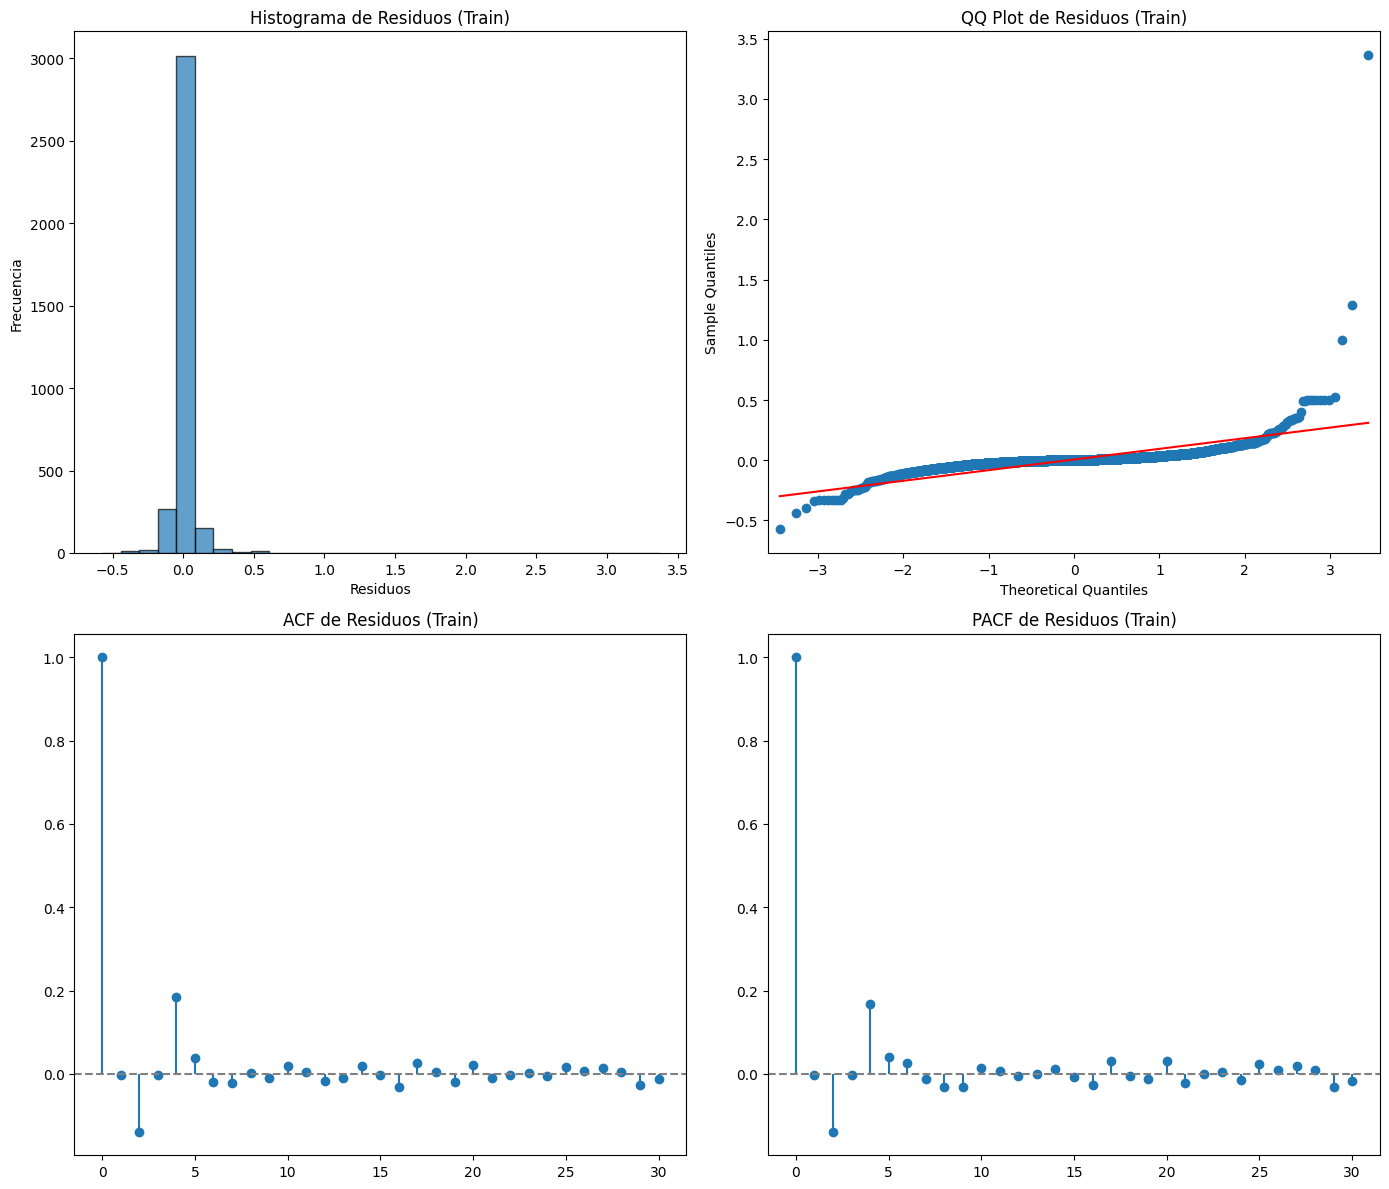

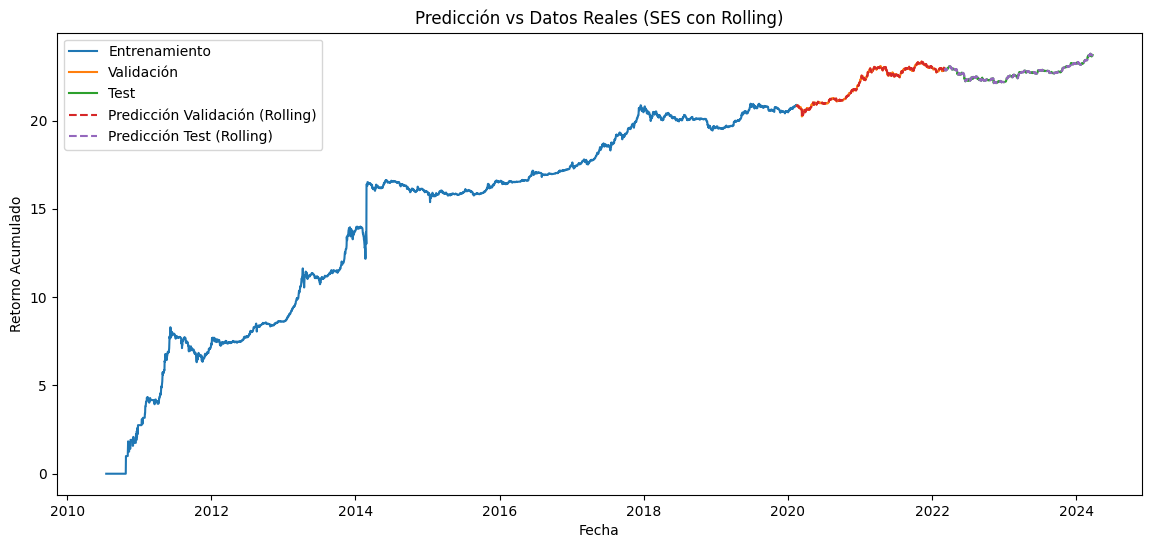

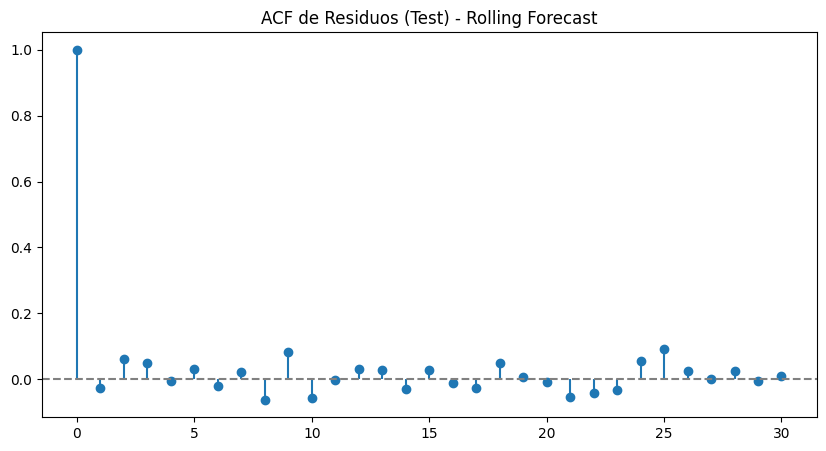

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Cumulative_Return"]]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import jarque_bera

# -------------------------------------------------------------------------
# 1) División del dataset en Train (70%), Validación (15%) y Test (15%)
# -------------------------------------------------------------------------
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15  # = 1 - train_ratio - val_ratio

total_data = len(df)
train_size = int(total_data * train_ratio)
val_size = int(total_data * val_ratio)
# test_size = total_data - train_size - val_size  # (se infiere)

train = df.iloc[:train_size]
validation = df.iloc[train_size : train_size + val_size]
test = df.iloc[train_size + val_size :]

print(f"Tamaño de train: {len(train)}")
print(f"Tamaño de validación: {len(validation)}")
print(f"Tamaño de test: {len(test)}")

# -------------------------------------------------------------------------
# 2) Ajustar el modelo SES en el conjunto de entrenamiento para obtener 'fitted'
#    (Solo para ver cómo ajusta en TRAIN; luego haremos rolling para VALID y TEST)
# -------------------------------------------------------------------------
model_train = SimpleExpSmoothing(train["Cumulative_Return"]).fit()
train["fitted"] = model_train.fittedvalues  # valores ajustados en train

# -------------------------------------------------------------------------
# 3) Función para realizar predicción "rolling" (walk-forward)
# -------------------------------------------------------------------------
def rolling_ses_forecast(train_series, forecast_series):
    """
    Toma un conjunto 'train_series' (Series) y un conjunto 'forecast_series' (Series).
    Realiza predicciones de 1 paso adelante de forma iterativa, reentrenando el modelo
    cada vez con todos los datos disponibles hasta ese punto.
    Retorna una Serie con las predicciones (mismo índice que 'forecast_series').
    """
    # Copiamos la serie de entrenamiento para ir agregando los datos reales conforme avanzamos
    history = train_series.copy()
    predictions = []
    
    for t in range(len(forecast_series)):
        # Ajustamos SES con los datos 'history'
        model_rolling = SimpleExpSmoothing(history).fit()
        # Pronóstico 1 paso adelante
        yhat = model_rolling.forecast(1)[0]
        predictions.append(yhat)
        # Agregamos el valor real recién observado a 'history'
        history.loc[forecast_series.index[t]] = forecast_series.iloc[t]
        
    return pd.Series(predictions, index=forecast_series.index)

# -------------------------------------------------------------------------
# 4) Generar predicciones rolling para Validación y Test
# -------------------------------------------------------------------------
# Rolling en Validación (comenzando desde 'train')
validation_pred = rolling_ses_forecast(train["Cumulative_Return"], validation["Cumulative_Return"])

# Rolling en Test (comenzando desde 'train + validation')
train_val_series = pd.concat([train["Cumulative_Return"], validation["Cumulative_Return"]])
test_pred = rolling_ses_forecast(train_val_series, test["Cumulative_Return"])

# -------------------------------------------------------------------------
# 5) Cálculo de métricas de evaluación
# -------------------------------------------------------------------------
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs(residuals / y_true)) * 100
    r2 = 1 - (np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2))
    return mape, mae, rmse, mse, r2, residuals

# Métricas en TRAIN (usando fittedvalues)
train_mape, train_mae, train_rmse, train_mse, train_r2, residuals_train = calculate_metrics(
    train["Cumulative_Return"], train["fitted"]
)

# Métricas en VALIDACIÓN
val_mape, val_mae, val_rmse, val_mse, val_r2, residuals_val = calculate_metrics(
    validation["Cumulative_Return"], validation_pred
)

# Métricas en TEST
test_mape, test_mae, test_rmse, test_mse, test_r2, residuals_test = calculate_metrics(
    test["Cumulative_Return"], test_pred
)

# -------------------------------------------------------------------------
# 6) Pruebas de hipótesis sobre los residuos de ENTRENAMIENTO
#    (si deseas también puedes hacer sobre los de VALID o TEST)
# -------------------------------------------------------------------------
ljung_box_p = acorr_ljungbox(residuals_train, lags=[10], return_df=True).iloc[0, 1]
jb_p = jarque_bera(residuals_train)[1]

# -------------------------------------------------------------------------
# 7) Tabla resumen de métricas (Train) y pruebas de hipótesis
# -------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "MAPE": [train_mape],
    "MAE": [train_mae],
    "RMSE": [train_rmse],
    "MSE": [train_mse],
    "R2": [train_r2],
    "Ljung-Box p-value": [ljung_box_p],
    "Jarque-Bera p-value": [jb_p]
})

print("\nMétricas del modelo (Entrenamiento) + Pruebas de hipótesis:")
print(metrics_df)

# -------------------------------------------------------------------------
# 8) Gráficos de los residuos (Train)
# -------------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Histograma de residuos (Train)
axs[0, 0].hist(residuals_train, bins=30, edgecolor='black', alpha=0.7)
axs[0, 0].set_title("Histograma de Residuos (Train)")
axs[0, 0].set_xlabel("Residuos")
axs[0, 0].set_ylabel("Frecuencia")

# QQ Plot (Train)
sm.qqplot(residuals_train, line='s', ax=axs[0, 1])
axs[0, 1].set_title("QQ Plot de Residuos (Train)")

# ACF (Train)
lags = 30
acf_vals = acf(residuals_train, nlags=lags)
axs[1, 0].stem(range(lags+1), acf_vals, basefmt=" ")
axs[1, 0].set_title("ACF de Residuos (Train)")
axs[1, 0].axhline(y=0, linestyle="--", color="gray")

# PACF (Train)
pacf_vals = pacf(residuals_train, nlags=lags)
axs[1, 1].stem(range(lags+1), pacf_vals, basefmt=" ")
axs[1, 1].set_title("PACF de Residuos (Train)")
axs[1, 1].axhline(y=0, linestyle="--", color="gray")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 9) Gráfico de Predicción vs Datos Reales
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["Cumulative_Return"], label="Entrenamiento")
plt.plot(validation.index, validation["Cumulative_Return"], label="Validación")
plt.plot(test.index, test["Cumulative_Return"], label="Test")

# Predicciones
plt.plot(validation.index, validation_pred, '--', label="Predicción Validación (Rolling)")
plt.plot(test.index, test_pred, '--', label="Predicción Test (Rolling)")

plt.legend()
plt.title("Predicción vs Datos Reales (SES con Rolling)")
plt.xlabel("Fecha")
plt.ylabel("Retorno Acumulado")
plt.show()

# -------------------------------------------------------------------------
# 10) ACF de los residuos del conjunto de TEST
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
acf_vals_test = acf(residuals_test, nlags=lags)
plt.stem(range(lags+1), acf_vals_test, basefmt=" ")
plt.axhline(y=0, linestyle="--", color="gray")
plt.title("ACF de Residuos (Test) - Rolling Forecast")
plt.show()

Volatilidad 07 dias.

Tamaño de train: 3499
Tamaño de validación: 749
Tamaño de test: 751

Métricas del modelo (Entrenamiento) + Pruebas de hipótesis:
   MAPE       MAE      RMSE       MSE       R2  Ljung-Box p-value  \
0   inf  0.006842  0.030078  0.000905  0.84351      2.135441e-143   

   Jarque-Bera p-value  
0                  0.0  


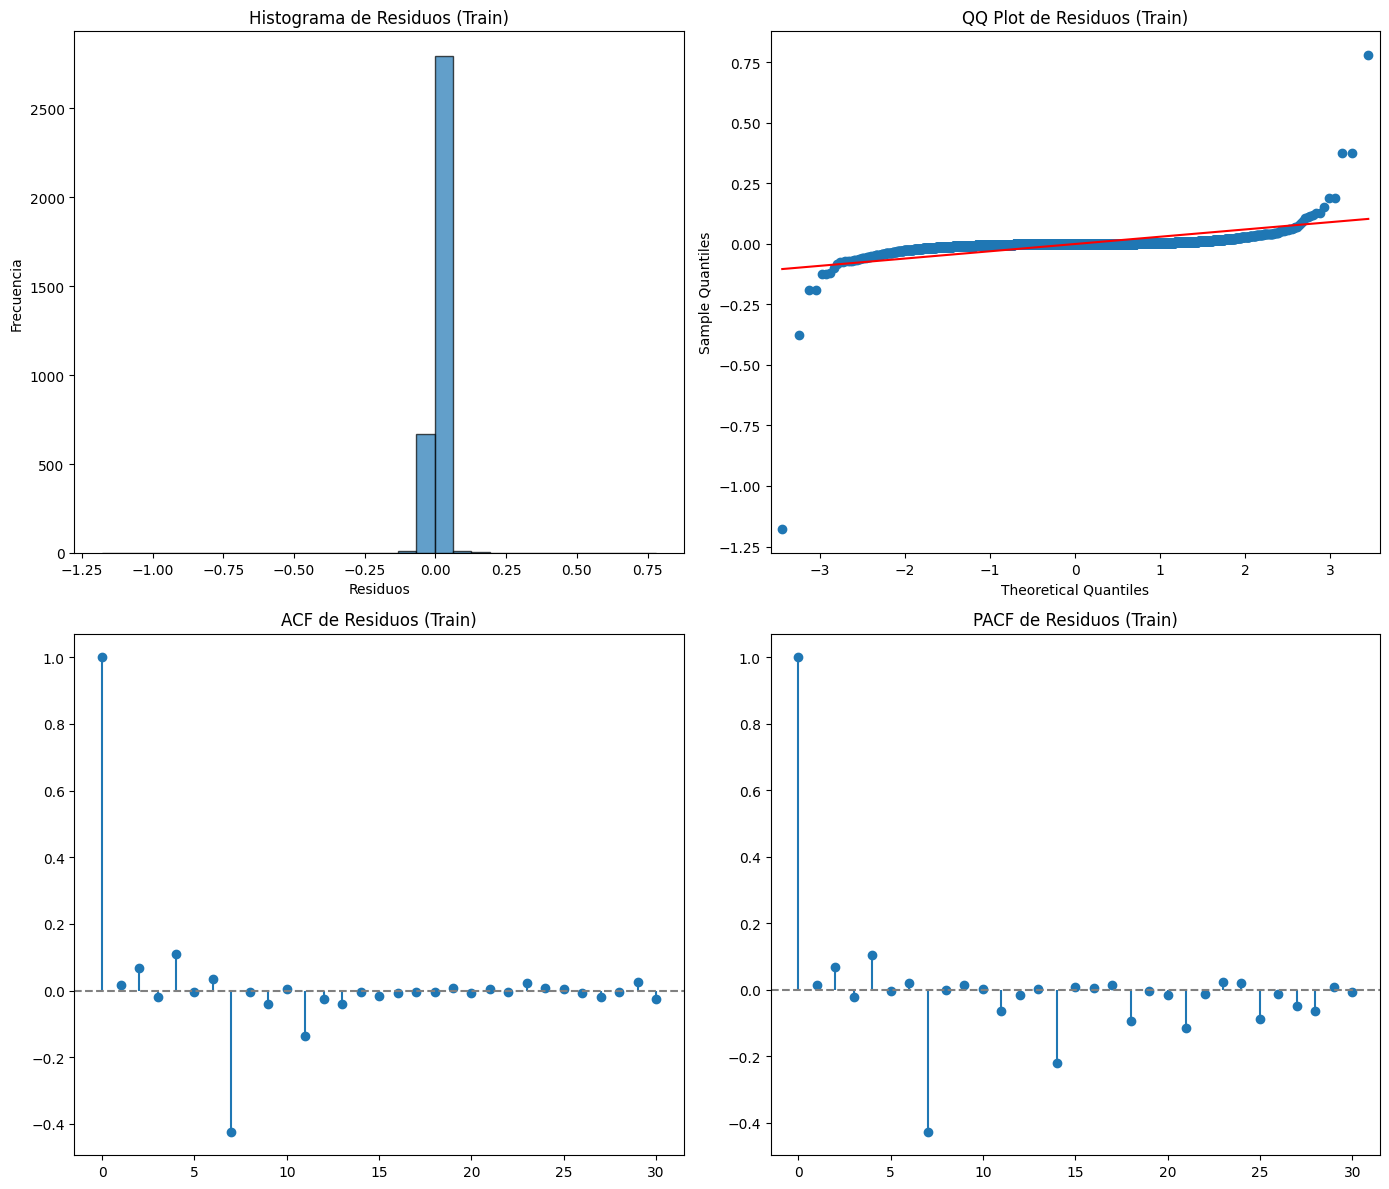

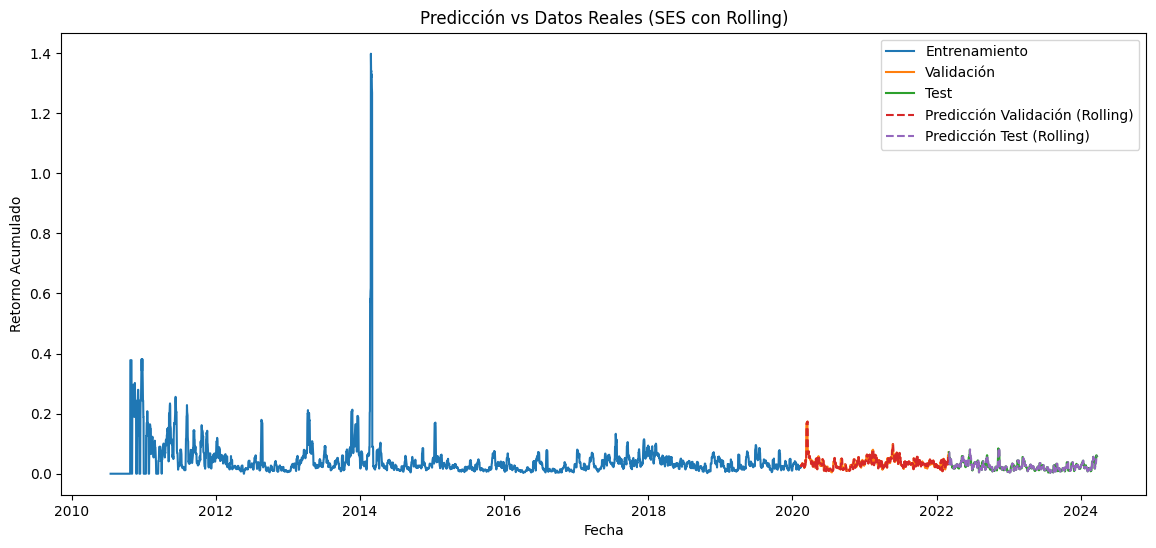

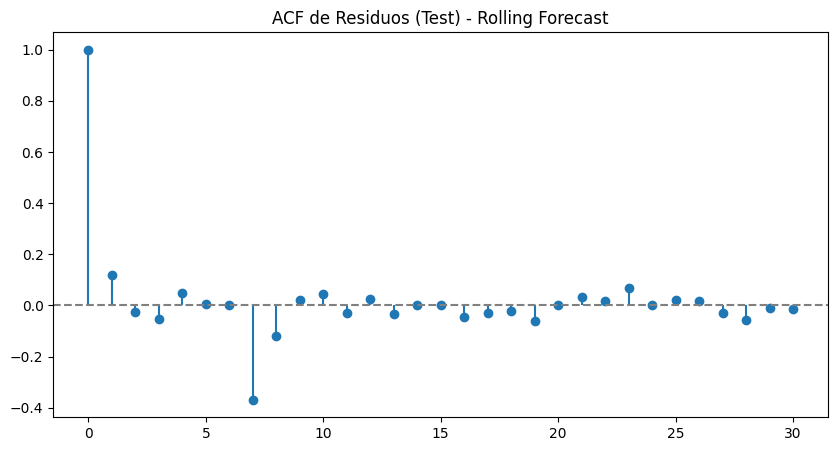

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Volatility_7d"]]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import jarque_bera

# -------------------------------------------------------------------------
# 1) División del dataset en Train (70%), Validación (15%) y Test (15%)
# -------------------------------------------------------------------------
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15  # = 1 - train_ratio - val_ratio

total_data = len(df)
train_size = int(total_data * train_ratio)
val_size = int(total_data * val_ratio)
# test_size = total_data - train_size - val_size  # (se infiere)

train = df.iloc[:train_size]
validation = df.iloc[train_size : train_size + val_size]
test = df.iloc[train_size + val_size :]

print(f"Tamaño de train: {len(train)}")
print(f"Tamaño de validación: {len(validation)}")
print(f"Tamaño de test: {len(test)}")

# -------------------------------------------------------------------------
# 2) Ajustar el modelo SES en el conjunto de entrenamiento para obtener 'fitted'
#    (Solo para ver cómo ajusta en TRAIN; luego haremos rolling para VALID y TEST)
# -------------------------------------------------------------------------
model_train = SimpleExpSmoothing(train["Volatility_7d"]).fit()
train["fitted"] = model_train.fittedvalues  # valores ajustados en train

# -------------------------------------------------------------------------
# 3) Función para realizar predicción "rolling" (walk-forward)
# -------------------------------------------------------------------------
def rolling_ses_forecast(train_series, forecast_series):
    """
    Toma un conjunto 'train_series' (Series) y un conjunto 'forecast_series' (Series).
    Realiza predicciones de 1 paso adelante de forma iterativa, reentrenando el modelo
    cada vez con todos los datos disponibles hasta ese punto.
    Retorna una Serie con las predicciones (mismo índice que 'forecast_series').
    """
    # Copiamos la serie de entrenamiento para ir agregando los datos reales conforme avanzamos
    history = train_series.copy()
    predictions = []
    
    for t in range(len(forecast_series)):
        # Ajustamos SES con los datos 'history'
        model_rolling = SimpleExpSmoothing(history).fit()
        # Pronóstico 1 paso adelante
        yhat = model_rolling.forecast(1)[0]
        predictions.append(yhat)
        # Agregamos el valor real recién observado a 'history'
        history.loc[forecast_series.index[t]] = forecast_series.iloc[t]
        
    return pd.Series(predictions, index=forecast_series.index)

# -------------------------------------------------------------------------
# 4) Generar predicciones rolling para Validación y Test
# -------------------------------------------------------------------------
# Rolling en Validación (comenzando desde 'train')
validation_pred = rolling_ses_forecast(train["Volatility_7d"], validation["Volatility_7d"])

# Rolling en Test (comenzando desde 'train + validation')
train_val_series = pd.concat([train["Volatility_7d"], validation["Volatility_7d"]])
test_pred = rolling_ses_forecast(train_val_series, test["Volatility_7d"])

# -------------------------------------------------------------------------
# 5) Cálculo de métricas de evaluación
# -------------------------------------------------------------------------
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs(residuals / y_true)) * 100
    r2 = 1 - (np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2))
    return mape, mae, rmse, mse, r2, residuals

# Métricas en TRAIN (usando fittedvalues)
train_mape, train_mae, train_rmse, train_mse, train_r2, residuals_train = calculate_metrics(
    train["Volatility_7d"], train["fitted"]
)

# Métricas en VALIDACIÓN
val_mape, val_mae, val_rmse, val_mse, val_r2, residuals_val = calculate_metrics(
    validation["Volatility_7d"], validation_pred
)

# Métricas en TEST
test_mape, test_mae, test_rmse, test_mse, test_r2, residuals_test = calculate_metrics(
    test["Volatility_7d"], test_pred
)

# -------------------------------------------------------------------------
# 6) Pruebas de hipótesis sobre los residuos de ENTRENAMIENTO
#    (si deseas también puedes hacer sobre los de VALID o TEST)
# -------------------------------------------------------------------------
ljung_box_p = acorr_ljungbox(residuals_train, lags=[10], return_df=True).iloc[0, 1]
jb_p = jarque_bera(residuals_train)[1]

# -------------------------------------------------------------------------
# 7) Tabla resumen de métricas (Train) y pruebas de hipótesis
# -------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "MAPE": [train_mape],
    "MAE": [train_mae],
    "RMSE": [train_rmse],
    "MSE": [train_mse],
    "R2": [train_r2],
    "Ljung-Box p-value": [ljung_box_p],
    "Jarque-Bera p-value": [jb_p]
})

print("\nMétricas del modelo (Entrenamiento) + Pruebas de hipótesis:")
print(metrics_df)

# -------------------------------------------------------------------------
# 8) Gráficos de los residuos (Train)
# -------------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Histograma de residuos (Train)
axs[0, 0].hist(residuals_train, bins=30, edgecolor='black', alpha=0.7)
axs[0, 0].set_title("Histograma de Residuos (Train)")
axs[0, 0].set_xlabel("Residuos")
axs[0, 0].set_ylabel("Frecuencia")

# QQ Plot (Train)
sm.qqplot(residuals_train, line='s', ax=axs[0, 1])
axs[0, 1].set_title("QQ Plot de Residuos (Train)")

# ACF (Train)
lags = 30
acf_vals = acf(residuals_train, nlags=lags)
axs[1, 0].stem(range(lags+1), acf_vals, basefmt=" ")
axs[1, 0].set_title("ACF de Residuos (Train)")
axs[1, 0].axhline(y=0, linestyle="--", color="gray")

# PACF (Train)
pacf_vals = pacf(residuals_train, nlags=lags)
axs[1, 1].stem(range(lags+1), pacf_vals, basefmt=" ")
axs[1, 1].set_title("PACF de Residuos (Train)")
axs[1, 1].axhline(y=0, linestyle="--", color="gray")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 9) Gráfico de Predicción vs Datos Reales
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["Volatility_7d"], label="Entrenamiento")
plt.plot(validation.index, validation["Volatility_7d"], label="Validación")
plt.plot(test.index, test["Volatility_7d"], label="Test")

# Predicciones
plt.plot(validation.index, validation_pred, '--', label="Predicción Validación (Rolling)")
plt.plot(test.index, test_pred, '--', label="Predicción Test (Rolling)")

plt.legend()
plt.title("Predicción vs Datos Reales (SES con Rolling)")
plt.xlabel("Fecha")
plt.ylabel("Retorno Acumulado")
plt.show()

# -------------------------------------------------------------------------
# 10) ACF de los residuos del conjunto de TEST
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
acf_vals_test = acf(residuals_test, nlags=lags)
plt.stem(range(lags+1), acf_vals_test, basefmt=" ")
plt.axhline(y=0, linestyle="--", color="gray")
plt.title("ACF de Residuos (Test) - Rolling Forecast")
plt.show()

Volatilidad 14 días

Tamaño de train: 3499
Tamaño de validación: 749
Tamaño de test: 751

Métricas del modelo (Entrenamiento) + Pruebas de hipótesis:
   MAPE       MAE      RMSE       MSE        R2  Ljung-Box p-value  \
0   inf  0.003535  0.019762  0.000391  0.927433       1.319511e-16   

   Jarque-Bera p-value  
0                  0.0  


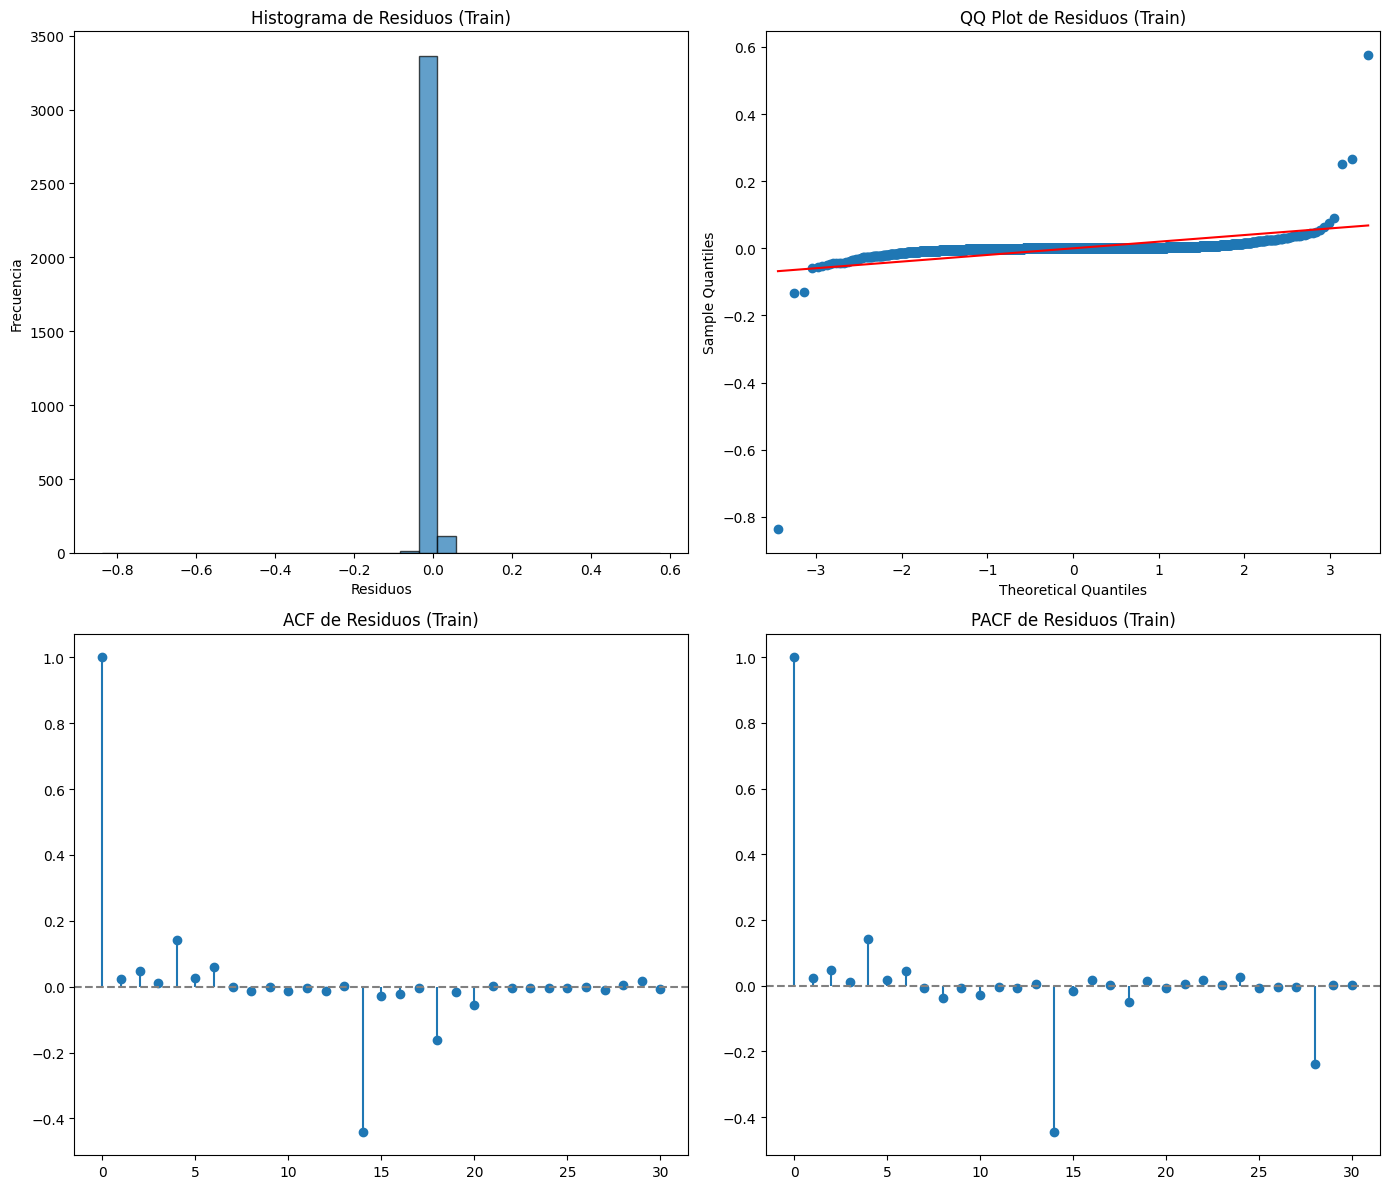

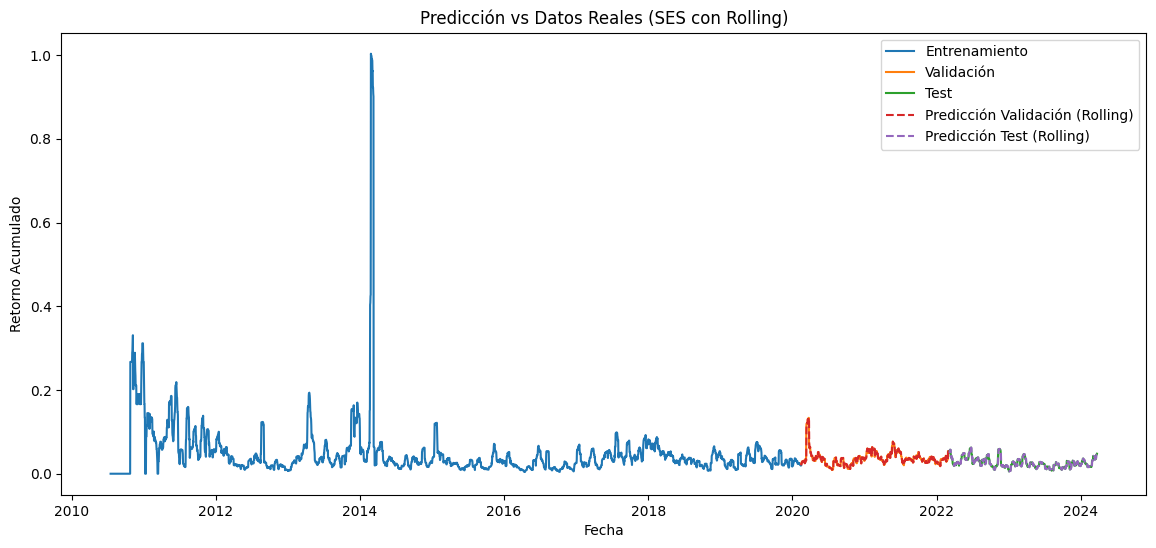

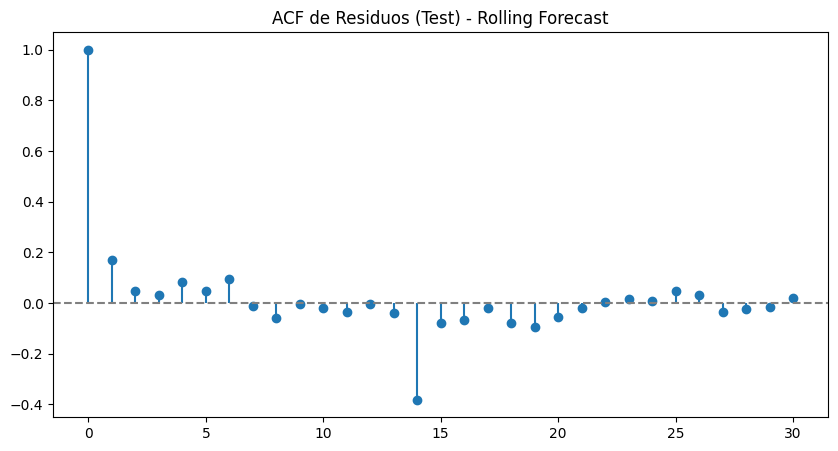

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Volatility_14d"]]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import jarque_bera

# -------------------------------------------------------------------------
# 1) División del dataset en Train (70%), Validación (15%) y Test (15%)
# -------------------------------------------------------------------------
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15  # = 1 - train_ratio - val_ratio

total_data = len(df)
train_size = int(total_data * train_ratio)
val_size = int(total_data * val_ratio)
# test_size = total_data - train_size - val_size  # (se infiere)

train = df.iloc[:train_size]
validation = df.iloc[train_size : train_size + val_size]
test = df.iloc[train_size + val_size :]

print(f"Tamaño de train: {len(train)}")
print(f"Tamaño de validación: {len(validation)}")
print(f"Tamaño de test: {len(test)}")

# -------------------------------------------------------------------------
# 2) Ajustar el modelo SES en el conjunto de entrenamiento para obtener 'fitted'
#    (Solo para ver cómo ajusta en TRAIN; luego haremos rolling para VALID y TEST)
# -------------------------------------------------------------------------
model_train = SimpleExpSmoothing(train["Volatility_14d"]).fit()
train["fitted"] = model_train.fittedvalues  # valores ajustados en train

# -------------------------------------------------------------------------
# 3) Función para realizar predicción "rolling" (walk-forward)
# -------------------------------------------------------------------------
def rolling_ses_forecast(train_series, forecast_series):
    """
    Toma un conjunto 'train_series' (Series) y un conjunto 'forecast_series' (Series).
    Realiza predicciones de 1 paso adelante de forma iterativa, reentrenando el modelo
    cada vez con todos los datos disponibles hasta ese punto.
    Retorna una Serie con las predicciones (mismo índice que 'forecast_series').
    """
    # Copiamos la serie de entrenamiento para ir agregando los datos reales conforme avanzamos
    history = train_series.copy()
    predictions = []
    
    for t in range(len(forecast_series)):
        # Ajustamos SES con los datos 'history'
        model_rolling = SimpleExpSmoothing(history).fit()
        # Pronóstico 1 paso adelante
        yhat = model_rolling.forecast(1)[0]
        predictions.append(yhat)
        # Agregamos el valor real recién observado a 'history'
        history.loc[forecast_series.index[t]] = forecast_series.iloc[t]
        
    return pd.Series(predictions, index=forecast_series.index)

# -------------------------------------------------------------------------
# 4) Generar predicciones rolling para Validación y Test
# -------------------------------------------------------------------------
# Rolling en Validación (comenzando desde 'train')
validation_pred = rolling_ses_forecast(train["Volatility_14d"], validation["Volatility_14d"])

# Rolling en Test (comenzando desde 'train + validation')
train_val_series = pd.concat([train["Volatility_14d"], validation["Volatility_14d"]])
test_pred = rolling_ses_forecast(train_val_series, test["Volatility_14d"])

# -------------------------------------------------------------------------
# 5) Cálculo de métricas de evaluación
# -------------------------------------------------------------------------
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs(residuals / y_true)) * 100
    r2 = 1 - (np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2))
    return mape, mae, rmse, mse, r2, residuals

# Métricas en TRAIN (usando fittedvalues)
train_mape, train_mae, train_rmse, train_mse, train_r2, residuals_train = calculate_metrics(
    train["Volatility_14d"], train["fitted"]
)

# Métricas en VALIDACIÓN
val_mape, val_mae, val_rmse, val_mse, val_r2, residuals_val = calculate_metrics(
    validation["Volatility_14d"], validation_pred
)

# Métricas en TEST
test_mape, test_mae, test_rmse, test_mse, test_r2, residuals_test = calculate_metrics(
    test["Volatility_14d"], test_pred
)

# -------------------------------------------------------------------------
# 6) Pruebas de hipótesis sobre los residuos de ENTRENAMIENTO
#    (si deseas también puedes hacer sobre los de VALID o TEST)
# -------------------------------------------------------------------------
ljung_box_p = acorr_ljungbox(residuals_train, lags=[10], return_df=True).iloc[0, 1]
jb_p = jarque_bera(residuals_train)[1]

# -------------------------------------------------------------------------
# 7) Tabla resumen de métricas (Train) y pruebas de hipótesis
# -------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "MAPE": [train_mape],
    "MAE": [train_mae],
    "RMSE": [train_rmse],
    "MSE": [train_mse],
    "R2": [train_r2],
    "Ljung-Box p-value": [ljung_box_p],
    "Jarque-Bera p-value": [jb_p]
})

print("\nMétricas del modelo (Entrenamiento) + Pruebas de hipótesis:")
print(metrics_df)

# -------------------------------------------------------------------------
# 8) Gráficos de los residuos (Train)
# -------------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Histograma de residuos (Train)
axs[0, 0].hist(residuals_train, bins=30, edgecolor='black', alpha=0.7)
axs[0, 0].set_title("Histograma de Residuos (Train)")
axs[0, 0].set_xlabel("Residuos")
axs[0, 0].set_ylabel("Frecuencia")

# QQ Plot (Train)
sm.qqplot(residuals_train, line='s', ax=axs[0, 1])
axs[0, 1].set_title("QQ Plot de Residuos (Train)")

# ACF (Train)
lags = 30
acf_vals = acf(residuals_train, nlags=lags)
axs[1, 0].stem(range(lags+1), acf_vals, basefmt=" ")
axs[1, 0].set_title("ACF de Residuos (Train)")
axs[1, 0].axhline(y=0, linestyle="--", color="gray")

# PACF (Train)
pacf_vals = pacf(residuals_train, nlags=lags)
axs[1, 1].stem(range(lags+1), pacf_vals, basefmt=" ")
axs[1, 1].set_title("PACF de Residuos (Train)")
axs[1, 1].axhline(y=0, linestyle="--", color="gray")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 9) Gráfico de Predicción vs Datos Reales
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["Volatility_14d"], label="Entrenamiento")
plt.plot(validation.index, validation["Volatility_14d"], label="Validación")
plt.plot(test.index, test["Volatility_14d"], label="Test")

# Predicciones
plt.plot(validation.index, validation_pred, '--', label="Predicción Validación (Rolling)")
plt.plot(test.index, test_pred, '--', label="Predicción Test (Rolling)")

plt.legend()
plt.title("Predicción vs Datos Reales (SES con Rolling)")
plt.xlabel("Fecha")
plt.ylabel("Retorno Acumulado")
plt.show()

# -------------------------------------------------------------------------
# 10) ACF de los residuos del conjunto de TEST
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
acf_vals_test = acf(residuals_test, nlags=lags)
plt.stem(range(lags+1), acf_vals_test, basefmt=" ")
plt.axhline(y=0, linestyle="--", color="gray")
plt.title("ACF de Residuos (Test) - Rolling Forecast")
plt.show()

Volatilidad 21 días

Tamaño de train: 3499
Tamaño de validación: 749
Tamaño de test: 751

Métricas del modelo (Entrenamiento) + Pruebas de hipótesis:
       MAPE       MAE      RMSE       MSE        R2  Ljung-Box p-value  \
0  5.167099  0.002431  0.015761  0.000248  0.952048       5.532398e-17   

   Jarque-Bera p-value  
0                  0.0  


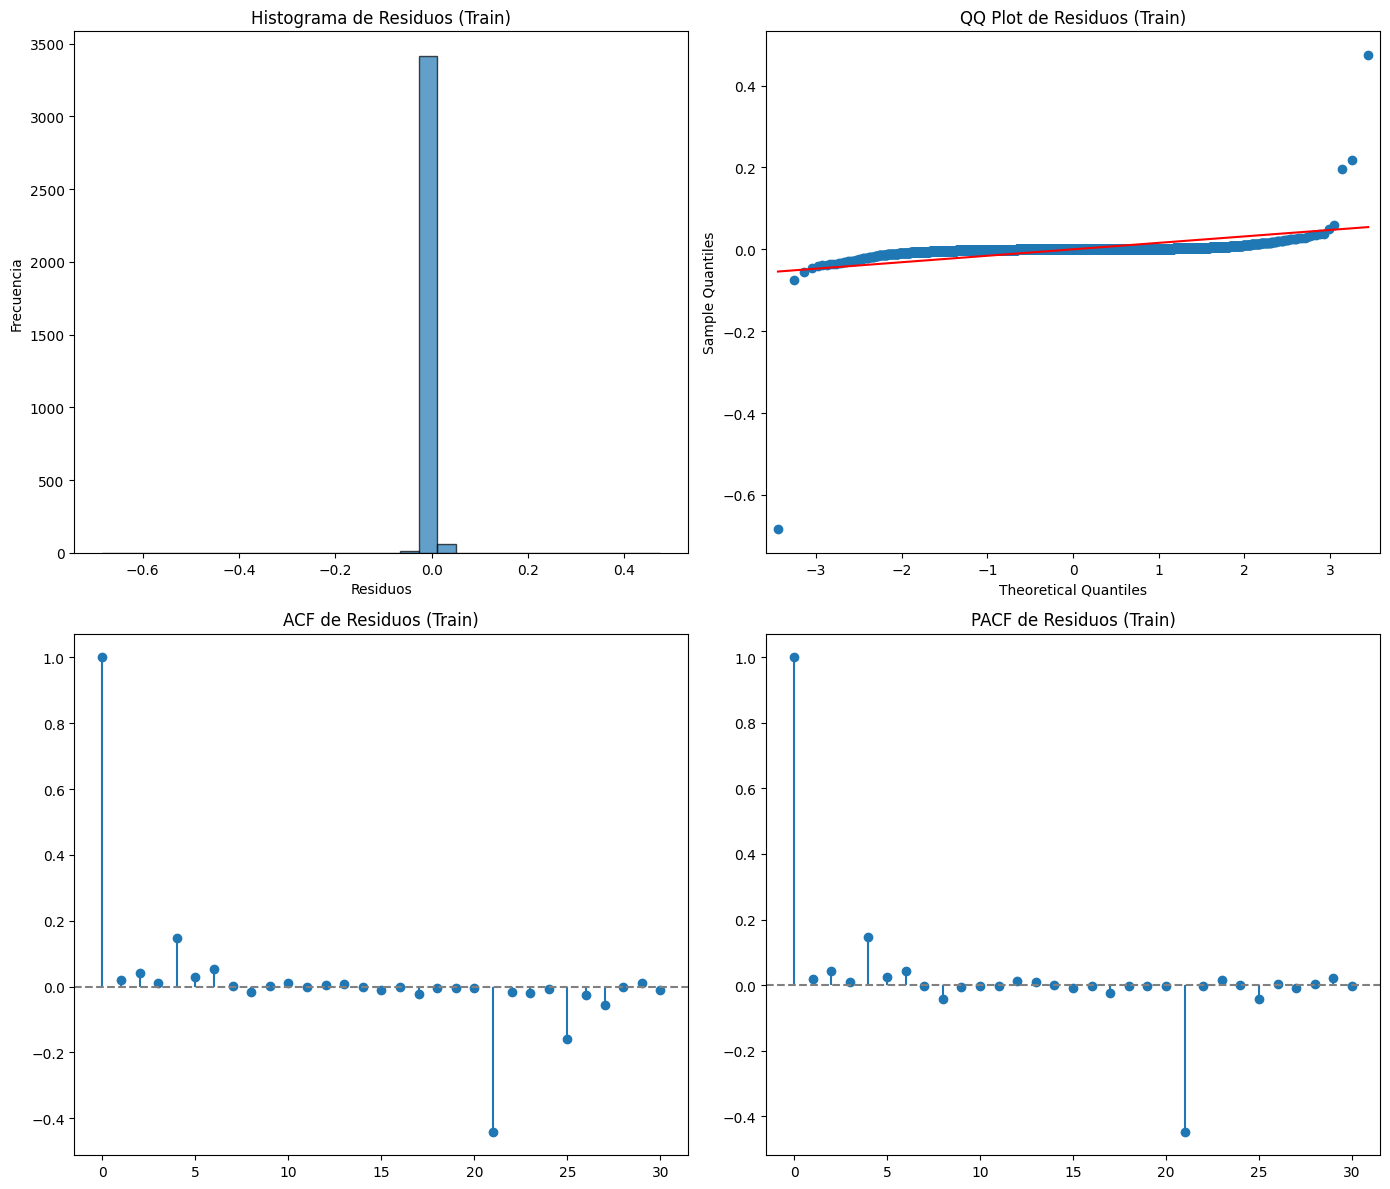

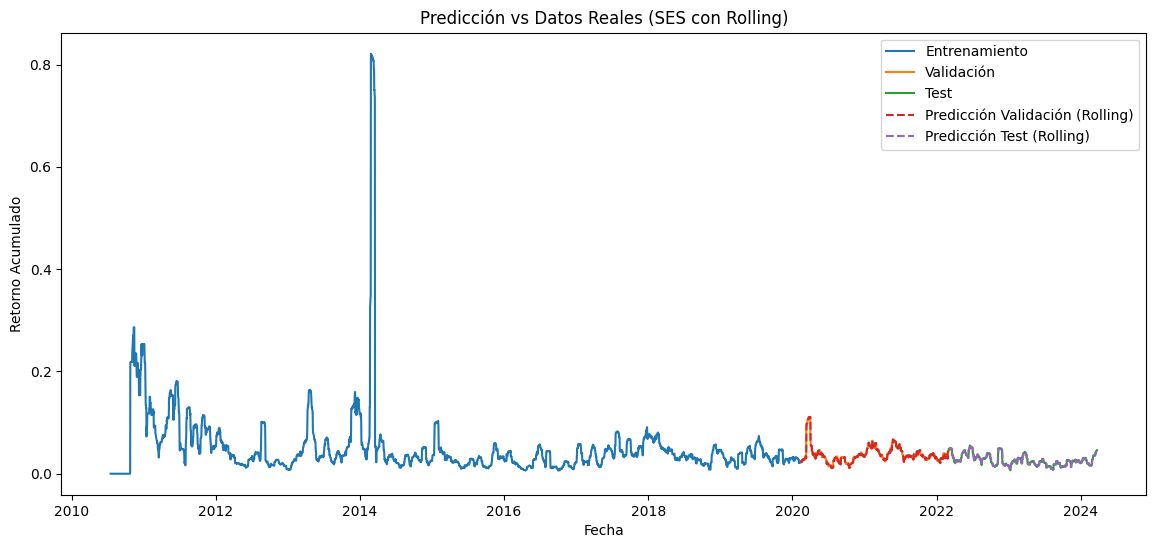

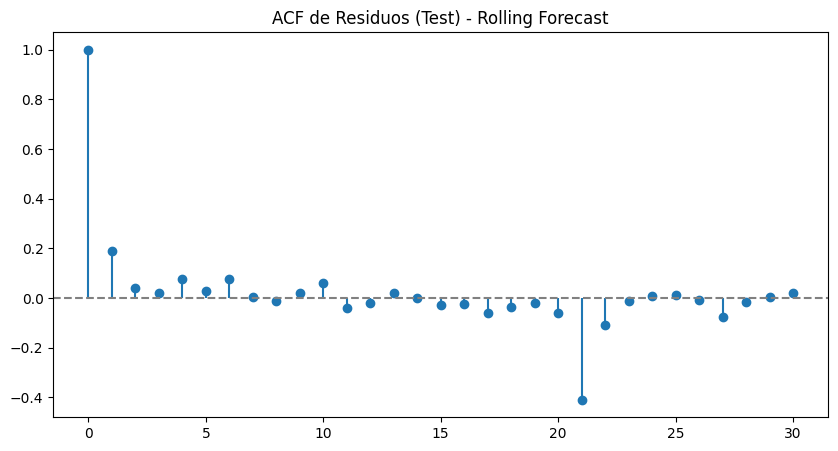

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Volatility_21d"]]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import jarque_bera

# -------------------------------------------------------------------------
# 1) División del dataset en Train (70%), Validación (15%) y Test (15%)
# -------------------------------------------------------------------------
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15  # = 1 - train_ratio - val_ratio

total_data = len(df)
train_size = int(total_data * train_ratio)
val_size = int(total_data * val_ratio)
# test_size = total_data - train_size - val_size  # (se infiere)

train = df.iloc[:train_size]
validation = df.iloc[train_size : train_size + val_size]
test = df.iloc[train_size + val_size :]

print(f"Tamaño de train: {len(train)}")
print(f"Tamaño de validación: {len(validation)}")
print(f"Tamaño de test: {len(test)}")

# -------------------------------------------------------------------------
# 2) Ajustar el modelo SES en el conjunto de entrenamiento para obtener 'fitted'
#    (Solo para ver cómo ajusta en TRAIN; luego haremos rolling para VALID y TEST)
# -------------------------------------------------------------------------
model_train = SimpleExpSmoothing(train["Volatility_21d"]).fit()
train["fitted"] = model_train.fittedvalues  # valores ajustados en train

# -------------------------------------------------------------------------
# 3) Función para realizar predicción "rolling" (walk-forward)
# -------------------------------------------------------------------------
def rolling_ses_forecast(train_series, forecast_series):
    """
    Toma un conjunto 'train_series' (Series) y un conjunto 'forecast_series' (Series).
    Realiza predicciones de 1 paso adelante de forma iterativa, reentrenando el modelo
    cada vez con todos los datos disponibles hasta ese punto.
    Retorna una Serie con las predicciones (mismo índice que 'forecast_series').
    """
    # Copiamos la serie de entrenamiento para ir agregando los datos reales conforme avanzamos
    history = train_series.copy()
    predictions = []
    
    for t in range(len(forecast_series)):
        # Ajustamos SES con los datos 'history'
        model_rolling = SimpleExpSmoothing(history).fit()
        # Pronóstico 1 paso adelante
        yhat = model_rolling.forecast(1)[0]
        predictions.append(yhat)
        # Agregamos el valor real recién observado a 'history'
        history.loc[forecast_series.index[t]] = forecast_series.iloc[t]
        
    return pd.Series(predictions, index=forecast_series.index)

# -------------------------------------------------------------------------
# 4) Generar predicciones rolling para Validación y Test
# -------------------------------------------------------------------------
# Rolling en Validación (comenzando desde 'train')
validation_pred = rolling_ses_forecast(train["Volatility_21d"], validation["Volatility_21d"])

# Rolling en Test (comenzando desde 'train + validation')
train_val_series = pd.concat([train["Volatility_21d"], validation["Volatility_21d"]])
test_pred = rolling_ses_forecast(train_val_series, test["Volatility_21d"])

# -------------------------------------------------------------------------
# 5) Cálculo de métricas de evaluación
# -------------------------------------------------------------------------
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs(residuals / y_true)) * 100
    r2 = 1 - (np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2))
    return mape, mae, rmse, mse, r2, residuals

# Métricas en TRAIN (usando fittedvalues)
train_mape, train_mae, train_rmse, train_mse, train_r2, residuals_train = calculate_metrics(
    train["Volatility_21d"], train["fitted"]
)

# Métricas en VALIDACIÓN
val_mape, val_mae, val_rmse, val_mse, val_r2, residuals_val = calculate_metrics(
    validation["Volatility_21d"], validation_pred
)

# Métricas en TEST
test_mape, test_mae, test_rmse, test_mse, test_r2, residuals_test = calculate_metrics(
    test["Volatility_21d"], test_pred
)

# -------------------------------------------------------------------------
# 6) Pruebas de hipótesis sobre los residuos de ENTRENAMIENTO
#    (si deseas también puedes hacer sobre los de VALID o TEST)
# -------------------------------------------------------------------------
ljung_box_p = acorr_ljungbox(residuals_train, lags=[10], return_df=True).iloc[0, 1]
jb_p = jarque_bera(residuals_train)[1]

# -------------------------------------------------------------------------
# 7) Tabla resumen de métricas (Train) y pruebas de hipótesis
# -------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "MAPE": [train_mape],
    "MAE": [train_mae],
    "RMSE": [train_rmse],
    "MSE": [train_mse],
    "R2": [train_r2],
    "Ljung-Box p-value": [ljung_box_p],
    "Jarque-Bera p-value": [jb_p]
})

print("\nMétricas del modelo (Entrenamiento) + Pruebas de hipótesis:")
print(metrics_df)

# -------------------------------------------------------------------------
# 8) Gráficos de los residuos (Train)
# -------------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Histograma de residuos (Train)
axs[0, 0].hist(residuals_train, bins=30, edgecolor='black', alpha=0.7)
axs[0, 0].set_title("Histograma de Residuos (Train)")
axs[0, 0].set_xlabel("Residuos")
axs[0, 0].set_ylabel("Frecuencia")

# QQ Plot (Train)
sm.qqplot(residuals_train, line='s', ax=axs[0, 1])
axs[0, 1].set_title("QQ Plot de Residuos (Train)")

# ACF (Train)
lags = 30
acf_vals = acf(residuals_train, nlags=lags)
axs[1, 0].stem(range(lags+1), acf_vals, basefmt=" ")
axs[1, 0].set_title("ACF de Residuos (Train)")
axs[1, 0].axhline(y=0, linestyle="--", color="gray")

# PACF (Train)
pacf_vals = pacf(residuals_train, nlags=lags)
axs[1, 1].stem(range(lags+1), pacf_vals, basefmt=" ")
axs[1, 1].set_title("PACF de Residuos (Train)")
axs[1, 1].axhline(y=0, linestyle="--", color="gray")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 9) Gráfico de Predicción vs Datos Reales
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["Volatility_21d"], label="Entrenamiento")
plt.plot(validation.index, validation["Volatility_21d"], label="Validación")
plt.plot(test.index, test["Volatility_21d"], label="Test")

# Predicciones
plt.plot(validation.index, validation_pred, '--', label="Predicción Validación (Rolling)")
plt.plot(test.index, test_pred, '--', label="Predicción Test (Rolling)")

plt.legend()
plt.title("Predicción vs Datos Reales (SES con Rolling)")
plt.xlabel("Fecha")
plt.ylabel("Retorno Acumulado")
plt.show()

# -------------------------------------------------------------------------
# 10) ACF de los residuos del conjunto de TEST
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
acf_vals_test = acf(residuals_test, nlags=lags)
plt.stem(range(lags+1), acf_vals_test, basefmt=" ")
plt.axhline(y=0, linestyle="--", color="gray")
plt.title("ACF de Residuos (Test) - Rolling Forecast")
plt.show()

Volatilidad 28 días

Tamaño de train: 3499
Tamaño de validación: 749
Tamaño de test: 751

Métricas del modelo (Entrenamiento) + Pruebas de hipótesis:
       MAPE       MAE      RMSE       MSE        R2  Ljung-Box p-value  \
0  4.000394  0.001907  0.013458  0.000181  0.964008       3.876798e-16   

   Jarque-Bera p-value  
0                  0.0  


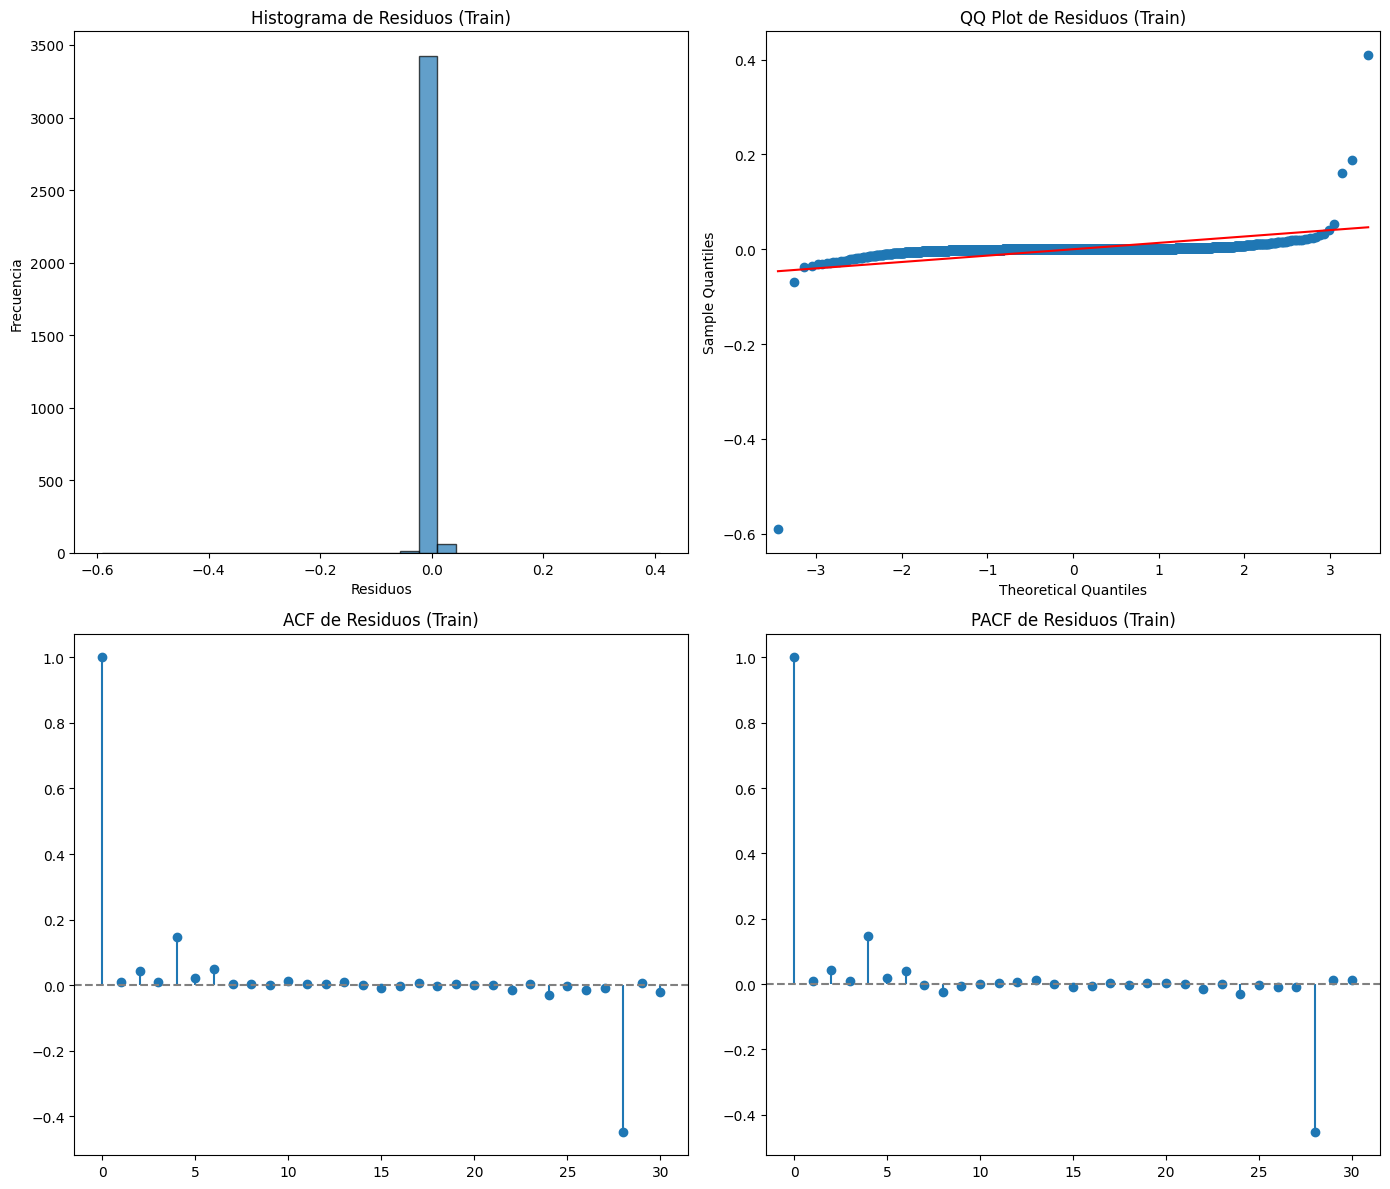

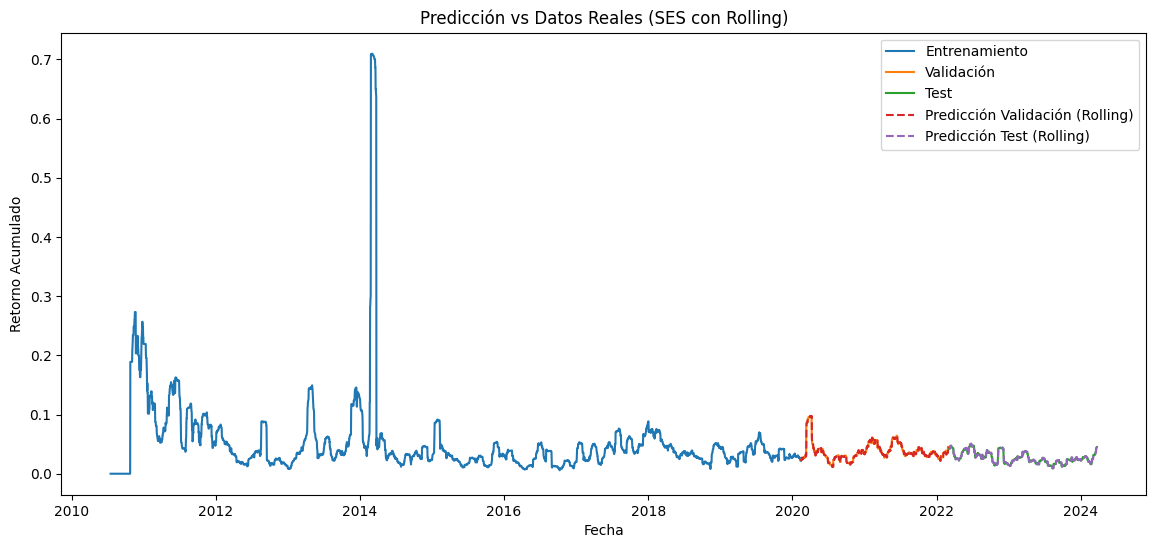

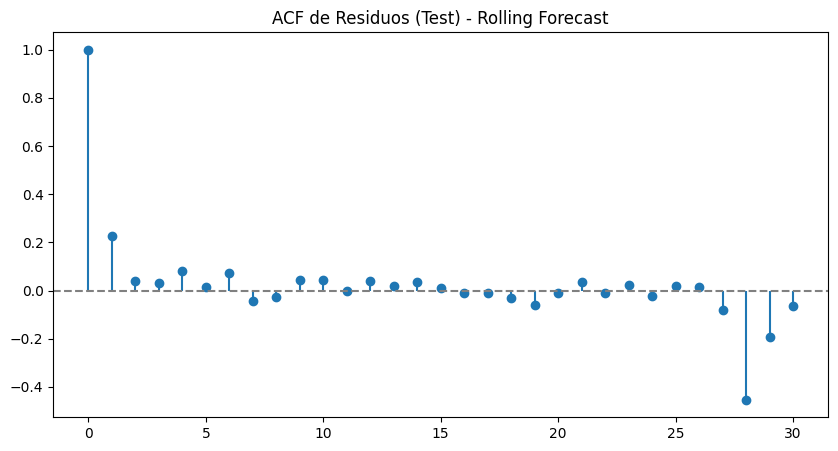

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Volatility_28d"]]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import acf, pacf
from scipy.stats import jarque_bera

# -------------------------------------------------------------------------
# 1) División del dataset en Train (70%), Validación (15%) y Test (15%)
# -------------------------------------------------------------------------
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15  # = 1 - train_ratio - val_ratio

total_data = len(df)
train_size = int(total_data * train_ratio)
val_size = int(total_data * val_ratio)
# test_size = total_data - train_size - val_size  # (se infiere)

train = df.iloc[:train_size]
validation = df.iloc[train_size : train_size + val_size]
test = df.iloc[train_size + val_size :]

print(f"Tamaño de train: {len(train)}")
print(f"Tamaño de validación: {len(validation)}")
print(f"Tamaño de test: {len(test)}")

# -------------------------------------------------------------------------
# 2) Ajustar el modelo SES en el conjunto de entrenamiento para obtener 'fitted'
#    (Solo para ver cómo ajusta en TRAIN; luego haremos rolling para VALID y TEST)
# -------------------------------------------------------------------------
model_train = SimpleExpSmoothing(train["Volatility_28d"]).fit()
train["fitted"] = model_train.fittedvalues  # valores ajustados en train

# -------------------------------------------------------------------------
# 3) Función para realizar predicción "rolling" (walk-forward)
# -------------------------------------------------------------------------
def rolling_ses_forecast(train_series, forecast_series):
    """
    Toma un conjunto 'train_series' (Series) y un conjunto 'forecast_series' (Series).
    Realiza predicciones de 1 paso adelante de forma iterativa, reentrenando el modelo
    cada vez con todos los datos disponibles hasta ese punto.
    Retorna una Serie con las predicciones (mismo índice que 'forecast_series').
    """
    # Copiamos la serie de entrenamiento para ir agregando los datos reales conforme avanzamos
    history = train_series.copy()
    predictions = []
    
    for t in range(len(forecast_series)):
        # Ajustamos SES con los datos 'history'
        model_rolling = SimpleExpSmoothing(history).fit()
        # Pronóstico 1 paso adelante
        yhat = model_rolling.forecast(1)[0]
        predictions.append(yhat)
        # Agregamos el valor real recién observado a 'history'
        history.loc[forecast_series.index[t]] = forecast_series.iloc[t]
        
    return pd.Series(predictions, index=forecast_series.index)

# -------------------------------------------------------------------------
# 4) Generar predicciones rolling para Validación y Test
# -------------------------------------------------------------------------
# Rolling en Validación (comenzando desde 'train')
validation_pred = rolling_ses_forecast(train["Volatility_28d"], validation["Volatility_28d"])

# Rolling en Test (comenzando desde 'train + validation')
train_val_series = pd.concat([train["Volatility_28d"], validation["Volatility_28d"]])
test_pred = rolling_ses_forecast(train_val_series, test["Volatility_28d"])

# -------------------------------------------------------------------------
# 5) Cálculo de métricas de evaluación
# -------------------------------------------------------------------------
def calculate_metrics(y_true, y_pred):
    residuals = y_true - y_pred
    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals**2)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs(residuals / y_true)) * 100
    r2 = 1 - (np.sum(residuals**2) / np.sum((y_true - np.mean(y_true))**2))
    return mape, mae, rmse, mse, r2, residuals

# Métricas en TRAIN (usando fittedvalues)
train_mape, train_mae, train_rmse, train_mse, train_r2, residuals_train = calculate_metrics(
    train["Volatility_28d"], train["fitted"]
)

# Métricas en VALIDACIÓN
val_mape, val_mae, val_rmse, val_mse, val_r2, residuals_val = calculate_metrics(
    validation["Volatility_28d"], validation_pred
)

# Métricas en TEST
test_mape, test_mae, test_rmse, test_mse, test_r2, residuals_test = calculate_metrics(
    test["Volatility_28d"], test_pred
)

# -------------------------------------------------------------------------
# 6) Pruebas de hipótesis sobre los residuos de ENTRENAMIENTO
#    (si deseas también puedes hacer sobre los de VALID o TEST)
# -------------------------------------------------------------------------
ljung_box_p = acorr_ljungbox(residuals_train, lags=[10], return_df=True).iloc[0, 1]
jb_p = jarque_bera(residuals_train)[1]

# -------------------------------------------------------------------------
# 7) Tabla resumen de métricas (Train) y pruebas de hipótesis
# -------------------------------------------------------------------------
metrics_df = pd.DataFrame({
    "MAPE": [train_mape],
    "MAE": [train_mae],
    "RMSE": [train_rmse],
    "MSE": [train_mse],
    "R2": [train_r2],
    "Ljung-Box p-value": [ljung_box_p],
    "Jarque-Bera p-value": [jb_p]
})

print("\nMétricas del modelo (Entrenamiento) + Pruebas de hipótesis:")
print(metrics_df)

# -------------------------------------------------------------------------
# 8) Gráficos de los residuos (Train)
# -------------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Histograma de residuos (Train)
axs[0, 0].hist(residuals_train, bins=30, edgecolor='black', alpha=0.7)
axs[0, 0].set_title("Histograma de Residuos (Train)")
axs[0, 0].set_xlabel("Residuos")
axs[0, 0].set_ylabel("Frecuencia")

# QQ Plot (Train)
sm.qqplot(residuals_train, line='s', ax=axs[0, 1])
axs[0, 1].set_title("QQ Plot de Residuos (Train)")

# ACF (Train)
lags = 30
acf_vals = acf(residuals_train, nlags=lags)
axs[1, 0].stem(range(lags+1), acf_vals, basefmt=" ")
axs[1, 0].set_title("ACF de Residuos (Train)")
axs[1, 0].axhline(y=0, linestyle="--", color="gray")

# PACF (Train)
pacf_vals = pacf(residuals_train, nlags=lags)
axs[1, 1].stem(range(lags+1), pacf_vals, basefmt=" ")
axs[1, 1].set_title("PACF de Residuos (Train)")
axs[1, 1].axhline(y=0, linestyle="--", color="gray")

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# 9) Gráfico de Predicción vs Datos Reales
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["Volatility_28d"], label="Entrenamiento")
plt.plot(validation.index, validation["Volatility_28d"], label="Validación")
plt.plot(test.index, test["Volatility_28d"], label="Test")

# Predicciones
plt.plot(validation.index, validation_pred, '--', label="Predicción Validación (Rolling)")
plt.plot(test.index, test_pred, '--', label="Predicción Test (Rolling)")

plt.legend()
plt.title("Predicción vs Datos Reales (SES con Rolling)")
plt.xlabel("Fecha")
plt.ylabel("Retorno Acumulado")
plt.show()

# -------------------------------------------------------------------------
# 10) ACF de los residuos del conjunto de TEST
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 5))
acf_vals_test = acf(residuals_test, nlags=lags)
plt.stem(range(lags+1), acf_vals_test, basefmt=" ")
plt.axhline(y=0, linestyle="--", color="gray")
plt.title("ACF de Residuos (Test) - Rolling Forecast")
plt.show()

### Double Exponential Smoothing (Usando statsmodels.tsa.holtwinters)

Variable Precio: Ventana 07 dias - Primera parte.

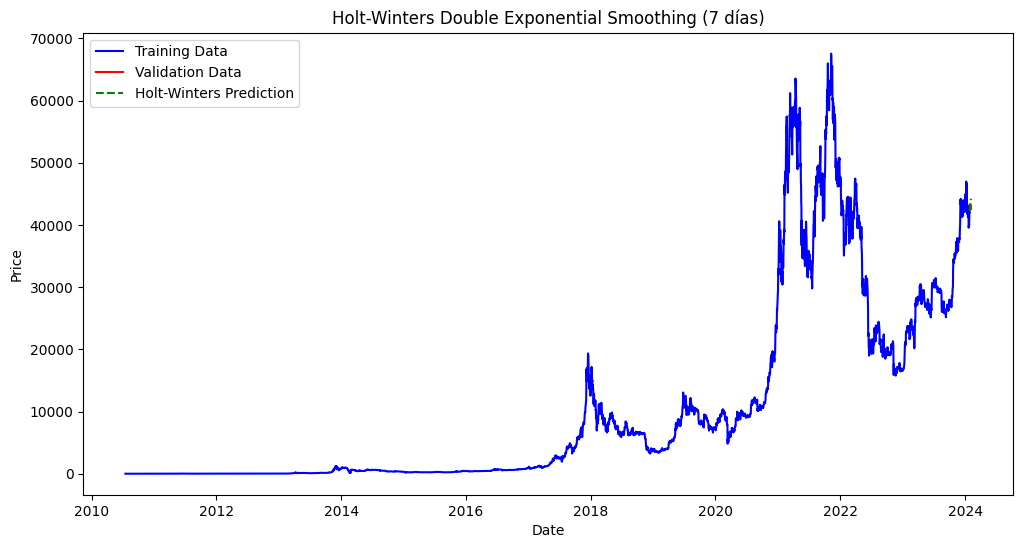

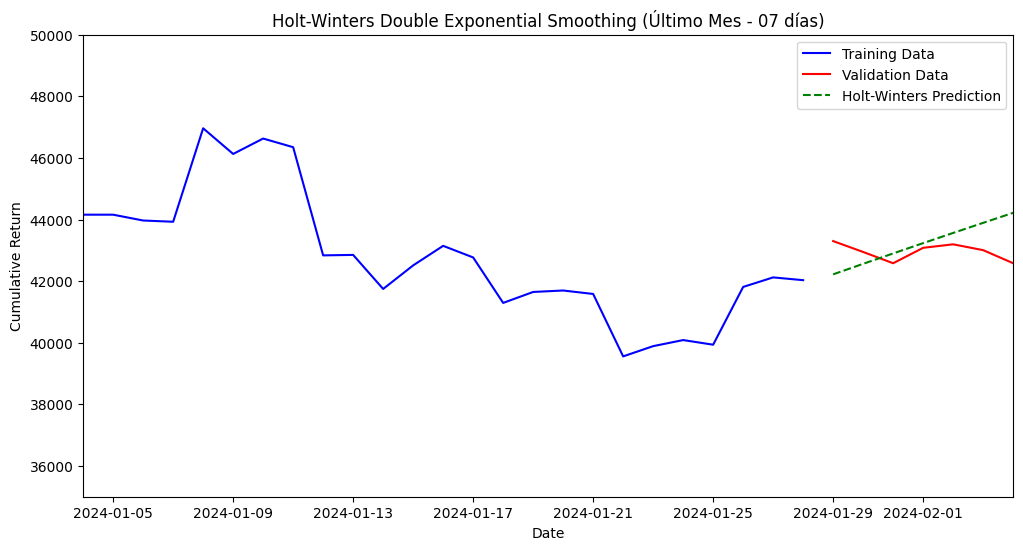

MAPE: 1.61%
MAE: 689.57
MSE: 719388.17
RMSE: 848.17
R² Score: -9.6062


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# División en entrenamiento, validación y test (entrenamiento fijo)
train_size = len(df) - (28 + 28)
train = df.iloc[:train_size]['Price']
val = df.iloc[train_size:train_size+7]['Price']  # Validación de 7 días
test = df.iloc[train_size+7:train_size+7+7]['Price']  # Test de 7 días

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (7 días)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(35000, 50000)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 07 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Variable Precio: Ventana 07 dias - Segunda parte.

       MAPE         MAE        RMSE            MSE        R²  \
0  1.607033  689.574329  848.167535  719388.167827 -9.606153   

   Ljung-Box (p-value)  Brock-Dechert-Scheinkman (p-value)  \
0        6.614373e-296                        7.220548e-09   

   Jarque-Bera (p-value)  
0                    0.0  


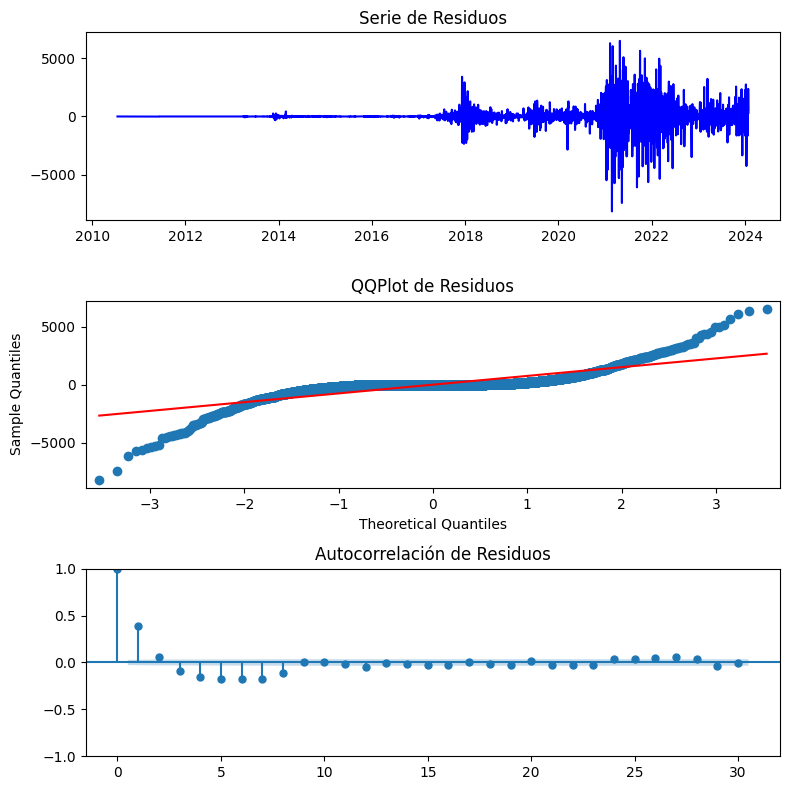

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Variable Precio: Ventana 14 dias - Primera parte.

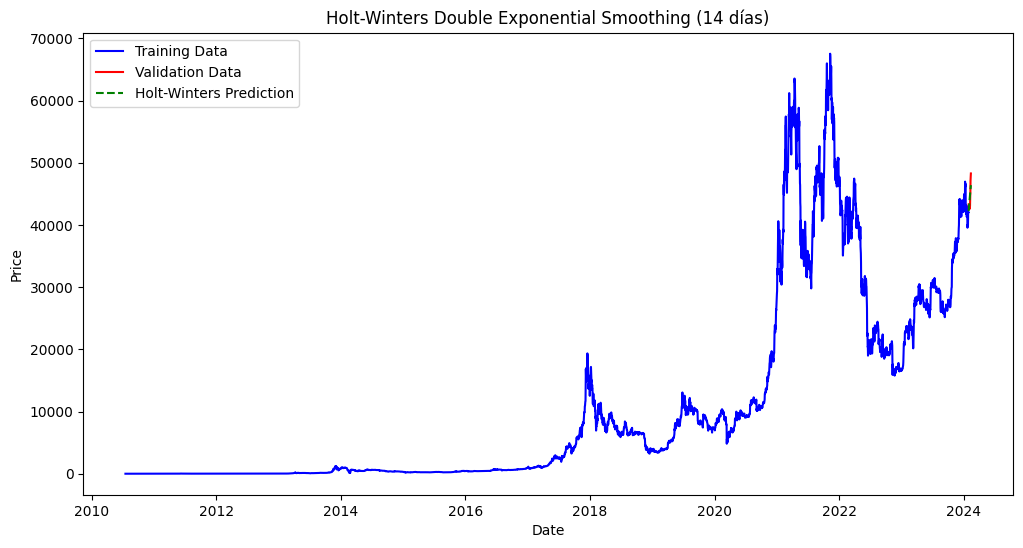

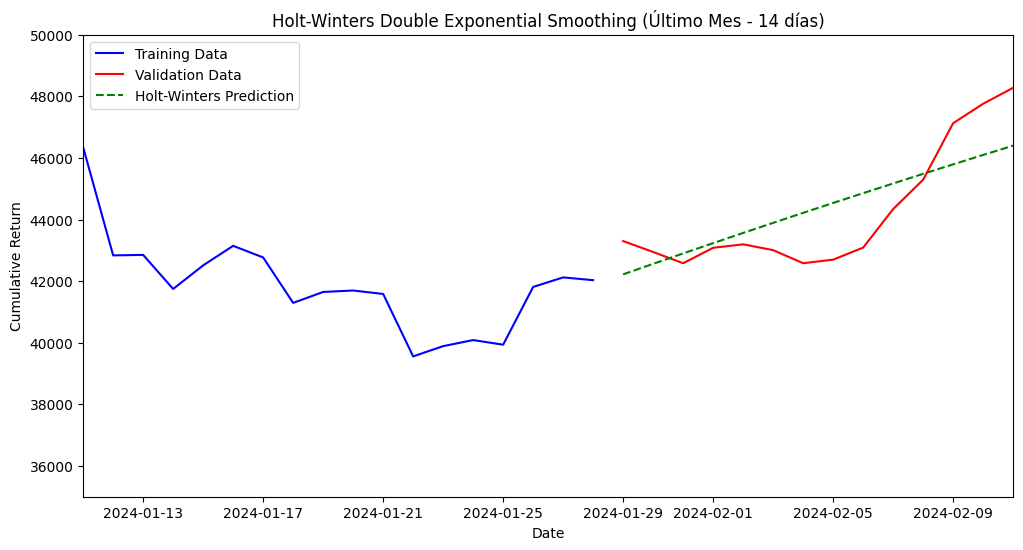

MAPE: 2.30%
MAE: 1023.76
MSE: 1453748.53
RMSE: 1205.71
R² Score: 0.6221


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# División en entrenamiento, validación y test para 14 días
train_size = len(df) - (28 + 28)  # El conjunto de entrenamiento es fijo
train = df.iloc[:train_size]['Price']
val = df.iloc[train_size:train_size+14]['Price']  # Validación de 14 días
test = df.iloc[train_size+14:train_size+14+14]['Price']  # Test de 14 días

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (14 días)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(35000, 50000)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 14 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Variable Precio: Ventana 14 dias - Segunda parte.

       MAPE          MAE         RMSE           MSE        R²  \
0  2.297289  1023.762866  1205.714944  1.453749e+06  0.622146   

   Ljung-Box (p-value)  Brock-Dechert-Scheinkman (p-value)  \
0        6.614373e-296                        7.220548e-09   

   Jarque-Bera (p-value)  
0                    0.0  


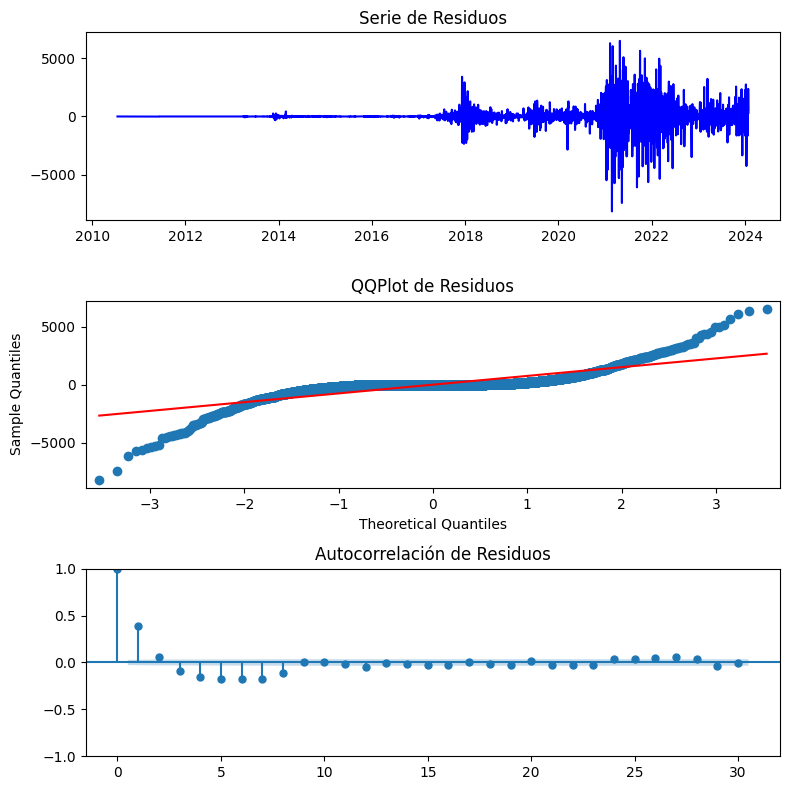

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Variable Precio: Ventana 21 dias - Primera parte.

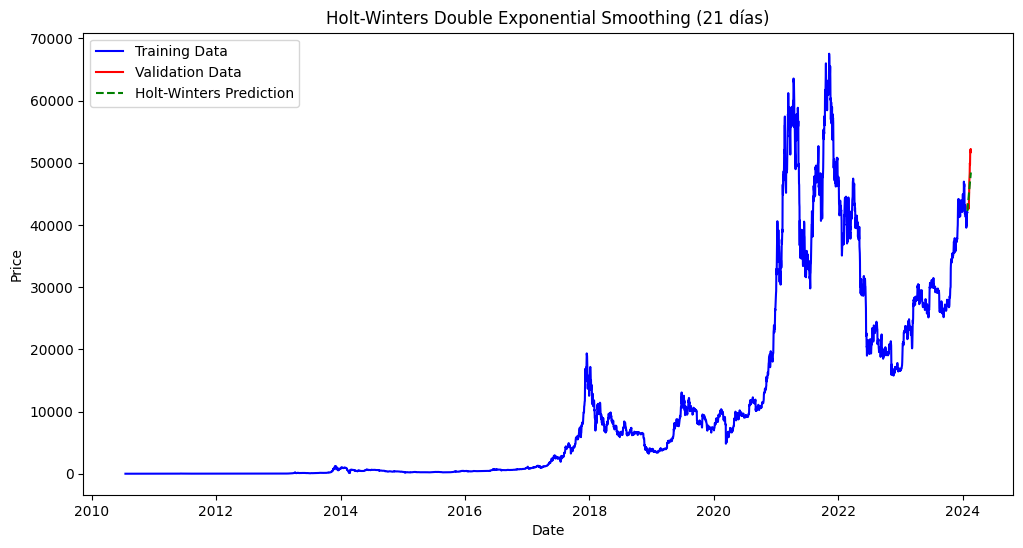

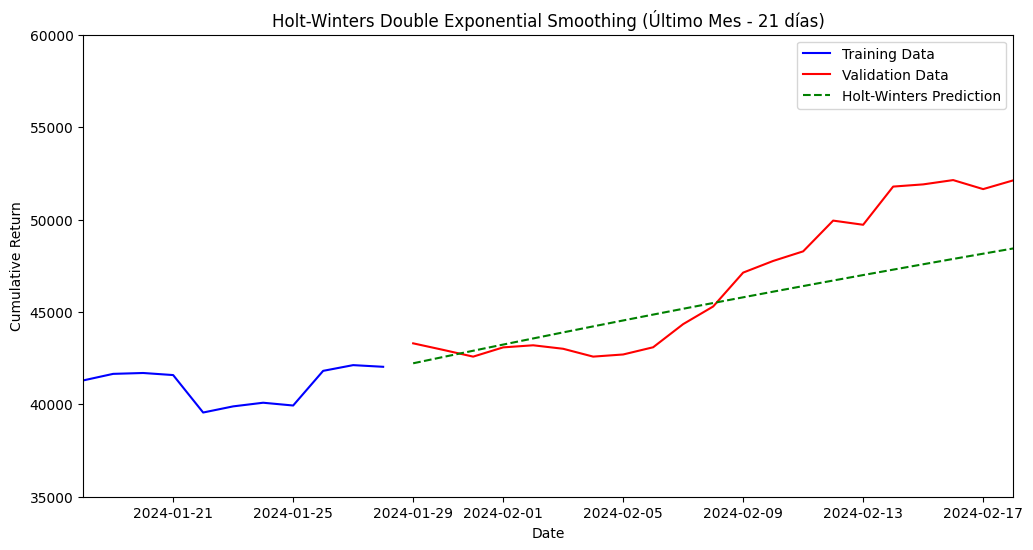

MAPE: 3.96%
MAE: 1931.46
MSE: 5769483.44
RMSE: 2401.97
R² Score: 0.5888
MAPE: 3.96%
MAE: 1931.46
MSE: 5769483.44
RMSE: 2401.97
R² Score: 0.5888


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# División en entrenamiento, validación y test para 21 días
train_size = len(df) - (28 + 28)
train = df.iloc[:train_size]['Price']
val = df.iloc[train_size:train_size+21]['Price']
test = df.iloc[train_size+21:]['Price']

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (21 días)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(35000, 60000)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 21 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mean_absolute_error(val, val_pred):.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Variable Precio: Ventana 21 dias - Segunda parte.

      MAPE          MAE         RMSE           MSE       R²  \
0  3.95995  1931.457935  2401.974903  5.769483e+06  0.58877   

   Ljung-Box (p-value)  Brock-Dechert-Scheinkman (p-value)  \
0        6.614373e-296                        7.220548e-09   

   Jarque-Bera (p-value)  
0                    0.0  


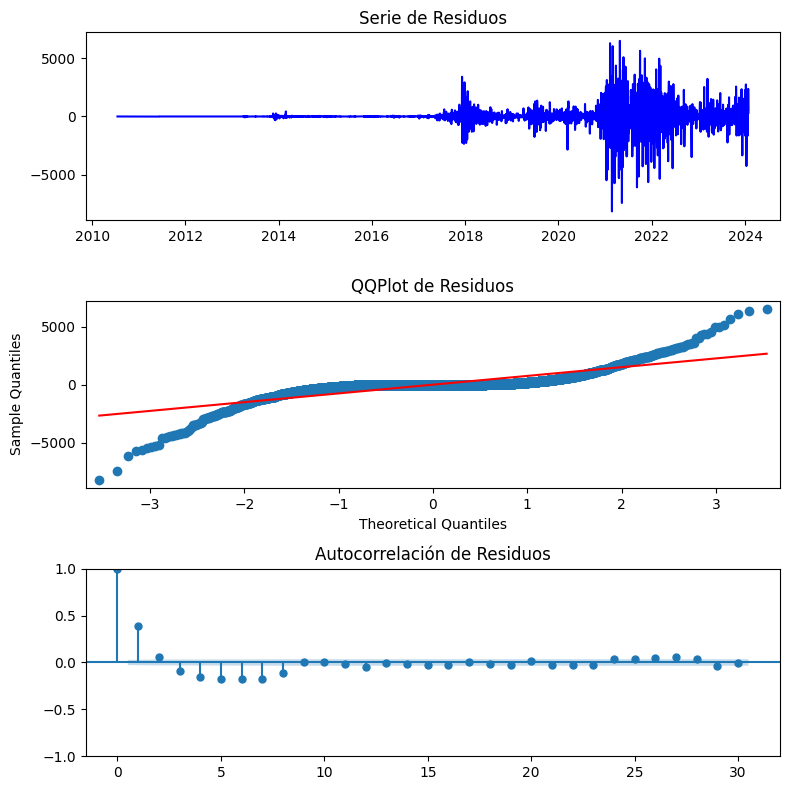

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Variable Precio: Ventana 28 dias - Primera parte.

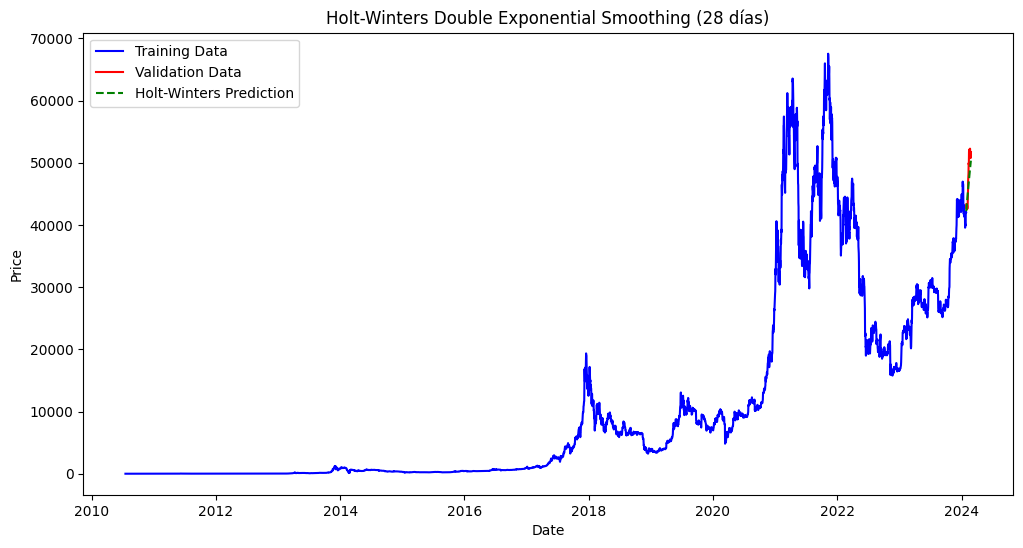

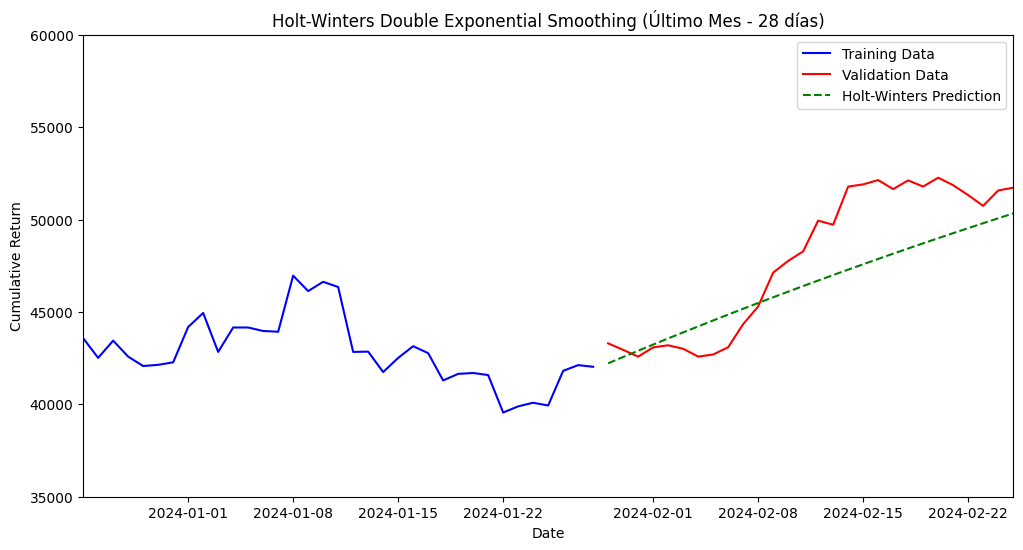

MAPE: 3.98%
MAE: 1968.95
MSE: 5583928.67
RMSE: 2363.03
R² Score: 0.6346


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# División en entrenamiento, validación y test
train_size = len(df) - (28 + 28)
train = df.iloc[:train_size]['Price']
val = df.iloc[train_size:train_size+28]['Price']
test = df.iloc[train_size+28:]['Price']

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (28 días)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=2)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(35000, 60000)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 28 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')


Precio: Ventana 28 dias - Segunda parte.

       MAPE         MAE         RMSE           MSE        R²  \
0  3.975486  1968.95096  2363.033785  5.583929e+06  0.634637   

   Ljung-Box (p-value)  Brock-Dechert-Scheinkman (p-value)  \
0        6.614373e-296                        7.220548e-09   

   Jarque-Bera (p-value)  
0                    0.0  


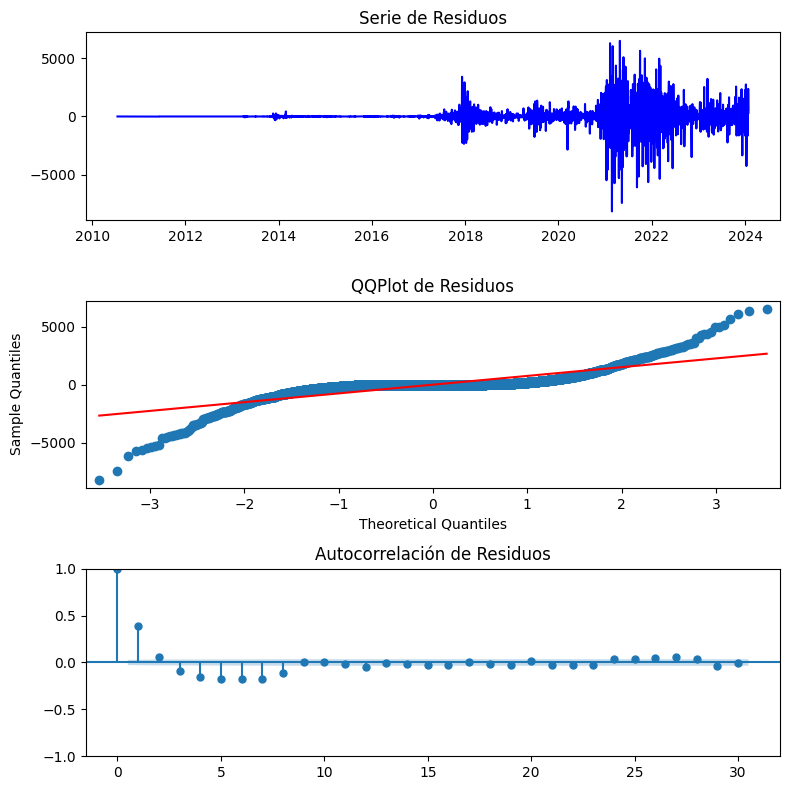

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Price"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Retorno Acumulado: Ventana 07 dias - Primera parte.

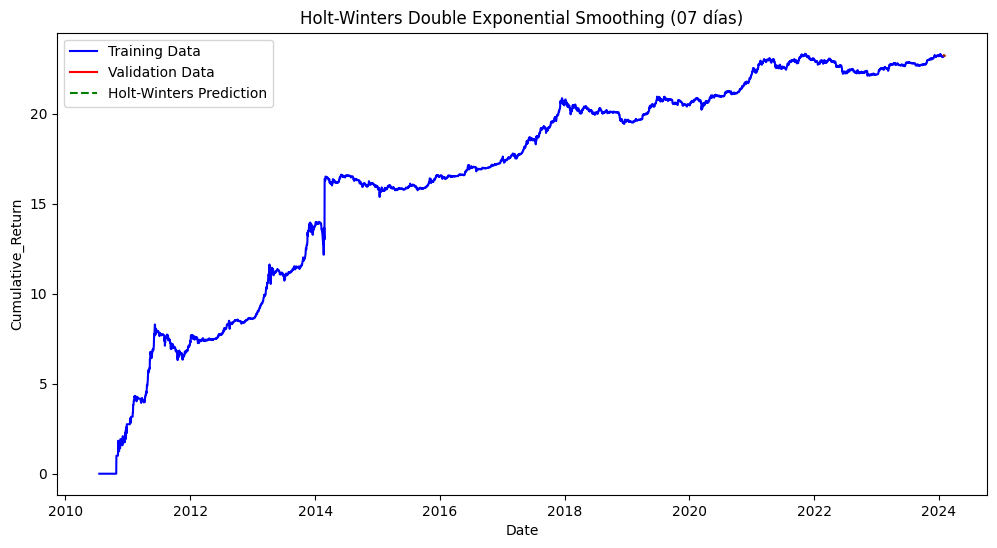

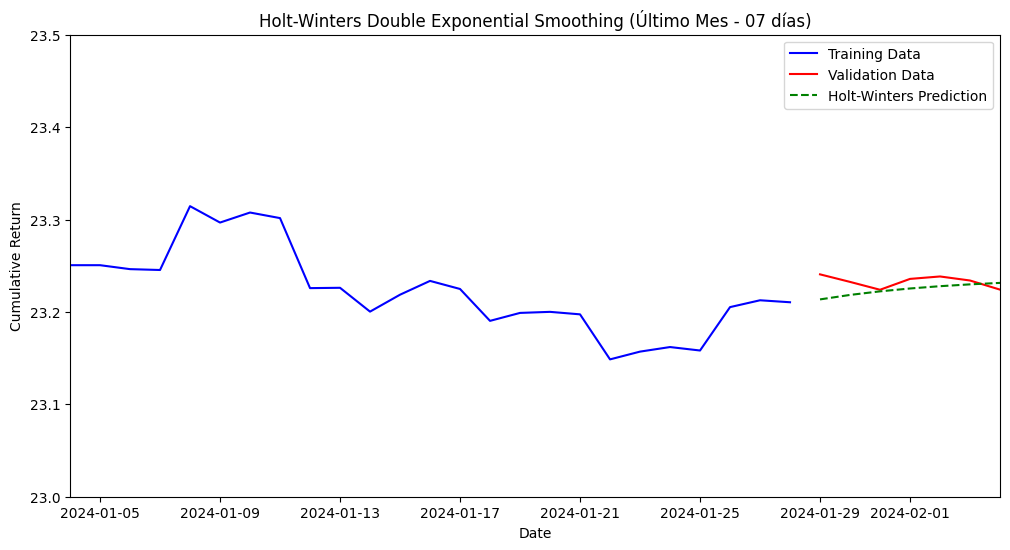

MAPE: 0.05%
MAE: 0.01
MSE: 0.00
RMSE: 0.01
R² Score: -3.7858


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# División en entrenamiento, validación y test para 7 días
train_size = len(df) - (28 + 28)  # El conjunto de entrenamiento es fijo
train = df.iloc[:train_size]['Cumulative_Return']
val = df.iloc[train_size:train_size+7]['Cumulative_Return']  # Validación de 7 días
test = df.iloc[train_size+7:train_size+7+7]['Cumulative_Return']  # Test de 7 días

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (07 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative_Return')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(23, 23.5)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 07 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mean_absolute_error(val, val_pred):.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Retorno Acumulado: Ventana 07 dias - Segunda parte.

       MAPE       MAE      RMSE       MSE        R²  Ljung-Box (p-value)  \
0  0.046269  0.010751  0.013229  0.000175 -3.785782        1.508391e-127   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.177048                    0.0  


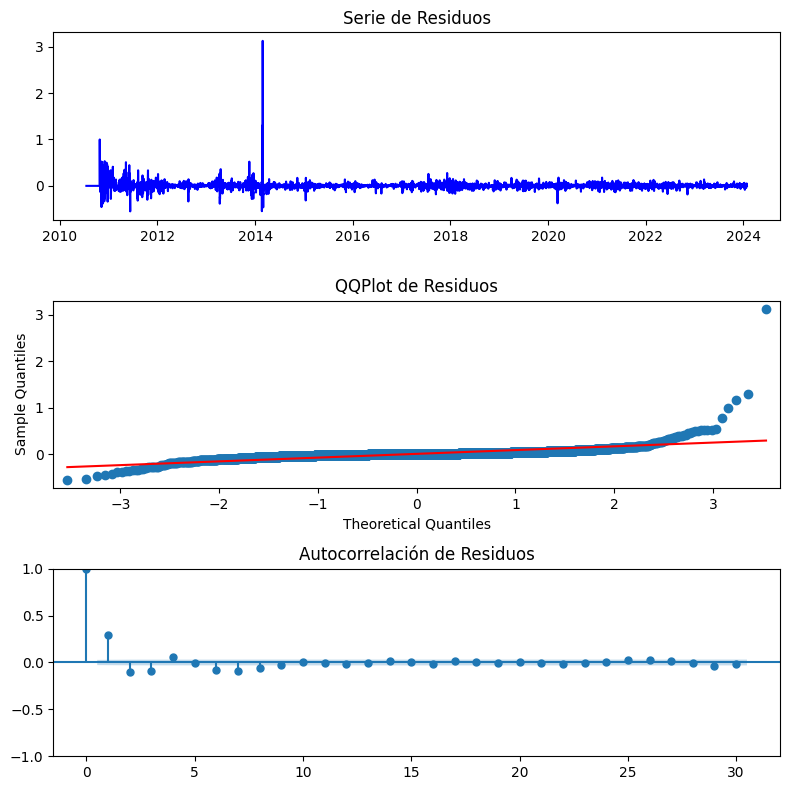

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Retorno Acumulado: Ventana 14 dias - Primera parte.

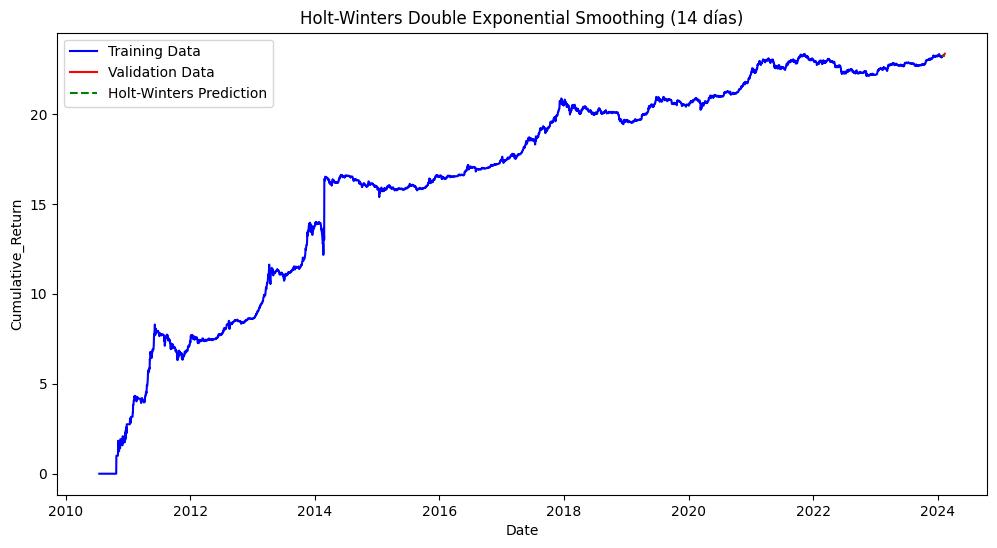

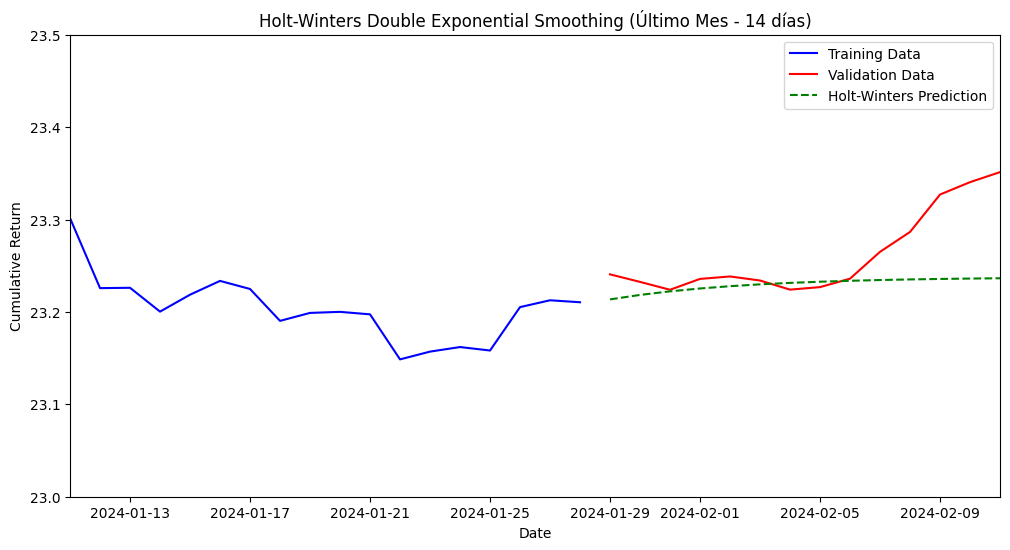

MAPE: 0.15%
MAE: 0.03
MSE: 0.00
RMSE: 0.05
R² Score: -0.3742


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# División en entrenamiento, validación y test para 14 días
train_size = len(df) - (28 + 28)  # El conjunto de entrenamiento es fijo
train = df.iloc[:train_size]['Cumulative_Return']
val = df.iloc[train_size:train_size+14]['Cumulative_Return']  # Validación de 14 días
test = df.iloc[train_size+14:train_size+14+14]['Cumulative_Return']  # Test de 14 días

# Aplicar doble suavización Holt-Winters
alpha = 0.5  # Parámetro de nivel
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular los residuos (errores del modelo en el conjunto de entrenamiento)
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (14 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative_Return')
plt.show()

# Visualización del último año de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')


# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(23, 23.5)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 14 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Retorno Acumulado: Ventana 14 dias - Segunda parte.

      MAPE       MAE      RMSE       MSE        R²  Ljung-Box (p-value)  \
0  0.14582  0.033993  0.051595  0.002662 -0.374168        1.508391e-127   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.177048                    0.0  


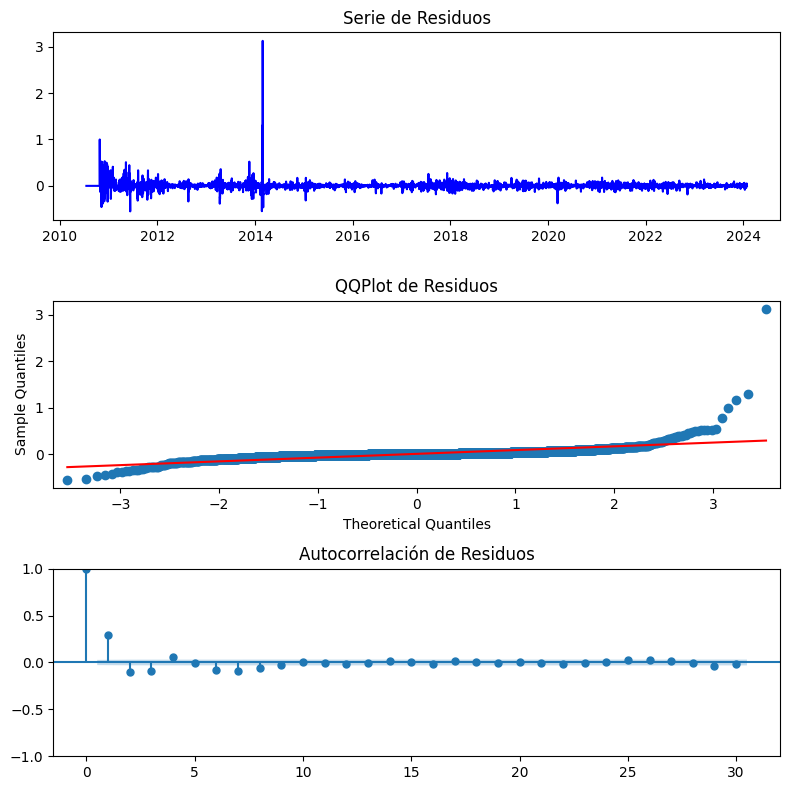

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from arch.unitroot import VarianceRatio

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Retorno Acumulado: Ventana 21 dias - Primera parte.

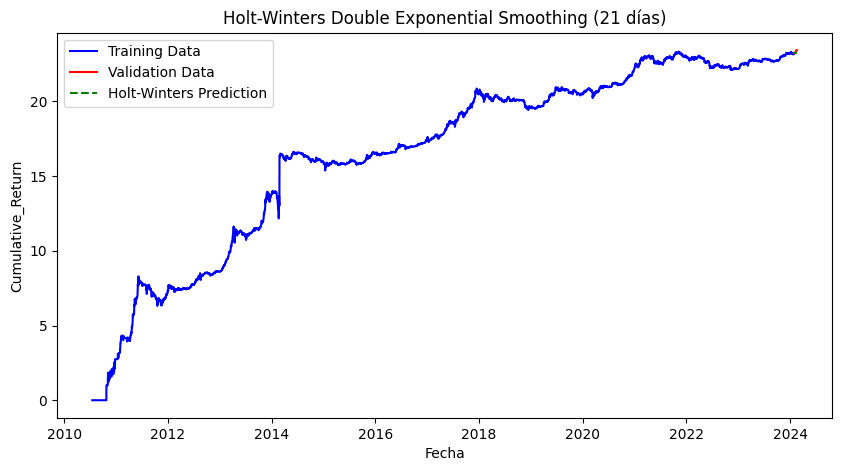

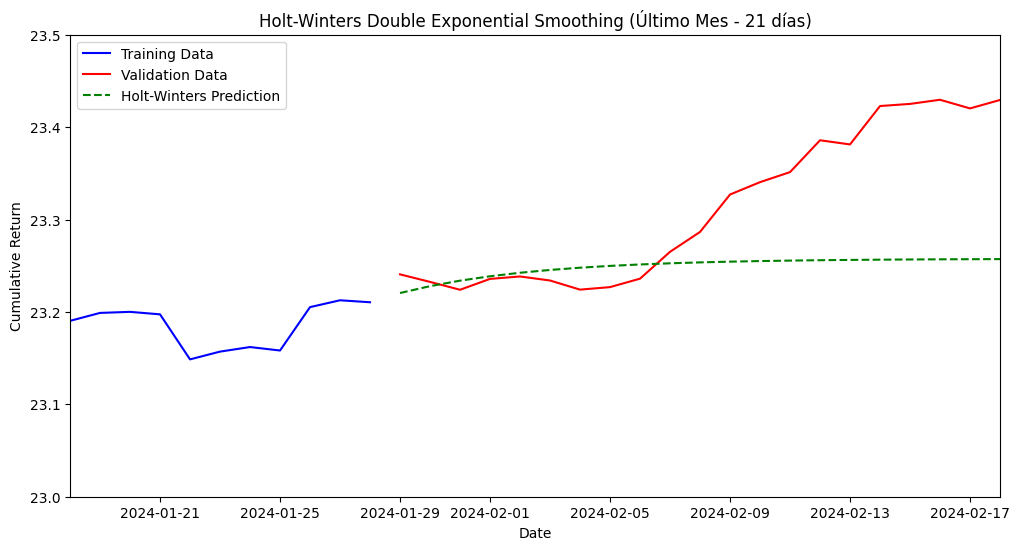

MAPE: 0.31%
MAE: 0.07
MSE: 0.01
RMSE: 0.10
R² Score: -0.4534


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 21 días de validación y 21 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba
train = df.iloc[:train_size]['Cumulative_Return']
val = df.iloc[train_size:train_size+21]['Cumulative_Return']
test = df.iloc[train_size+21:train_size+42]['Cumulative_Return']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=alpha)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuos = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Cumulative_Return')
plt.title('Holt-Winters Double Exponential Smoothing (21 días)')
plt.legend()
plt.show()

# Zoom de  resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(23, 23.5)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 21 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Retorno Acumulado: Ventana 21 dias - Segunda parte.

      MAPE       MAE      RMSE       MSE       R²  Ljung-Box (p-value)  \
0  0.30783  0.071986  0.097482  0.009503 -0.45339        1.508391e-127   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.177048                    0.0  


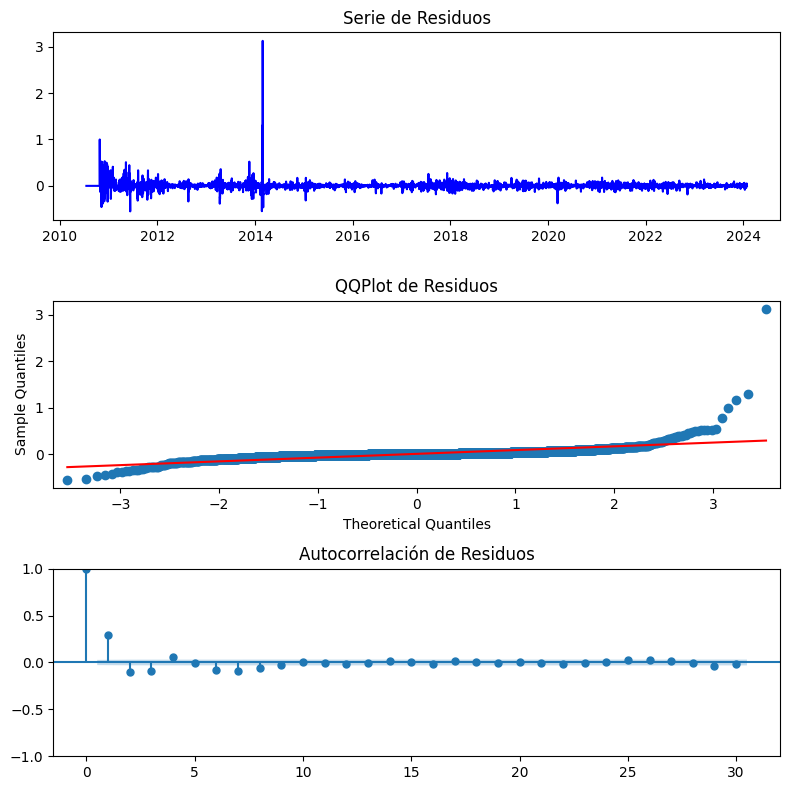

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()
 
# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Retorno Acumulado: Ventana 28 dias - Primera parte.

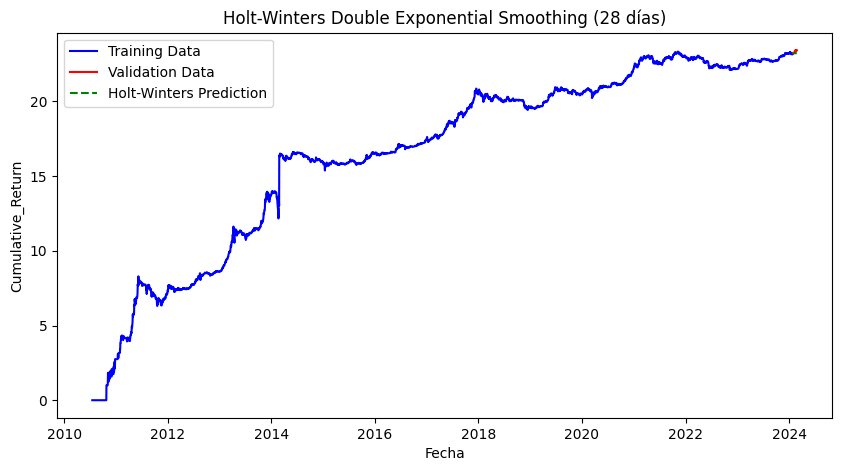

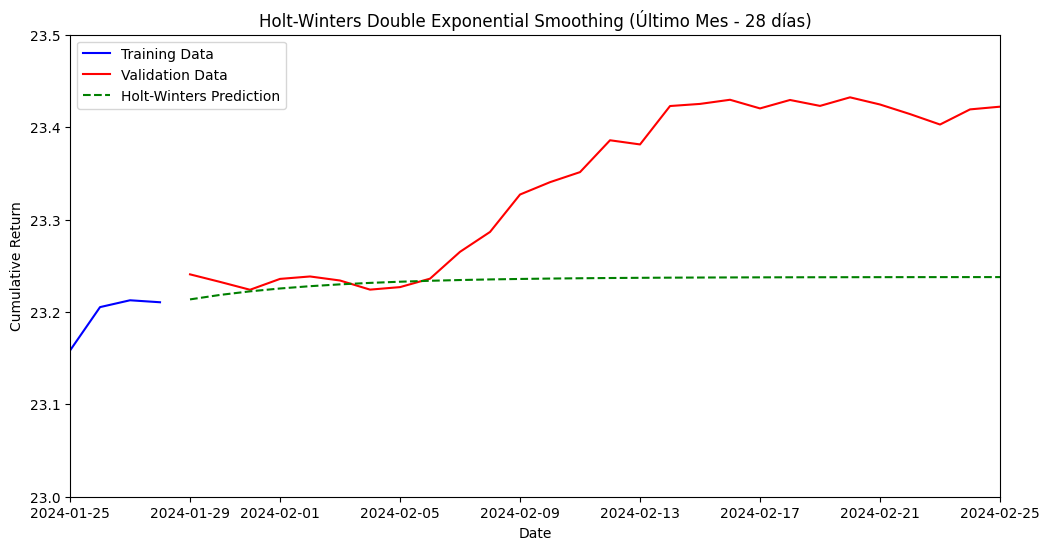

MAPE: 0.46%
MAE: 0.11
MSE: 0.02
RMSE: 0.13
R² Score: -1.4686


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba
train = df.iloc[:train_size]['Cumulative_Return']
val = df.iloc[train_size:train_size+28]['Cumulative_Return']
test = df.iloc[train_size+28:train_size+56]['Cumulative_Return']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Cumulative_Return')
plt.title('Holt-Winters Double Exponential Smoothing (28 días)')
plt.legend()
plt.show()

# Zoom de  resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

# Ajustar los límites del eje Y
plt.ylim(23, 23.5)

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 28 días)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Retorno Acumulado: Ventana 28 dias - Segunda parte.

       MAPE       MAE      RMSE       MSE        R²  Ljung-Box (p-value)  \
0  0.455481  0.106586  0.132275  0.017497 -1.468552        1.508391e-127   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.177048                    0.0  


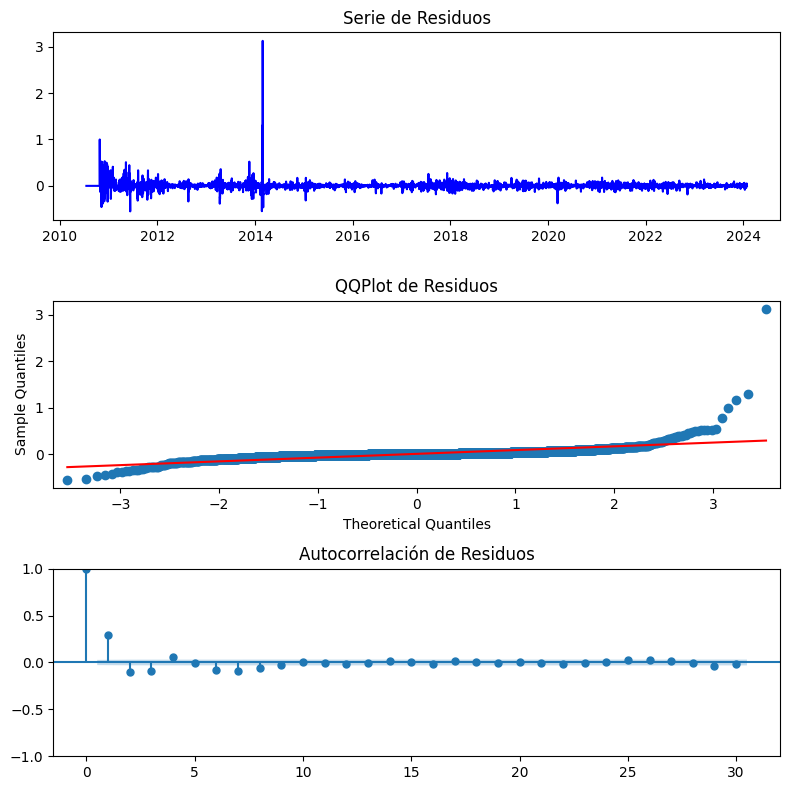

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Cumulative_Return"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Volatilidad: Ventana 07 días - Primera parte

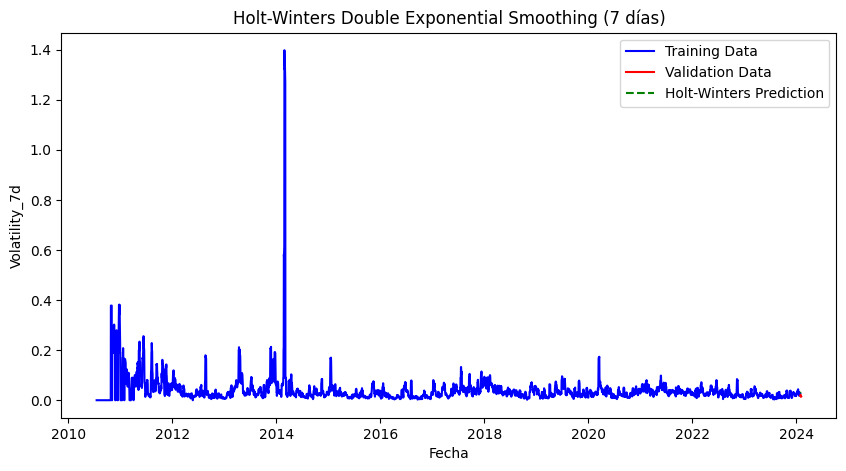

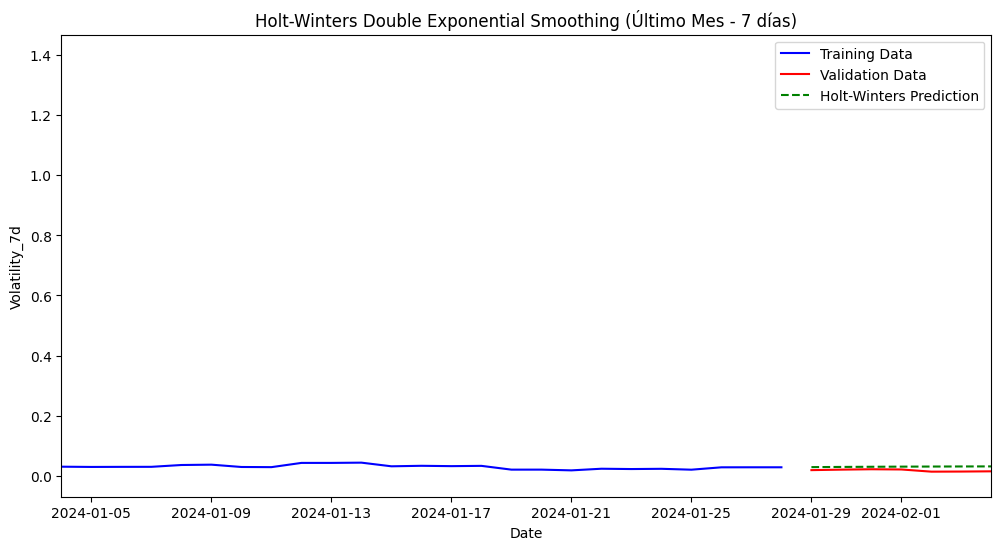

MAPE: 77.38%
MAE: 0.01
MSE: 0.00
RMSE: 0.01
R² Score: -15.1827


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_7d"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba (7 días de validación y prueba)
train = df.iloc[:train_size]['Volatility_7d']
val = df.iloc[train_size:train_size+7]['Volatility_7d']
test = df.iloc[train_size+7:train_size+14]['Volatility_7d']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Volatility_7d')
plt.title('Holt-Winters Double Exponential Smoothing (7 días)')
plt.legend()
plt.show()

# Zoom de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 7 días)')
plt.xlabel('Date')
plt.ylabel('Volatility_7d')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Volatilidad: Ventana 07 días - Segunda parte

        MAPE       MAE      RMSE       MSE         R²  Ljung-Box (p-value)  \
0  77.380763  0.012434  0.013002  0.000169 -15.182702                  0.0   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.220369                    0.0  


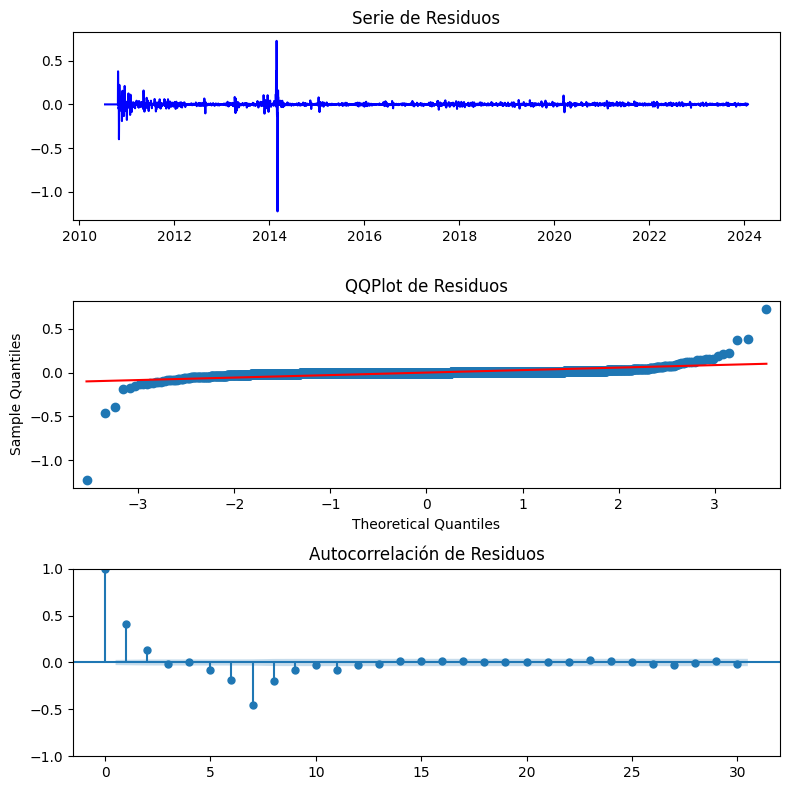

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_7d"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Volatilidad: Ventana 14 días - Primera parte

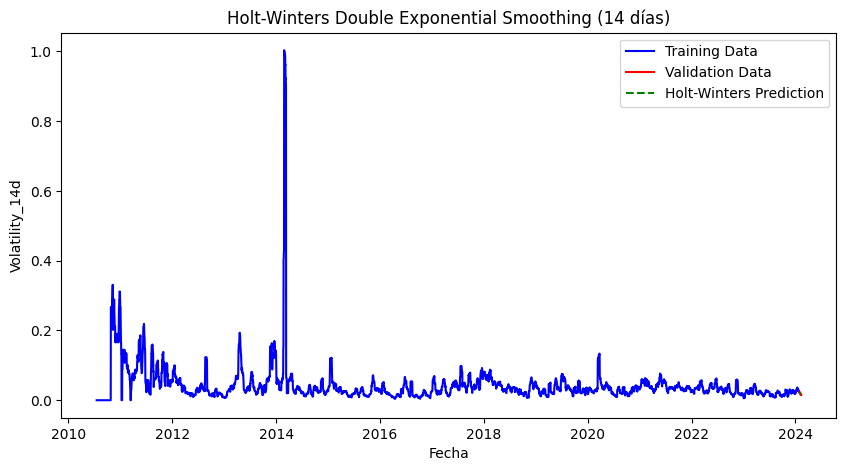

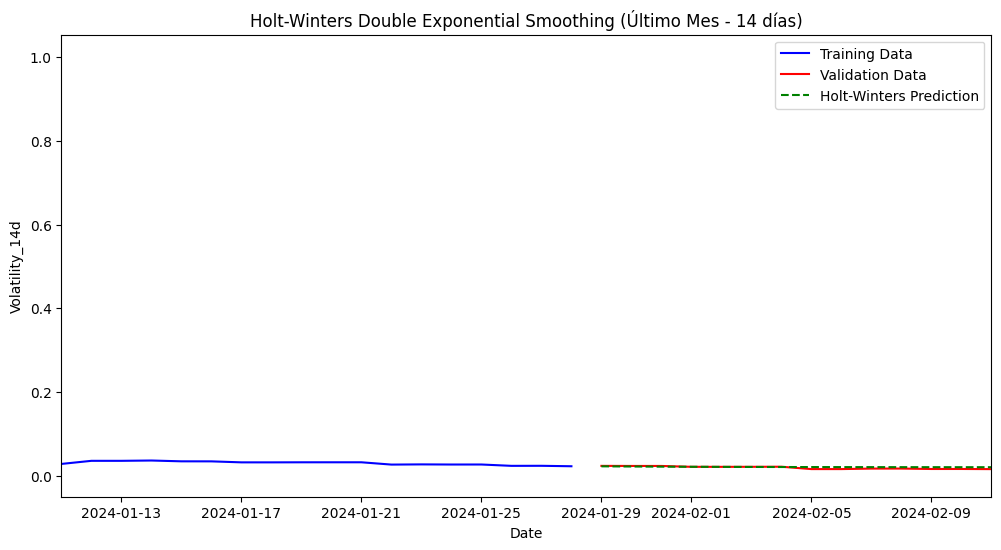

MAPE: 14.80%
MAE: 0.00
MSE: 0.00
RMSE: 0.00
R² Score: -0.0069


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_14d"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba (14 días de validación y prueba)
train = df.iloc[:train_size]['Volatility_14d']
val = df.iloc[train_size:train_size+14]['Volatility_14d']
test = df.iloc[train_size+14:train_size+28]['Volatility_14d']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Volatility_14d')
plt.title('Holt-Winters Double Exponential Smoothing (14 días)')
plt.legend()
plt.show()

# Zoom de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 14 días)')
plt.xlabel('Date')
plt.ylabel('Volatility_14d')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Volatilidad: Ventana 14 días - Segunda parte

        MAPE       MAE      RMSE      MSE        R²  Ljung-Box (p-value)  \
0  14.800085  0.002504  0.003104  0.00001 -0.006932        9.202753e-148   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.298405                    0.0  


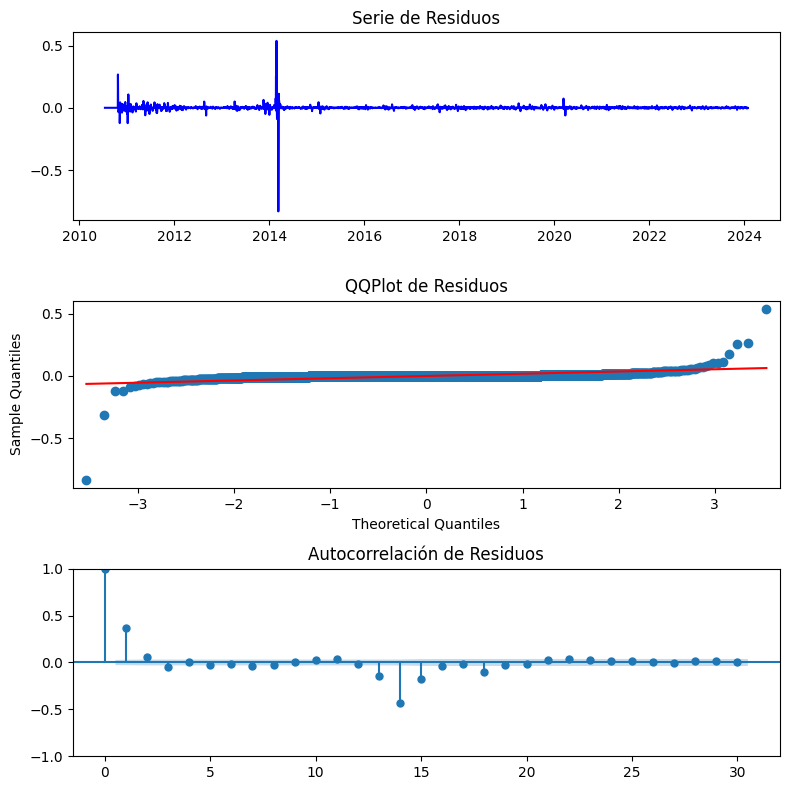

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_14d"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Volatilidad: Ventana 21 días - Primera parte

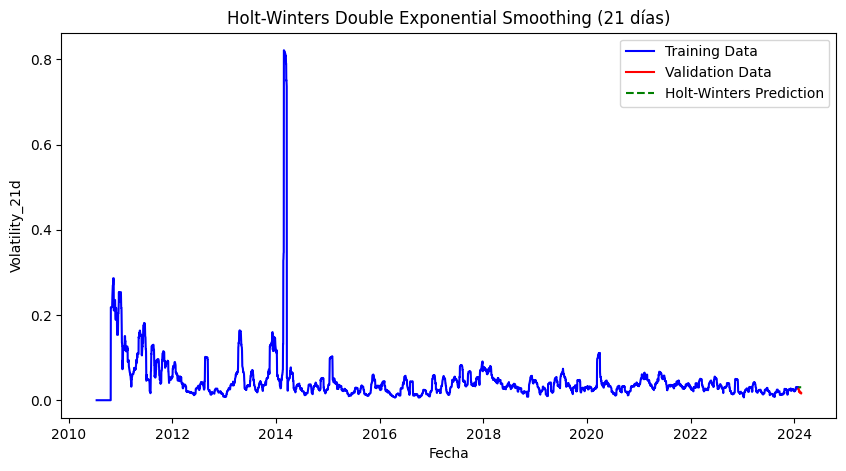

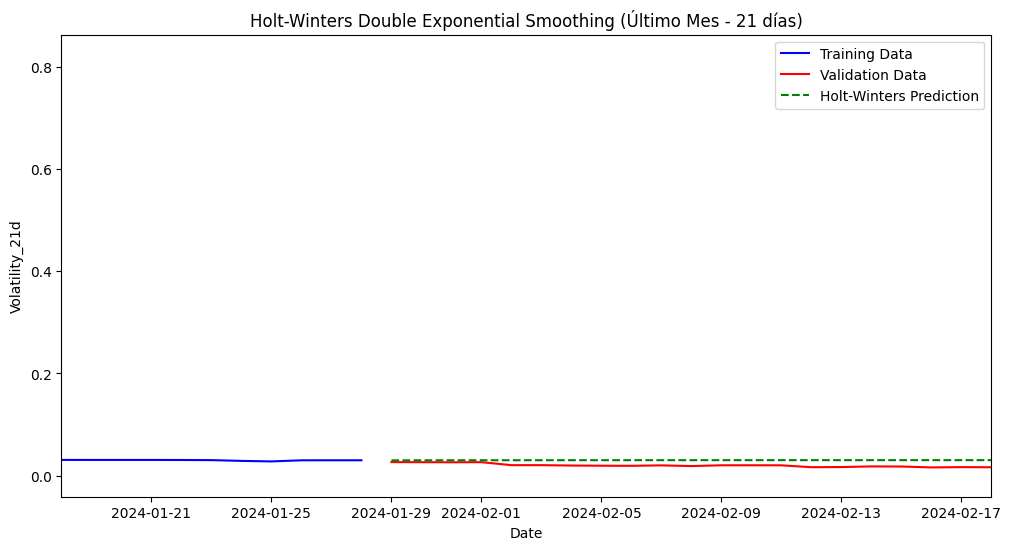

MAPE: 53.54%
MAE: 0.01
MSE: 0.00
RMSE: 0.01
R² Score: -9.2236


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_21d"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba (21 días de validación y prueba)
train = df.iloc[:train_size]['Volatility_21d']
val = df.iloc[train_size:train_size+21]['Volatility_21d']
test = df.iloc[train_size+21:train_size+42]['Volatility_21d']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Volatility_21d')
plt.title('Holt-Winters Double Exponential Smoothing (21 días)')
plt.legend()
plt.show()

# Zoom de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 21 días)')
plt.xlabel('Date')
plt.ylabel('Volatility_21d')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Volatilidad: Ventana 21 días - Segunda parte

        MAPE      MAE      RMSE       MSE        R²  Ljung-Box (p-value)  \
0  53.542646  0.01009  0.010656  0.000114 -9.223559        2.682208e-156   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.324522                    0.0  


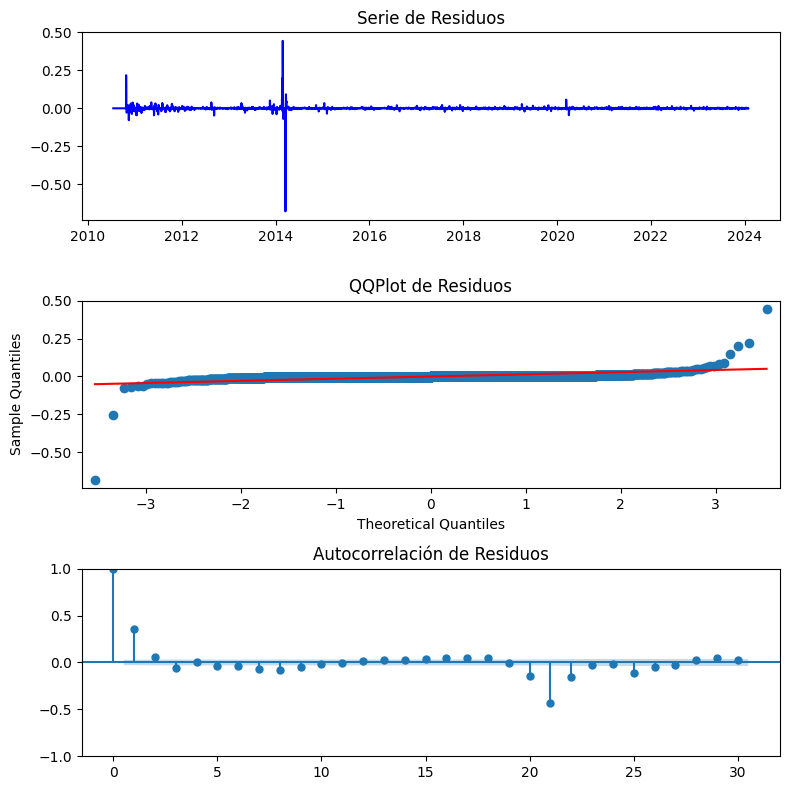

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_21d"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

Volatilidad: Ventana 28 días - Primera parte

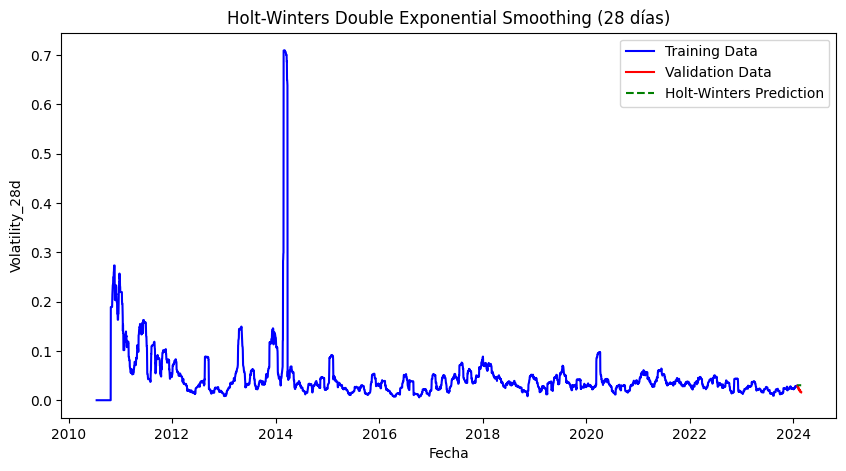

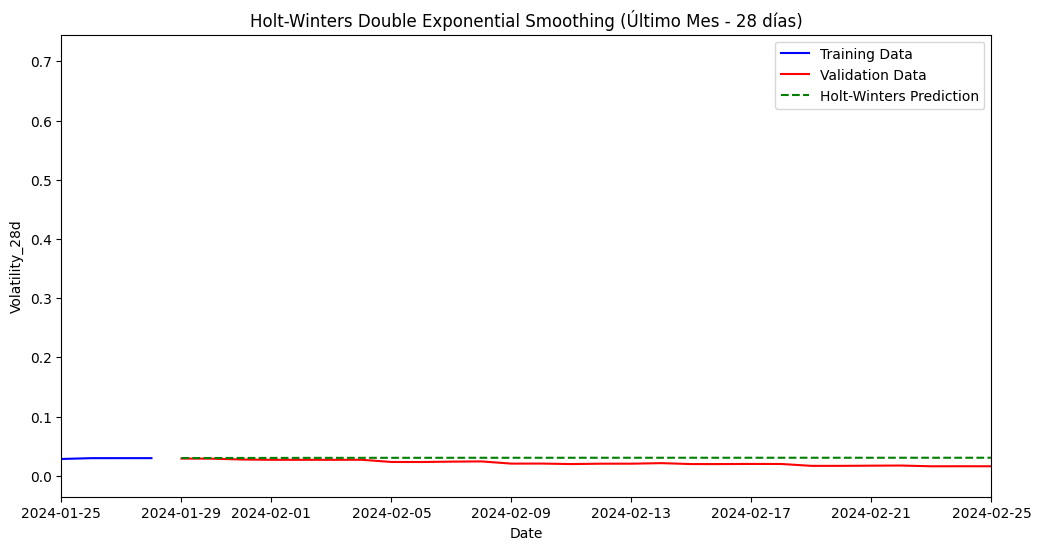

MAPE: 45.45%
MAE: 0.01
MSE: 0.00
RMSE: 0.01
R² Score: -4.4975


In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_28d"]]

# Definir el tamaño del conjunto de entrenamiento (fijo)
train_size = len(df) - (28 + 28)  # Se resta 28 días de validación y 28 días de prueba

# Dividir la serie temporal en conjuntos de entrenamiento, validación y prueba (28 días de validación y prueba)
train = df.iloc[:train_size]['Volatility_28d']
val = df.iloc[train_size:train_size+28]['Volatility_28d']
test = df.iloc[train_size+28:train_size+56]['Volatility_28d']

# Aplicar modelo Holt-Winters con suavización exponencial
alpha = 0.5  # Parámetro de suavización
beta = 0.3   # Parámetro de tendencia
hw_model = ExponentialSmoothing(train, trend='additive', damped_trend=True).fit(smoothing_level=alpha, smoothing_trend=beta)
val_pred = hw_model.forecast(steps=len(val))

# Calcular residuos
residuals = train - hw_model.fittedvalues

# Visualización de resultados
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')
plt.xlabel('Fecha')
plt.ylabel('Volatility_28d')
plt.title('Holt-Winters Double Exponential Smoothing (28 días)')
plt.legend()
plt.show()

# Zoom de resultados
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(val.index, val, label='Validation Data', color='red')
plt.plot(val.index, val_pred, label='Holt-Winters Prediction', color='green', linestyle='dashed')

# Ajustar los límites del eje X para mostrar solo el último mes
ultimo_mes = val.index.max() - pd.DateOffset(months=1)
plt.xlim(ultimo_mes, val.index.max())

plt.legend()
plt.title('Holt-Winters Double Exponential Smoothing (Último Mes - 28 días)')
plt.xlabel('Date')
plt.ylabel('Volatility_28d')
plt.show()

# Cálculo de métricas de error
mae = mean_absolute_error(val, val_pred)
mape = np.mean(np.abs((val - val_pred) / val) * 100)  
mse = mean_squared_error(val, val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(val, val_pred)

# Mostrar resultados
print(f'MAPE: {mape:.2f}%')
print(f'MAE: {mae:.2f}')
print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.4f}')

Volatilidad: Ventana 28 días - Segunda parte

        MAPE       MAE      RMSE       MSE       R²  Ljung-Box (p-value)  \
0  45.448421  0.008682  0.009666  0.000093 -4.49746        1.988208e-147   

   Brock-Dechert-Scheinkman (p-value)  Jarque-Bera (p-value)  
0                            0.329657                    0.0  


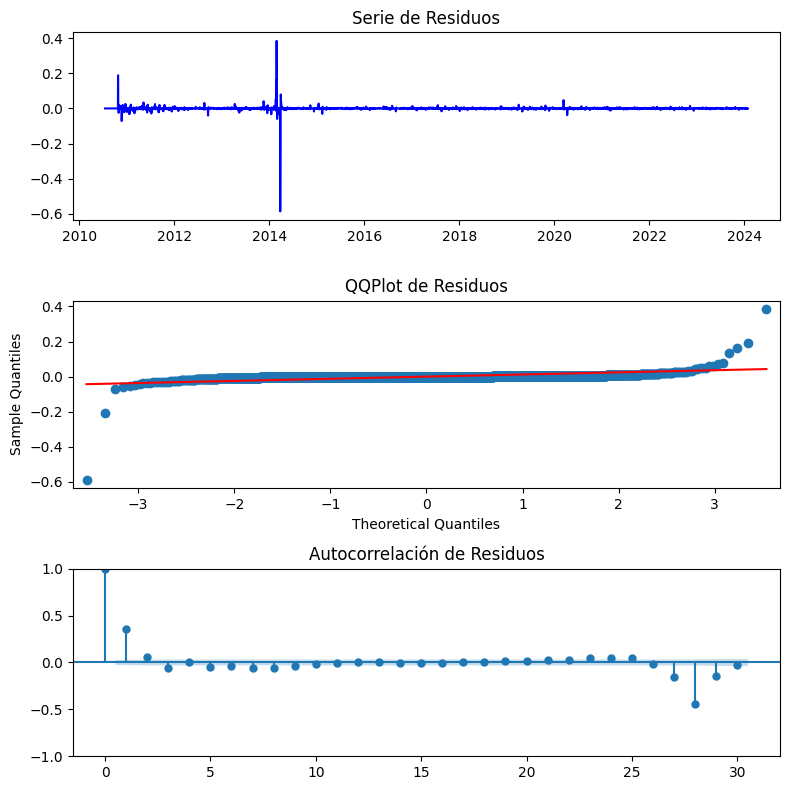

In [ ]:
import warnings
warnings.filterwarnings("ignore")
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)
 
def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)
 
df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)
 
# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()
 
# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0
 
# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()
 
df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)
df = df[["Volatility_28d"]]

# Pruebas de hipótesis sobre los residuos
ljung_box_p = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]  # Independencia
variance_ratio_p = VarianceRatio(residuals).pvalue  # Brock-Dechert-Scheinkman test (aprox. con Variance Ratio)
jarque_bera_p = jarque_bera(residuals)[1]  # Normalidad

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame({
    'MAPE': [mape],
    'MAE': [mae],
    'RMSE': [rmse],
    'MSE': [mse],
    'R²': [r2],
    'Ljung-Box (p-value)': [ljung_box_p],
    'Brock-Dechert-Scheinkman (p-value)': [variance_ratio_p],
    'Jarque-Bera (p-value)': [jarque_bera_p]
})

# Mostrar la tabla con los resultados
print(metrics_df)

# Gráficos de los residuos
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# Serie de residuos
axes[0].plot(residuals, color='blue')
axes[0].set_title("Serie de Residuos")

# QQPlot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title("QQPlot de Residuos")

# Autocorrelación (ACF)
sm.graphics.tsa.plot_acf(residuals, ax=axes[2], lags=30)
axes[2].set_title("Autocorrelación de Residuos")

plt.tight_layout()
plt.show()

### ARIMA (Usando Rolling)

Precio

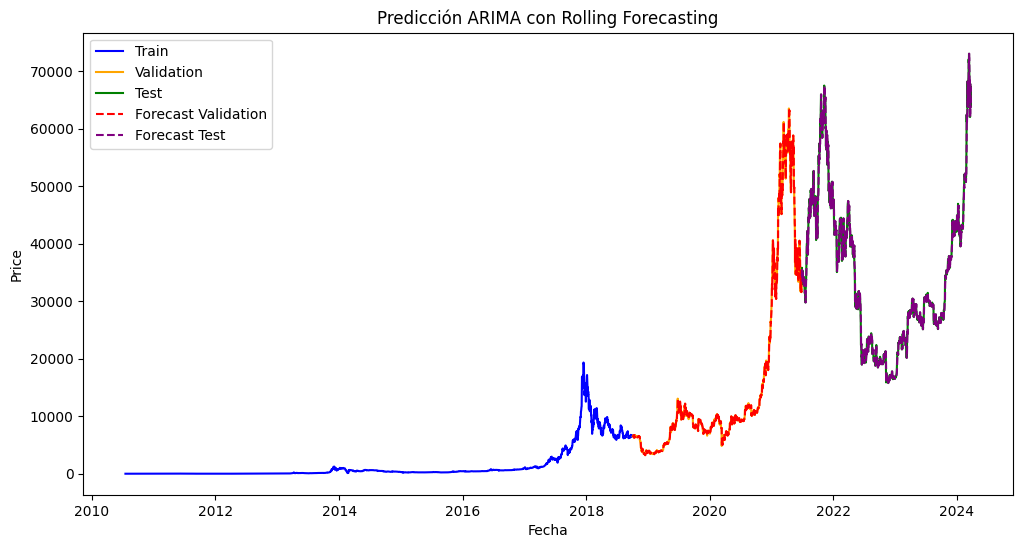


Errores en validación:
MAPE: 2.6430
MAE: 463.1694
MSE: 919197.3164
RMSE: 958.7478
R²: 0.9961

Errores en test:
MAPE: 2.0811
MAE: 747.4254
MSE: 1364650.4058
RMSE: 1168.1825
R²: 0.9918

Pruebas de hipótesis sobre residuos:
Ljung-Box (p-value): 0.0000
Jarque-Bera (p-value): 0.0000


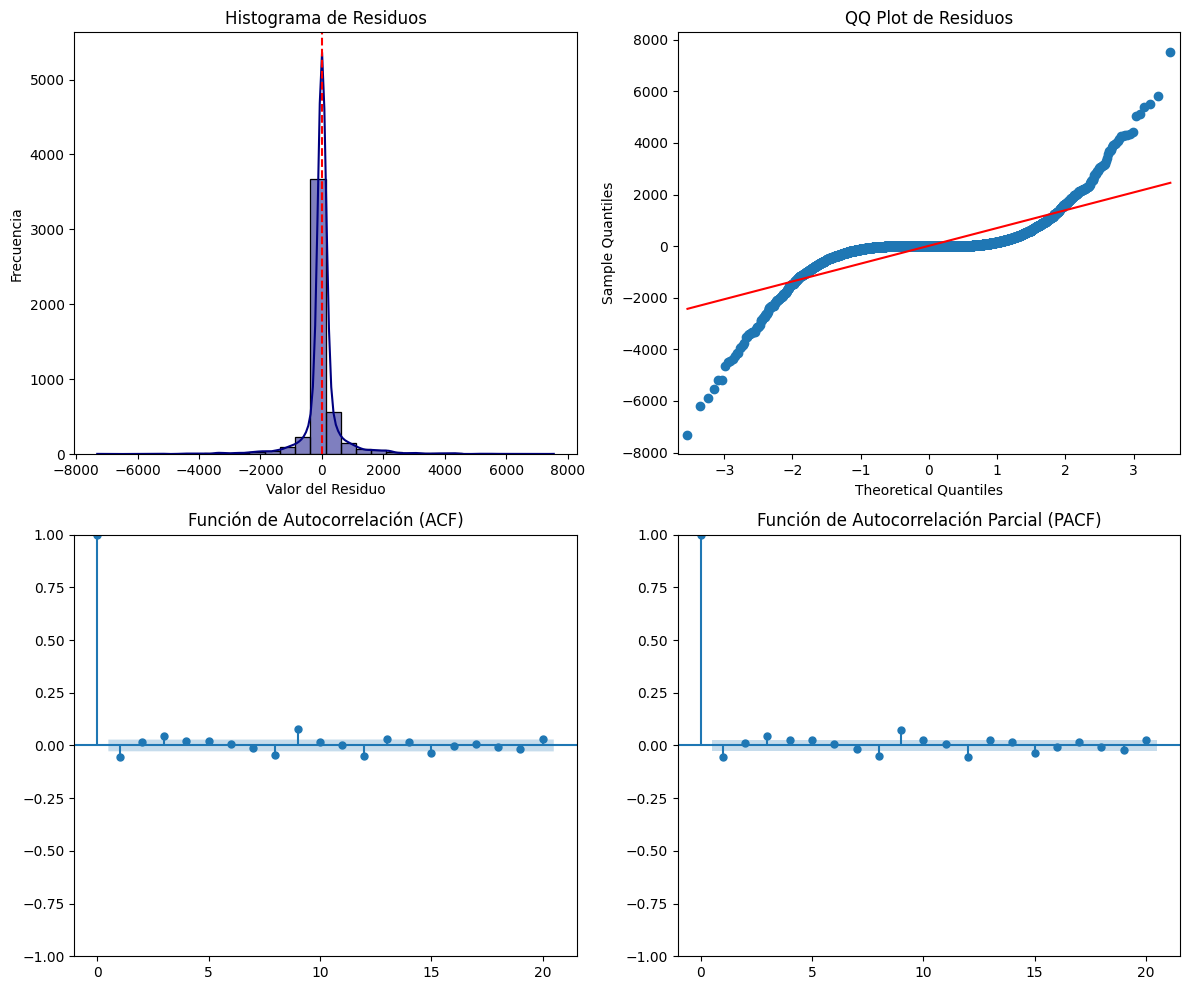

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Price"]]

# Función para calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Función para ARIMA con rolling forecasting
def arima_rolling(df, train_size, val_size, order):
    """
    Implementación de ARIMA con rolling forecasting sin ventanas fijas.

    Parámetros:
    - df: DataFrame con la serie temporal.
    - train_size: Tamaño del conjunto de entrenamiento en número de observaciones.
    - val_size: Tamaño del conjunto de validación en número de observaciones.
    - order: Orden del modelo ARIMA (p, d, q).

    Retorna:
    - Diccionario con métricas de error y predicciones.
    """
    # Dividir los datos en entrenamiento, validación y prueba
    train = df['Price'][:train_size].tolist()
    val = df['Price'][train_size:train_size + val_size].tolist()
    test = df['Price'][train_size + val_size:].tolist()

    val_dates = df.index[train_size:train_size + val_size]
    test_dates = df.index[train_size + val_size:]

    # Predicciones en validación y test con rolling forecasting
    val_predictions = []
    test_predictions = []

    # Fase de validación (rolling forecasting)
    for t in range(len(val)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        val_predictions.append(forecast)
        train.append(val[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en validación
    mae_val = mean_absolute_error(val, val_predictions)
    mse_val = mean_squared_error(val, val_predictions)
    rmse_val = np.sqrt(mse_val)
    mape_val = mean_absolute_percentage_error(val, val_predictions)
    r2_val = r2_score(val, val_predictions)

    # Fase de test (rolling forecasting)
    for t in range(len(test)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        test_predictions.append(forecast)
        train.append(test[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en test
    mae_test = mean_absolute_error(test, test_predictions)
    mse_test = mean_squared_error(test, test_predictions)
    rmse_test = np.sqrt(mse_test)
    mape_test = mean_absolute_percentage_error(test, test_predictions)
    r2_test = r2_score(test, test_predictions)

    # Visualización del modelo ARIMA
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=df.index[:train_size], y=df['Price'][:train_size], label="Train", color='blue')
    sns.lineplot(x=val_dates, y=val, label="Validation", color='orange')
    sns.lineplot(x=test_dates, y=test, label="Test", color='green')
    sns.lineplot(x=val_dates, y=val_predictions, label="Forecast Validation", linestyle='dashed', color='red')
    sns.lineplot(x=test_dates, y=test_predictions, label="Forecast Test", linestyle='dashed', color='purple')
    plt.xlabel("Fecha")
    plt.ylabel("Price")
    plt.title("Predicción ARIMA con Rolling Forecasting")
    plt.legend()
    plt.show()

    return {
        "validación": {"MAPE": mape_val, "MAE": mae_val, "MSE": mse_val, "RMSE": rmse_val, "R²": r2_val},
        "test": {"MAPE": mape_test, "MAE": mae_test, "MSE": mse_test, "RMSE": rmse_test, "R²": r2_test},
        "residuals": model_fit.resid  # Se retornan los residuos para la segunda parte
    }

# Definir los tamaños de los conjuntos
train_size = int(len(df) * 0.6)  # 60% entrenamiento
val_size = int(len(df) * 0.2)  # 20% validación
test_size = len(df) - (train_size + val_size)  # 20% test

# Parámetros del modelo ARIMA
best_order = (0, 1, 0)  # Se puede ajustar según análisis previo

# Ejecutar el modelo con rolling forecasting
resultados = arima_rolling(df, train_size, val_size, best_order)

# Guardar los residuos para la segunda parte
residuals = resultados["residuals"]

# Pruebas estadísticas sobre residuos
ljung_box_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
jarque_bera_pvalue = jarque_bera(residuals)[1]

# Mostrar métricas
print("\nErrores en validación:")
for metric, value in resultados["validación"].items():
    print(f"{metric}: {value:.4f}")

print("\nErrores en test:")
for metric, value in resultados["test"].items():
    print(f"{metric}: {value:.4f}")

print("\nPruebas de hipótesis sobre residuos:")
print(f"Ljung-Box (p-value): {ljung_box_pvalue:.4f}")
print(f"Jarque-Bera (p-value): {jarque_bera_pvalue:.4f}")

# Configurar la figura en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma de residuos
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 0], color='navy')
axes[0, 0].axvline(x=0, color='red', linestyle='dashed')  # Línea vertical en 0
axes[0, 0].set_title("Histograma de Residuos")
axes[0, 0].set_xlabel("Valor del Residuo")
axes[0, 0].set_ylabel("Frecuencia")

# QQPlot de los residuos
sm.qqplot(residuals, line='s', ax=axes[0, 1])
axes[0, 1].set_title("QQ Plot de Residuos")

# Autocorrelación de residuos (ACF)
plot_acf(residuals, ax=axes[1, 0], lags=20)
axes[1, 0].set_title("Función de Autocorrelación (ACF)")

# Autocorrelación parcial de residuos (PACF)
plot_pacf(residuals, ax=axes[1, 1], lags=20)
axes[1, 1].set_title("Función de Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()

Retorno Acumulado

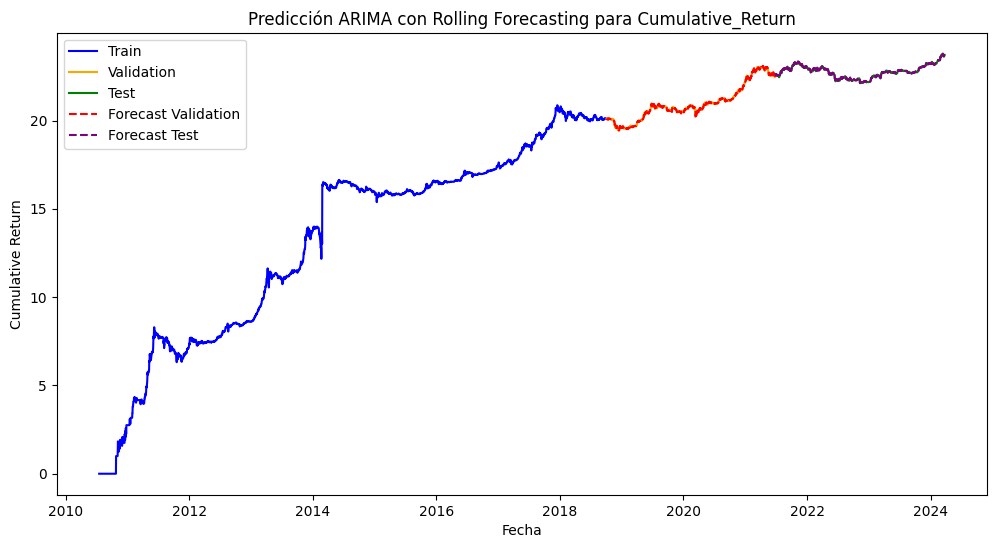


Errores en validación:
MAPE: 0.1248
MAE: 0.0263
MSE: 0.0016
RMSE: 0.0403
R²: 0.9983

Errores en test:
MAPE: 0.0913
MAE: 0.0208
MSE: 0.0009
RMSE: 0.0302
R²: 0.9926

Pruebas de hipótesis sobre residuos:
Ljung-Box (p-value): 0.0000
Jarque-Bera (p-value): 0.0000


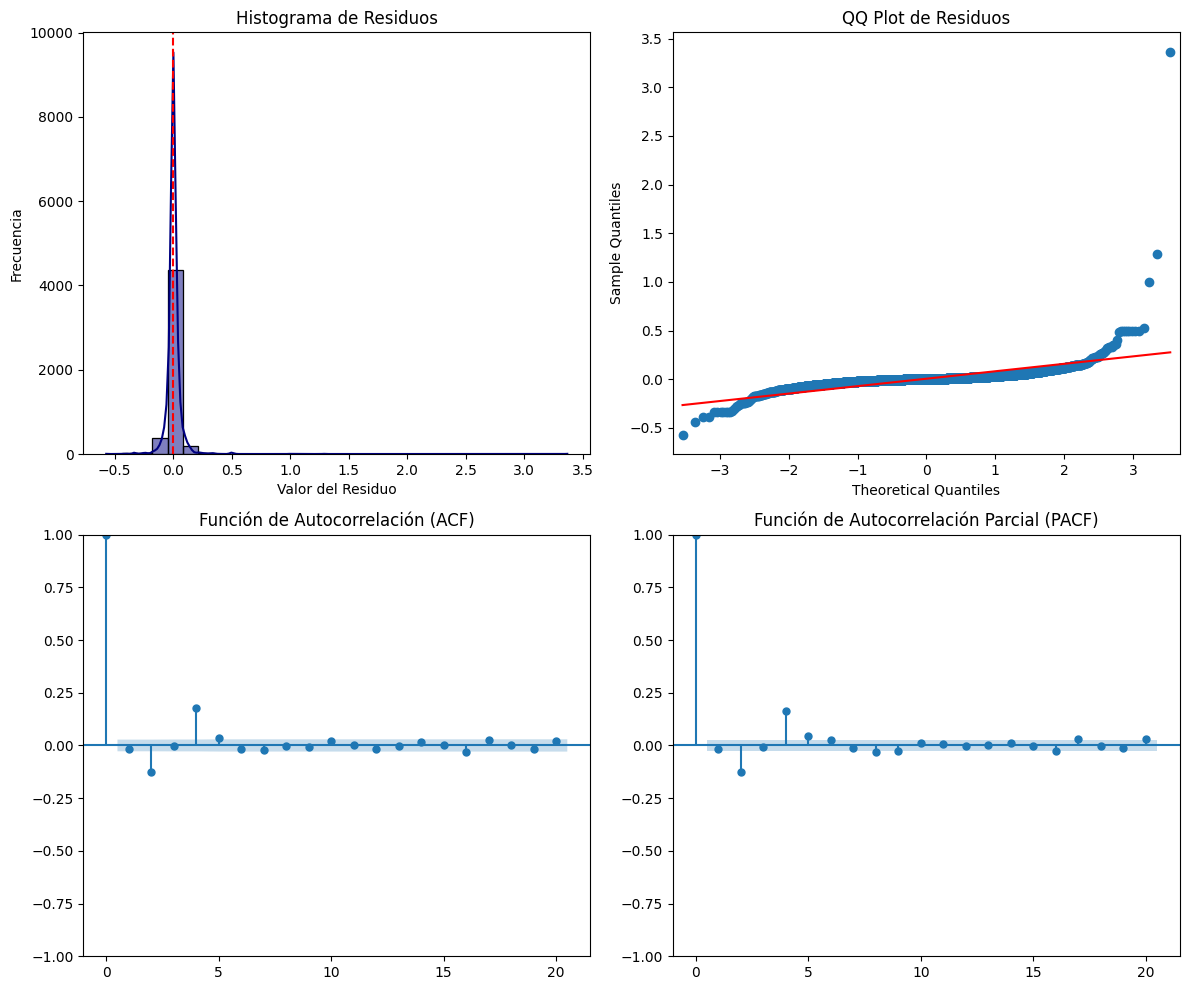

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Cumulative_Return"]]

# Función para calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Función para ARIMA con rolling forecasting
def arima_rolling(df, train_size, val_size, order):
    """
    Implementación de ARIMA con rolling forecasting sin ventanas fijas.

    Parámetros:
    - df: DataFrame con la serie temporal.
    - train_size: Tamaño del conjunto de entrenamiento en número de observaciones.
    - val_size: Tamaño del conjunto de validación en número de observaciones.
    - order: Orden del modelo ARIMA (p, d, q).

    Retorna:
    - Diccionario con métricas de error y predicciones.
    """
    # Dividir los datos en entrenamiento, validación y prueba
    train = df['Cumulative_Return'][:train_size].tolist()
    val = df['Cumulative_Return'][train_size:train_size + val_size].tolist()
    test = df['Cumulative_Return'][train_size + val_size:].tolist()

    val_dates = df.index[train_size:train_size + val_size]
    test_dates = df.index[train_size + val_size:]

    # Predicciones en validación y test con rolling forecasting
    val_predictions = []
    test_predictions = []

    # Fase de validación (rolling forecasting)
    for t in range(len(val)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        val_predictions.append(forecast)
        train.append(val[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en validación
    mae_val = mean_absolute_error(val, val_predictions)
    mse_val = mean_squared_error(val, val_predictions)
    rmse_val = np.sqrt(mse_val)
    mape_val = mean_absolute_percentage_error(val, val_predictions)
    r2_val = r2_score(val, val_predictions)

    # Fase de test (rolling forecasting)
    for t in range(len(test)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        test_predictions.append(forecast)
        train.append(test[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en test
    mae_test = mean_absolute_error(test, test_predictions)
    mse_test = mean_squared_error(test, test_predictions)
    rmse_test = np.sqrt(mse_test)
    mape_test = mean_absolute_percentage_error(test, test_predictions)
    r2_test = r2_score(test, test_predictions)

    # Visualización del modelo ARIMA
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=df.index[:train_size], y=df['Cumulative_Return'][:train_size], label="Train", color='blue')
    sns.lineplot(x=val_dates, y=val, label="Validation", color='orange')
    sns.lineplot(x=test_dates, y=test, label="Test", color='green')
    sns.lineplot(x=val_dates, y=val_predictions, label="Forecast Validation", linestyle='dashed', color='red')
    sns.lineplot(x=test_dates, y=test_predictions, label="Forecast Test", linestyle='dashed', color='purple')
    plt.xlabel("Fecha")
    plt.ylabel("Cumulative Return")
    plt.title("Predicción ARIMA con Rolling Forecasting para Cumulative_Return")
    plt.legend()
    plt.show()

    return {
        "validación": {"MAPE": mape_val, "MAE": mae_val, "MSE": mse_val, "RMSE": rmse_val, "R²": r2_val},
        "test": {"MAPE": mape_test, "MAE": mae_test, "MSE": mse_test, "RMSE": rmse_test, "R²": r2_test},
        "residuals": model_fit.resid  # Se retornan los residuos para la segunda parte
    }

# Definir los tamaños de los conjuntos
train_size = int(len(df) * 0.6)  # 60% entrenamiento
val_size = int(len(df) * 0.2)  # 20% validación
test_size = len(df) - (train_size + val_size)  # 20% test

# Parámetros del modelo ARIMA
best_order = (0, 1, 0)  # Se puede ajustar según análisis previo

# Ejecutar el modelo con rolling forecasting para `Cumulative_Return`
resultados = arima_rolling(df, train_size, val_size, best_order)

# Guardar los residuos para la segunda parte
residuals = resultados["residuals"]

# Pruebas estadísticas sobre residuos
ljung_box_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
jarque_bera_pvalue = jarque_bera(residuals)[1]

# Mostrar métricas
print("\nErrores en validación:")
for metric, value in resultados["validación"].items():
    print(f"{metric}: {value:.4f}")

print("\nErrores en test:")
for metric, value in resultados["test"].items():
    print(f"{metric}: {value:.4f}")

print("\nPruebas de hipótesis sobre residuos:")
print(f"Ljung-Box (p-value): {ljung_box_pvalue:.4f}")
print(f"Jarque-Bera (p-value): {jarque_bera_pvalue:.4f}")

# Configurar la figura en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma de residuos
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 0], color='navy')
axes[0, 0].axvline(x=0, color='red', linestyle='dashed')  # Línea vertical en 0
axes[0, 0].set_title("Histograma de Residuos")
axes[0, 0].set_xlabel("Valor del Residuo")
axes[0, 0].set_ylabel("Frecuencia")

# QQPlot de los residuos
sm.qqplot(residuals, line='s', ax=axes[0, 1])
axes[0, 1].set_title("QQ Plot de Residuos")

# Autocorrelación de residuos (ACF)
plot_acf(residuals, ax=axes[1, 0], lags=20)
axes[1, 0].set_title("Función de Autocorrelación (ACF)")

# Autocorrelación parcial de residuos (PACF)
plot_pacf(residuals, ax=axes[1, 1], lags=20)
axes[1, 1].set_title("Función de Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()

Volatilidad 07 dias

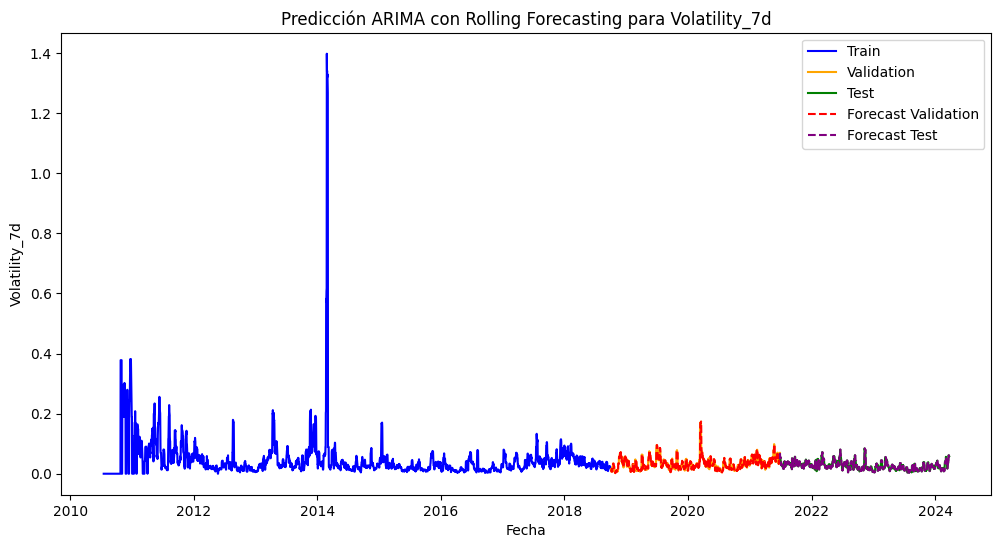


Errores en validación:
MAPE: 15.6527
MAE: 0.0045
MSE: 0.0001
RMSE: 0.0087
R²: 0.8275

Errores en test:
MAPE: 15.1739
MAE: 0.0035
MSE: 0.0000
RMSE: 0.0060
R²: 0.8001

Pruebas de hipótesis sobre residuos:
Ljung-Box (p-value): 0.0000
Jarque-Bera (p-value): 0.0000


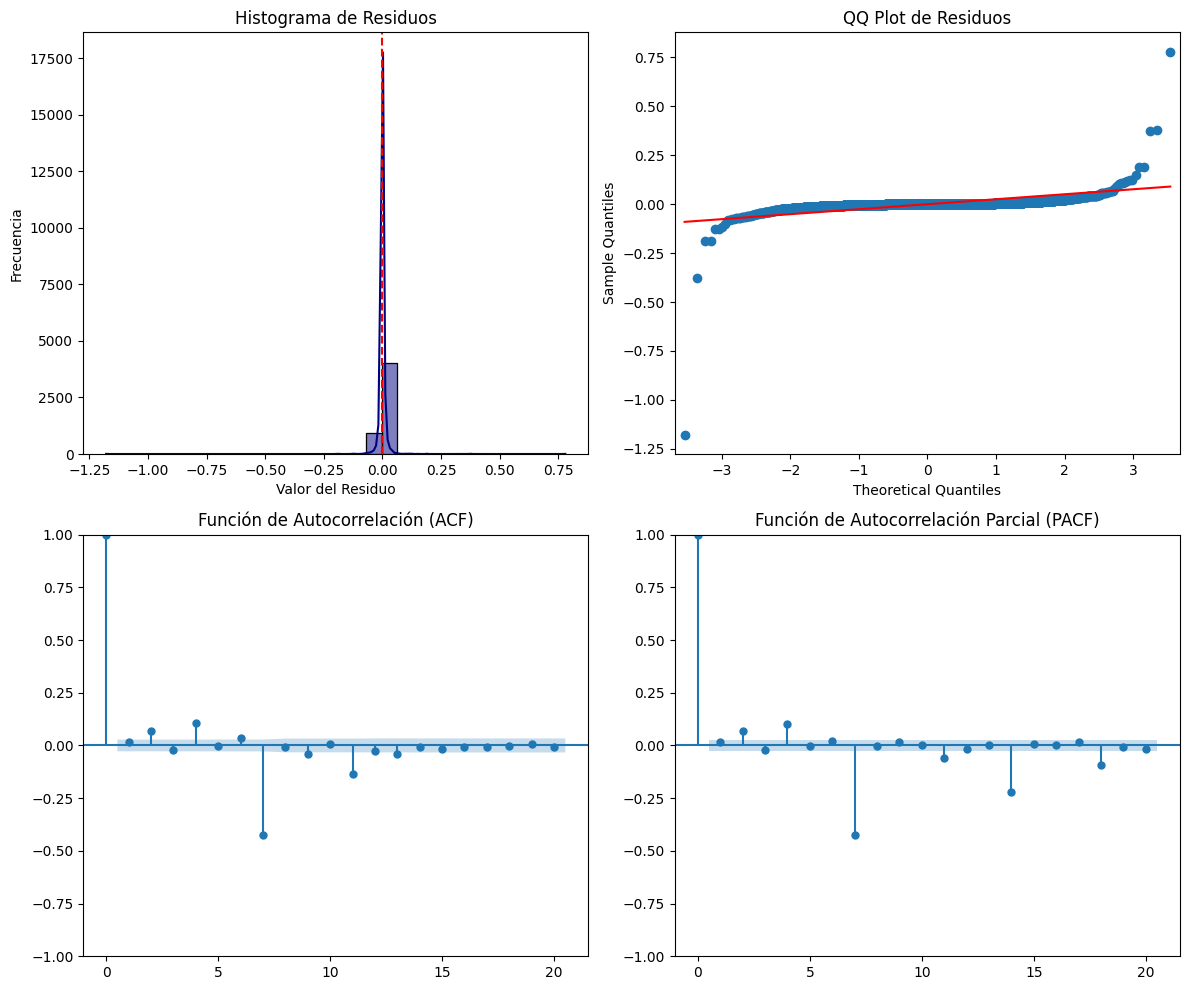

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Volatility_7d"]]

# Función para calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Función para ARIMA con rolling forecasting
def arima_rolling(df, train_size, val_size, order):
    """
    Implementación de ARIMA con rolling forecasting sin ventanas fijas.

    Parámetros:
    - df: DataFrame con la serie temporal.
    - train_size: Tamaño del conjunto de entrenamiento en número de observaciones.
    - val_size: Tamaño del conjunto de validación en número de observaciones.
    - order: Orden del modelo ARIMA (p, d, q).

    Retorna:
    - Diccionario con métricas de error y predicciones.
    """
    # Dividir los datos en entrenamiento, validación y prueba
    train = df['Volatility_7d'][:train_size].tolist()
    val = df['Volatility_7d'][train_size:train_size + val_size].tolist()
    test = df['Volatility_7d'][train_size + val_size:].tolist()

    val_dates = df.index[train_size:train_size + val_size]
    test_dates = df.index[train_size + val_size:]

    # Predicciones en validación y test con rolling forecasting
    val_predictions = []
    test_predictions = []

    # Fase de validación (rolling forecasting)
    for t in range(len(val)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        val_predictions.append(forecast)
        train.append(val[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en validación
    mae_val = mean_absolute_error(val, val_predictions)
    mse_val = mean_squared_error(val, val_predictions)
    rmse_val = np.sqrt(mse_val)
    mape_val = mean_absolute_percentage_error(val, val_predictions)
    r2_val = r2_score(val, val_predictions)

    # Fase de test (rolling forecasting)
    for t in range(len(test)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        test_predictions.append(forecast)
        train.append(test[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en test
    mae_test = mean_absolute_error(test, test_predictions)
    mse_test = mean_squared_error(test, test_predictions)
    rmse_test = np.sqrt(mse_test)
    mape_test = mean_absolute_percentage_error(test, test_predictions)
    r2_test = r2_score(test, test_predictions)

    # Visualización del modelo ARIMA
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=df.index[:train_size], y=df['Volatility_7d'][:train_size], label="Train", color='blue')
    sns.lineplot(x=val_dates, y=val, label="Validation", color='orange')
    sns.lineplot(x=test_dates, y=test, label="Test", color='green')
    sns.lineplot(x=val_dates, y=val_predictions, label="Forecast Validation", linestyle='dashed', color='red')
    sns.lineplot(x=test_dates, y=test_predictions, label="Forecast Test", linestyle='dashed', color='purple')
    plt.xlabel("Fecha")
    plt.ylabel("Volatility_7d")
    plt.title("Predicción ARIMA con Rolling Forecasting para Volatility_7d")
    plt.legend()
    plt.show()

    return {
        "validación": {"MAPE": mape_val, "MAE": mae_val, "MSE": mse_val, "RMSE": rmse_val, "R²": r2_val},
        "test": {"MAPE": mape_test, "MAE": mae_test, "MSE": mse_test, "RMSE": rmse_test, "R²": r2_test},
        "residuals": model_fit.resid  # Se retornan los residuos para la segunda parte
    }

# Definir los tamaños de los conjuntos
train_size = int(len(df) * 0.6)  # 60% entrenamiento
val_size = int(len(df) * 0.2)  # 20% validación
test_size = len(df) - (train_size + val_size)  # 20% test

# Parámetros del modelo ARIMA
best_order = (0, 1, 0)  # Se puede ajustar según análisis previo

# Ejecutar el modelo con rolling forecasting para `Volatility_7d`
resultados = arima_rolling(df, train_size, val_size, best_order)

# Guardar los residuos para la segunda parte
residuals = resultados["residuals"]

# Pruebas estadísticas sobre residuos
ljung_box_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
jarque_bera_pvalue = jarque_bera(residuals)[1]

# Mostrar métricas
print("\nErrores en validación:")
for metric, value in resultados["validación"].items():
    print(f"{metric}: {value:.4f}")

print("\nErrores en test:")
for metric, value in resultados["test"].items():
    print(f"{metric}: {value:.4f}")

print("\nPruebas de hipótesis sobre residuos:")
print(f"Ljung-Box (p-value): {ljung_box_pvalue:.4f}")
print(f"Jarque-Bera (p-value): {jarque_bera_pvalue:.4f}")

# Configurar la figura en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma de residuos
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 0], color='navy')
axes[0, 0].axvline(x=0, color='red', linestyle='dashed')  # Línea vertical en 0
axes[0, 0].set_title("Histograma de Residuos")
axes[0, 0].set_xlabel("Valor del Residuo")
axes[0, 0].set_ylabel("Frecuencia")

# QQPlot de los residuos
sm.qqplot(residuals, line='s', ax=axes[0, 1])
axes[0, 1].set_title("QQ Plot de Residuos")

# Autocorrelación de residuos (ACF)
plot_acf(residuals, ax=axes[1, 0], lags=20)
axes[1, 0].set_title("Función de Autocorrelación (ACF)")

# Autocorrelación parcial de residuos (PACF)
plot_pacf(residuals, ax=axes[1, 1], lags=20)
axes[1, 1].set_title("Función de Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()

Volatilidad 14 dias

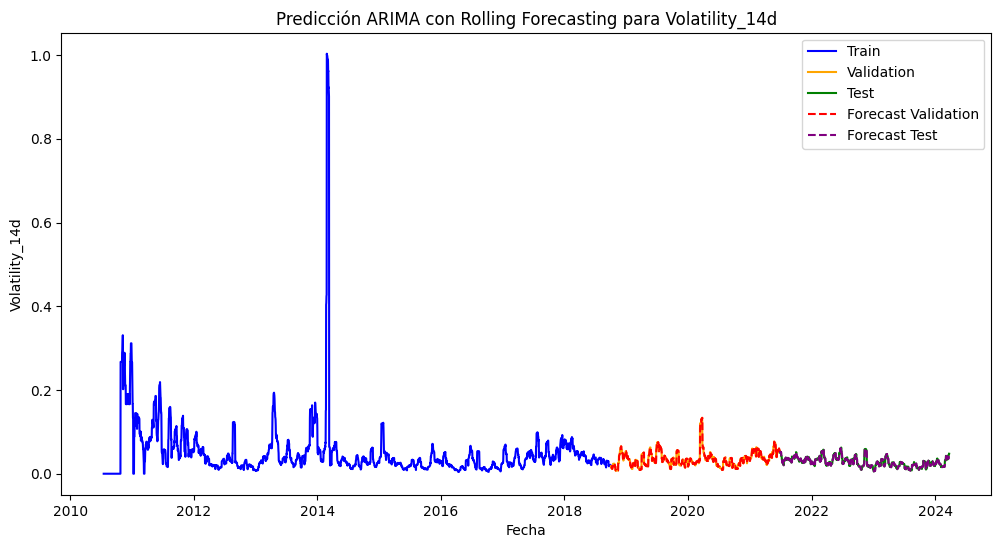


Errores en validación:
MAPE: 6.7126
MAE: 0.0022
MSE: 0.0000
RMSE: 0.0051
R²: 0.9211

Errores en test:
MAPE: 6.1758
MAE: 0.0016
MSE: 0.0000
RMSE: 0.0030
R²: 0.9284

Pruebas de hipótesis sobre residuos:
Ljung-Box (p-value): 0.0000
Jarque-Bera (p-value): 0.0000


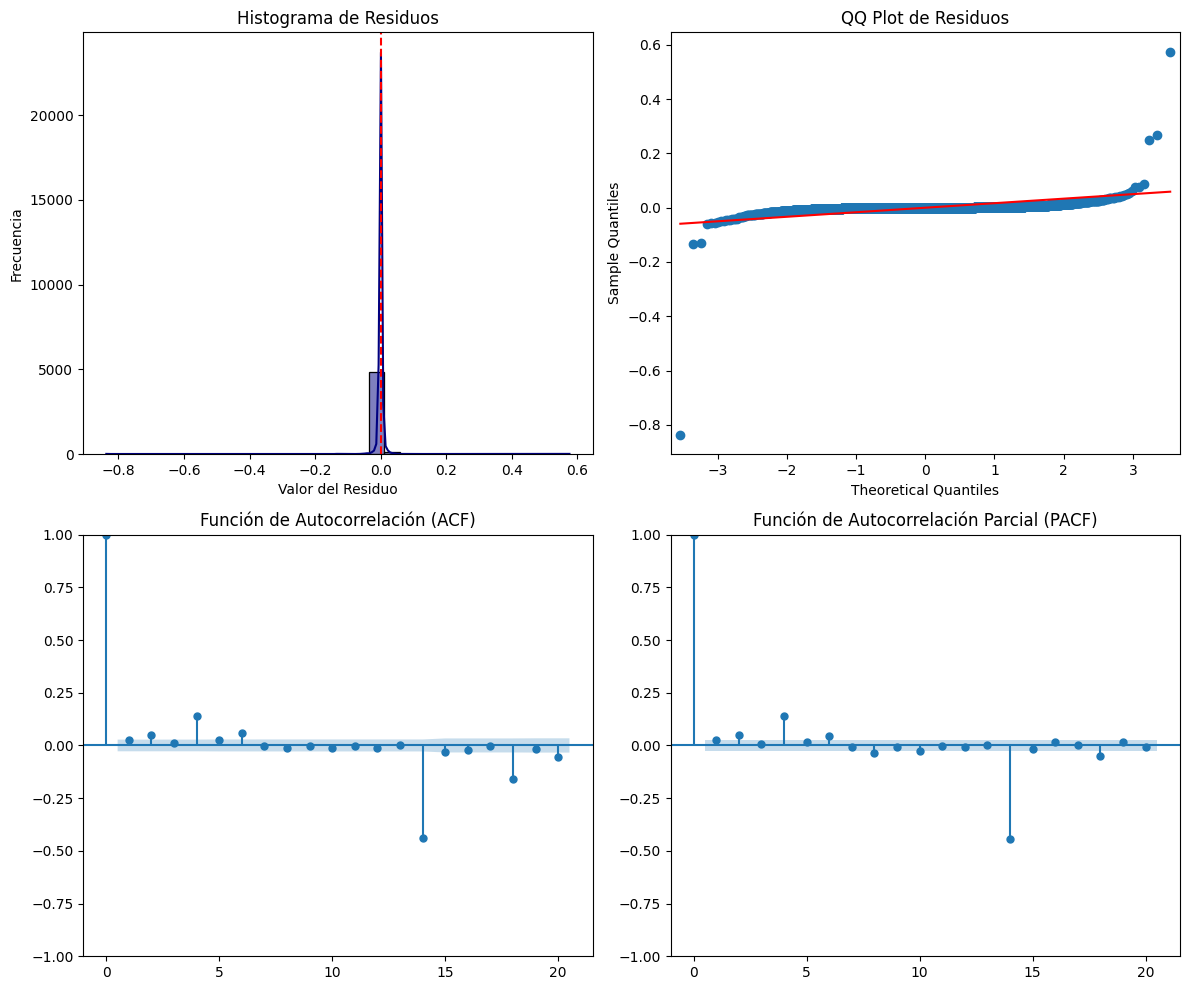

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Volatility_14d"]]

# Función para calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Función para ARIMA con rolling forecasting
def arima_rolling(df, train_size, val_size, order):
    """
    Implementación de ARIMA con rolling forecasting sin ventanas fijas.

    Parámetros:
    - df: DataFrame con la serie temporal.
    - train_size: Tamaño del conjunto de entrenamiento en número de observaciones.
    - val_size: Tamaño del conjunto de validación en número de observaciones.
    - order: Orden del modelo ARIMA (p, d, q).

    Retorna:
    - Diccionario con métricas de error y predicciones.
    """
    # Dividir los datos en entrenamiento, validación y prueba
    train = df['Volatility_14d'][:train_size].tolist()
    val = df['Volatility_14d'][train_size:train_size + val_size].tolist()
    test = df['Volatility_14d'][train_size + val_size:].tolist()

    val_dates = df.index[train_size:train_size + val_size]
    test_dates = df.index[train_size + val_size:]

    # Predicciones en validación y test con rolling forecasting
    val_predictions = []
    test_predictions = []

    # Fase de validación (rolling forecasting)
    for t in range(len(val)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        val_predictions.append(forecast)
        train.append(val[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en validación
    mae_val = mean_absolute_error(val, val_predictions)
    mse_val = mean_squared_error(val, val_predictions)
    rmse_val = np.sqrt(mse_val)
    mape_val = mean_absolute_percentage_error(val, val_predictions)
    r2_val = r2_score(val, val_predictions)

    # Fase de test (rolling forecasting)
    for t in range(len(test)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        test_predictions.append(forecast)
        train.append(test[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en test
    mae_test = mean_absolute_error(test, test_predictions)
    mse_test = mean_squared_error(test, test_predictions)
    rmse_test = np.sqrt(mse_test)
    mape_test = mean_absolute_percentage_error(test, test_predictions)
    r2_test = r2_score(test, test_predictions)

    # Visualización del modelo ARIMA
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=df.index[:train_size], y=df['Volatility_14d'][:train_size], label="Train", color='blue')
    sns.lineplot(x=val_dates, y=val, label="Validation", color='orange')
    sns.lineplot(x=test_dates, y=test, label="Test", color='green')
    sns.lineplot(x=val_dates, y=val_predictions, label="Forecast Validation", linestyle='dashed', color='red')
    sns.lineplot(x=test_dates, y=test_predictions, label="Forecast Test", linestyle='dashed', color='purple')
    plt.xlabel("Fecha")
    plt.ylabel("Volatility_14d")
    plt.title("Predicción ARIMA con Rolling Forecasting para Volatility_14d")
    plt.legend()
    plt.show()

    return {
        "validación": {"MAPE": mape_val, "MAE": mae_val, "MSE": mse_val, "RMSE": rmse_val, "R²": r2_val},
        "test": {"MAPE": mape_test, "MAE": mae_test, "MSE": mse_test, "RMSE": rmse_test, "R²": r2_test},
        "residuals": model_fit.resid  # Se retornan los residuos para la segunda parte
    }

# Definir los tamaños de los conjuntos
train_size = int(len(df) * 0.6)  # 60% entrenamiento
val_size = int(len(df) * 0.2)  # 20% validación
test_size = len(df) - (train_size + val_size)  # 20% test

# Parámetros del modelo ARIMA
best_order = (0, 1, 0)  # Se puede ajustar según análisis previo

# Ejecutar el modelo con rolling forecasting para `Volatility_14d`
resultados = arima_rolling(df, train_size, val_size, best_order)

# Guardar los residuos para la segunda parte
residuals = resultados["residuals"]

# Pruebas estadísticas sobre residuos
ljung_box_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
jarque_bera_pvalue = jarque_bera(residuals)[1]

# Mostrar métricas
print("\nErrores en validación:")
for metric, value in resultados["validación"].items():
    print(f"{metric}: {value:.4f}")

print("\nErrores en test:")
for metric, value in resultados["test"].items():
    print(f"{metric}: {value:.4f}")

print("\nPruebas de hipótesis sobre residuos:")
print(f"Ljung-Box (p-value): {ljung_box_pvalue:.4f}")
print(f"Jarque-Bera (p-value): {jarque_bera_pvalue:.4f}")

# Configurar la figura en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma de residuos
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 0], color='navy')
axes[0, 0].axvline(x=0, color='red', linestyle='dashed')  # Línea vertical en 0
axes[0, 0].set_title("Histograma de Residuos")
axes[0, 0].set_xlabel("Valor del Residuo")
axes[0, 0].set_ylabel("Frecuencia")

# QQPlot de los residuos
sm.qqplot(residuals, line='s', ax=axes[0, 1])
axes[0, 1].set_title("QQ Plot de Residuos")

# Autocorrelación de residuos (ACF)
plot_acf(residuals, ax=axes[1, 0], lags=20)
axes[1, 0].set_title("Función de Autocorrelación (ACF)")

# Autocorrelación parcial de residuos (PACF)
plot_pacf(residuals, ax=axes[1, 1], lags=20)
axes[1, 1].set_title("Función de Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()

Volatilidad 21 dias

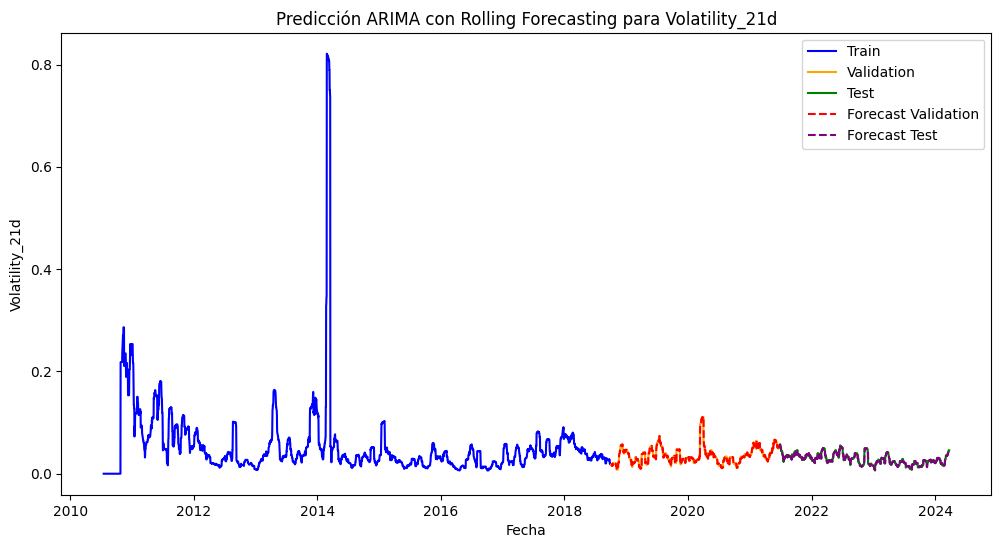


Errores en validación:
MAPE: 4.5014
MAE: 0.0015
MSE: 0.0000
RMSE: 0.0037
R²: 0.9510

Errores en test:
MAPE: 4.2776
MAE: 0.0011
MSE: 0.0000
RMSE: 0.0022
R²: 0.9523

Pruebas de hipótesis sobre residuos:
Ljung-Box (p-value): 0.0000
Jarque-Bera (p-value): 0.0000


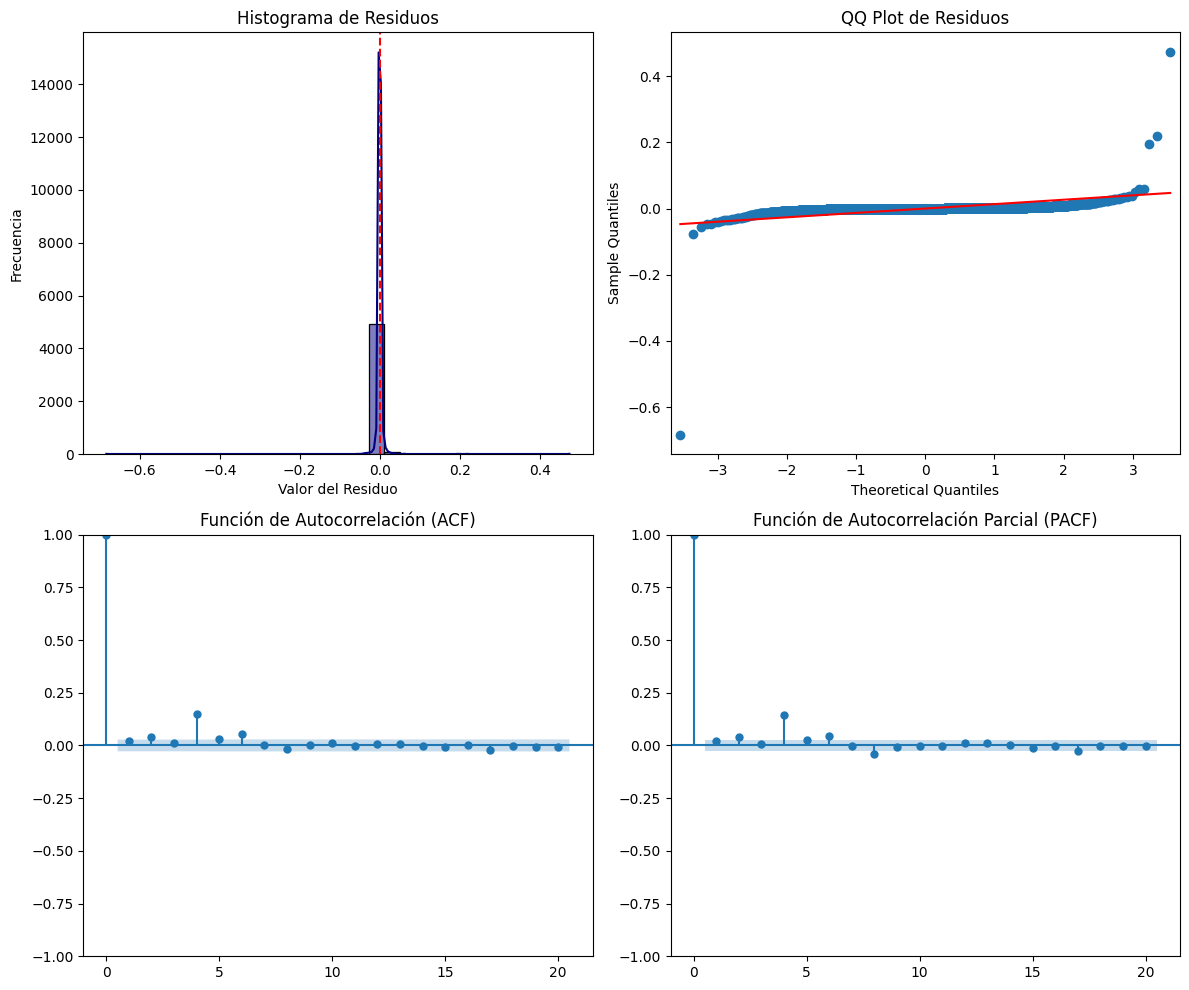

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Volatility_21d"]]

# Función para calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Función para ARIMA con rolling forecasting
def arima_rolling(df, train_size, val_size, order):
    """
    Implementación de ARIMA con rolling forecasting sin ventanas fijas.

    Parámetros:
    - df: DataFrame con la serie temporal.
    - train_size: Tamaño del conjunto de entrenamiento en número de observaciones.
    - val_size: Tamaño del conjunto de validación en número de observaciones.
    - order: Orden del modelo ARIMA (p, d, q).

    Retorna:
    - Diccionario con métricas de error y predicciones.
    """
    # Dividir los datos en entrenamiento, validación y prueba
    train = df['Volatility_21d'][:train_size].tolist()
    val = df['Volatility_21d'][train_size:train_size + val_size].tolist()
    test = df['Volatility_21d'][train_size + val_size:].tolist()

    val_dates = df.index[train_size:train_size + val_size]
    test_dates = df.index[train_size + val_size:]

    # Predicciones en validación y test con rolling forecasting
    val_predictions = []
    test_predictions = []

    # Fase de validación (rolling forecasting)
    for t in range(len(val)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        val_predictions.append(forecast)
        train.append(val[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en validación
    mae_val = mean_absolute_error(val, val_predictions)
    mse_val = mean_squared_error(val, val_predictions)
    rmse_val = np.sqrt(mse_val)
    mape_val = mean_absolute_percentage_error(val, val_predictions)
    r2_val = r2_score(val, val_predictions)

    # Fase de test (rolling forecasting)
    for t in range(len(test)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        test_predictions.append(forecast)
        train.append(test[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en test
    mae_test = mean_absolute_error(test, test_predictions)
    mse_test = mean_squared_error(test, test_predictions)
    rmse_test = np.sqrt(mse_test)
    mape_test = mean_absolute_percentage_error(test, test_predictions)
    r2_test = r2_score(test, test_predictions)

    # Visualización del modelo ARIMA
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=df.index[:train_size], y=df['Volatility_21d'][:train_size], label="Train", color='blue')
    sns.lineplot(x=val_dates, y=val, label="Validation", color='orange')
    sns.lineplot(x=test_dates, y=test, label="Test", color='green')
    sns.lineplot(x=val_dates, y=val_predictions, label="Forecast Validation", linestyle='dashed', color='red')
    sns.lineplot(x=test_dates, y=test_predictions, label="Forecast Test", linestyle='dashed', color='purple')
    plt.xlabel("Fecha")
    plt.ylabel("Volatility_21d")
    plt.title("Predicción ARIMA con Rolling Forecasting para Volatility_21d")
    plt.legend()
    plt.show()

    return {
        "validación": {"MAPE": mape_val, "MAE": mae_val, "MSE": mse_val, "RMSE": rmse_val, "R²": r2_val},
        "test": {"MAPE": mape_test, "MAE": mae_test, "MSE": mse_test, "RMSE": rmse_test, "R²": r2_test},
        "residuals": model_fit.resid  # Se retornan los residuos para la segunda parte
    }

# Definir los tamaños de los conjuntos
train_size = int(len(df) * 0.6)  # 60% entrenamiento
val_size = int(len(df) * 0.2)  # 20% validación
test_size = len(df) - (train_size + val_size)  # 20% test

# Parámetros del modelo ARIMA
best_order = (0, 1, 0)  # Se puede ajustar según análisis previo

# Ejecutar el modelo con rolling forecasting para `Volatility_21d`
resultados = arima_rolling(df, train_size, val_size, best_order)

# Guardar los residuos para la segunda parte
residuals = resultados["residuals"]

# Pruebas estadísticas sobre residuos
ljung_box_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
jarque_bera_pvalue = jarque_bera(residuals)[1]

# Mostrar métricas
print("\nErrores en validación:")
for metric, value in resultados["validación"].items():
    print(f"{metric}: {value:.4f}")

print("\nErrores en test:")
for metric, value in resultados["test"].items():
    print(f"{metric}: {value:.4f}")

print("\nPruebas de hipótesis sobre residuos:")
print(f"Ljung-Box (p-value): {ljung_box_pvalue:.4f}")
print(f"Jarque-Bera (p-value): {jarque_bera_pvalue:.4f}")

# Configurar la figura en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma de residuos
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 0], color='navy')
axes[0, 0].axvline(x=0, color='red', linestyle='dashed')  # Línea vertical en 0
axes[0, 0].set_title("Histograma de Residuos")
axes[0, 0].set_xlabel("Valor del Residuo")
axes[0, 0].set_ylabel("Frecuencia")

# QQPlot de los residuos
sm.qqplot(residuals, line='s', ax=axes[0, 1])
axes[0, 1].set_title("QQ Plot de Residuos")

# Autocorrelación de residuos (ACF)
plot_acf(residuals, ax=axes[1, 0], lags=20)
axes[1, 0].set_title("Función de Autocorrelación (ACF)")

# Autocorrelación parcial de residuos (PACF)
plot_pacf(residuals, ax=axes[1, 1], lags=20)
axes[1, 1].set_title("Función de Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()

Volatilidad 28 dias

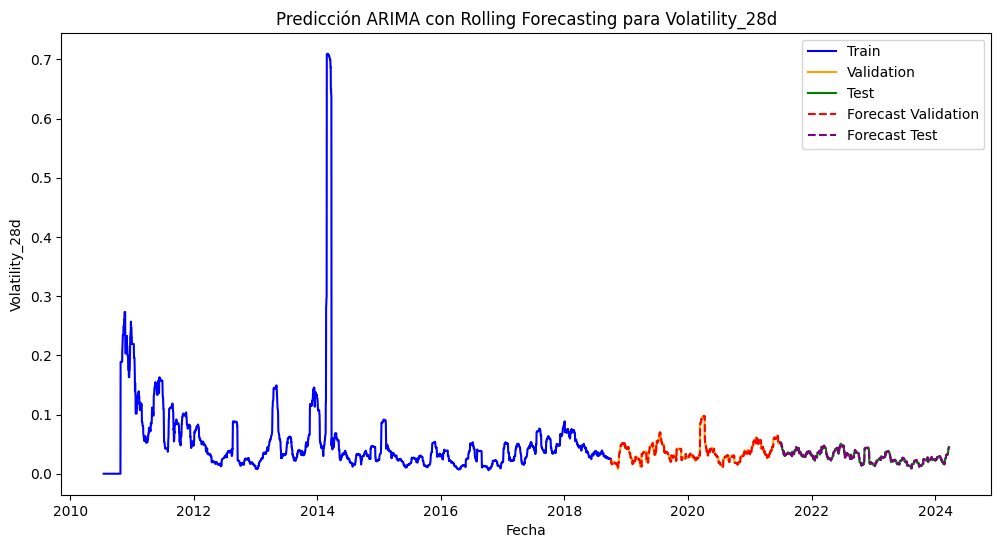


Errores en validación:
MAPE: 3.4979
MAE: 0.0012
MSE: 0.0000
RMSE: 0.0030
R²: 0.9636

Errores en test:
MAPE: 3.0583
MAE: 0.0008
MSE: 0.0000
RMSE: 0.0017
R²: 0.9683

Pruebas de hipótesis sobre residuos:
Ljung-Box (p-value): 0.0000
Jarque-Bera (p-value): 0.0000


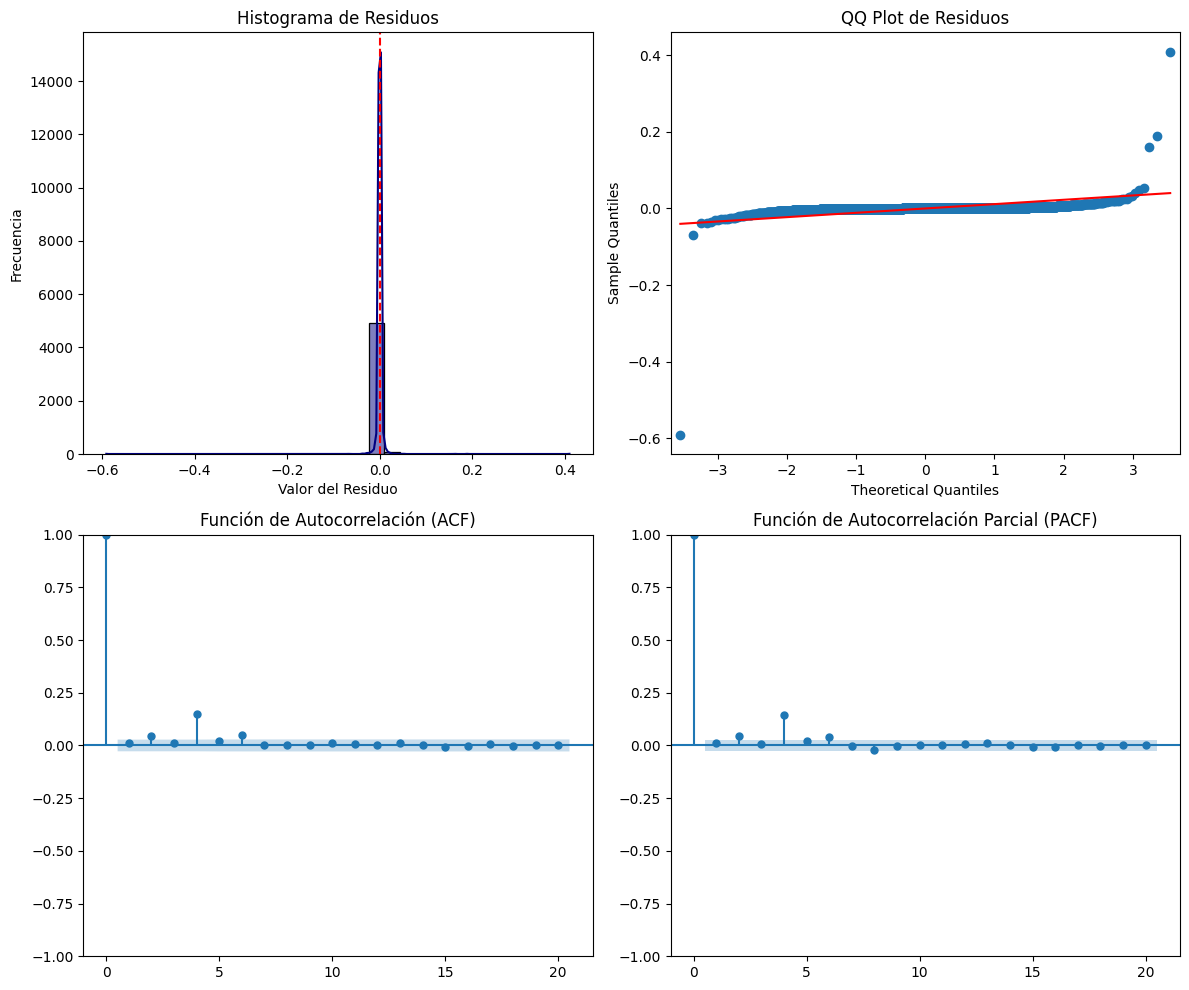

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, q_stat
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

# 1. Lectura de datos y limpieza
data_url = "https://raw.githubusercontent.com/lihkir/Data/refs/heads/main/Bitcoin%20Historical%20Data.csv"
df = pd.read_csv(data_url, parse_dates=['Date'], index_col='Date')

# Ordenar por fecha (índice) en orden ascendente
df.sort_index(inplace=True)

def parse_volume_str(vol_str):
    if not isinstance(vol_str, str):
        return vol_str
    vol_str = vol_str.replace(",", "").strip()
    if vol_str.endswith('K'):
        return float(vol_str[:-1]) * 1e3
    elif vol_str.endswith('M'):
        return float(vol_str[:-1]) * 1e6
    elif vol_str.endswith('B'):
        return float(vol_str[:-1]) * 1e9
    else:
        return float(vol_str)

df["Vol."] = df["Vol."].apply(parse_volume_str)
df["Change %"] = df["Change %"].astype(str).str.replace("%", "").astype(float)
df['Price'] = df['Price'].astype(str).str.replace(',', '').astype(float)
df['High'] = df['High'].astype(str).str.replace(',', '').astype(float)
df['Low'] = df['Low'].astype(str).str.replace(',', '').astype(float)
df['Open'] = df['Open'].astype(str).str.replace(',', '').astype(float)

# Cálculo de retorno (Return)
df["Return"] = df["Price"].pct_change()

# Reemplazar el primer NaN de Return por 0
df["Return"].iloc[0] = 0

# Cálculo de retorno acumulado
df["Cumulative_Return"] = df["Return"].cumsum()

# Cálculo de volatilidad en ventanas móviles
windows = [7, 14, 21, 28]
for w in windows:
    df[f"Volatility_{w}d"] = df["Return"].rolling(window=w, min_periods=1).std()

df.fillna(method='bfill', inplace=True)
df.fillna(method='ffill', inplace=True)
df.rename(columns={'Vol.': 'Volume', 'Change %': 'Change'}, inplace=True)

df = df[["Volatility_28d"]]

# Función para calcular MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Función para ARIMA con rolling forecasting
def arima_rolling(df, train_size, val_size, order):
    """
    Implementación de ARIMA con rolling forecasting sin ventanas fijas.

    Parámetros:
    - df: DataFrame con la serie temporal.
    - train_size: Tamaño del conjunto de entrenamiento en número de observaciones.
    - val_size: Tamaño del conjunto de validación en número de observaciones.
    - order: Orden del modelo ARIMA (p, d, q).

    Retorna:
    - Diccionario con métricas de error y predicciones.
    """
    # Dividir los datos en entrenamiento, validación y prueba
    train = df['Volatility_28d'][:train_size].tolist()
    val = df['Volatility_28d'][train_size:train_size + val_size].tolist()
    test = df['Volatility_28d'][train_size + val_size:].tolist()

    val_dates = df.index[train_size:train_size + val_size]
    test_dates = df.index[train_size + val_size:]

    # Predicciones en validación y test con rolling forecasting
    val_predictions = []
    test_predictions = []

    # Fase de validación (rolling forecasting)
    for t in range(len(val)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        val_predictions.append(forecast)
        train.append(val[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en validación
    mae_val = mean_absolute_error(val, val_predictions)
    mse_val = mean_squared_error(val, val_predictions)
    rmse_val = np.sqrt(mse_val)
    mape_val = mean_absolute_percentage_error(val, val_predictions)
    r2_val = r2_score(val, val_predictions)

    # Fase de test (rolling forecasting)
    for t in range(len(test)):
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]  # Predicción de un solo punto
        test_predictions.append(forecast)
        train.append(test[t])  # Agregar el valor real para continuar el rolling

    # Evaluación en test
    mae_test = mean_absolute_error(test, test_predictions)
    mse_test = mean_squared_error(test, test_predictions)
    rmse_test = np.sqrt(mse_test)
    mape_test = mean_absolute_percentage_error(test, test_predictions)
    r2_test = r2_score(test, test_predictions)

    # Visualización del modelo ARIMA
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=df.index[:train_size], y=df['Volatility_28d'][:train_size], label="Train", color='blue')
    sns.lineplot(x=val_dates, y=val, label="Validation", color='orange')
    sns.lineplot(x=test_dates, y=test, label="Test", color='green')
    sns.lineplot(x=val_dates, y=val_predictions, label="Forecast Validation", linestyle='dashed', color='red')
    sns.lineplot(x=test_dates, y=test_predictions, label="Forecast Test", linestyle='dashed', color='purple')
    plt.xlabel("Fecha")
    plt.ylabel("Volatility_28d")
    plt.title("Predicción ARIMA con Rolling Forecasting para Volatility_28d")
    plt.legend()
    plt.show()

    return {
        "validación": {"MAPE": mape_val, "MAE": mae_val, "MSE": mse_val, "RMSE": rmse_val, "R²": r2_val},
        "test": {"MAPE": mape_test, "MAE": mae_test, "MSE": mse_test, "RMSE": rmse_test, "R²": r2_test},
        "residuals": model_fit.resid  # Se retornan los residuos para la segunda parte
    }

# Definir los tamaños de los conjuntos
train_size = int(len(df) * 0.6)  # 60% entrenamiento
val_size = int(len(df) * 0.2)  # 20% validación
test_size = len(df) - (train_size + val_size)  # 20% test

# Parámetros del modelo ARIMA
best_order = (0, 1, 0)  # Se puede ajustar según análisis previo

# Ejecutar el modelo con rolling forecasting para `Volatility_28d`
resultados = arima_rolling(df, train_size, val_size, best_order)

# Guardar los residuos para la segunda parte
residuals = resultados["residuals"]

# Pruebas estadísticas sobre residuos
ljung_box_pvalue = acorr_ljungbox(residuals, lags=[10], return_df=True)['lb_pvalue'].values[0]
jarque_bera_pvalue = jarque_bera(residuals)[1]

# Mostrar métricas
print("\nErrores en validación:")
for metric, value in resultados["validación"].items():
    print(f"{metric}: {value:.4f}")

print("\nErrores en test:")
for metric, value in resultados["test"].items():
    print(f"{metric}: {value:.4f}")

print("\nPruebas de hipótesis sobre residuos:")
print(f"Ljung-Box (p-value): {ljung_box_pvalue:.4f}")
print(f"Jarque-Bera (p-value): {jarque_bera_pvalue:.4f}")

# Configurar la figura en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histograma de residuos
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 0], color='navy')
axes[0, 0].axvline(x=0, color='red', linestyle='dashed')  # Línea vertical en 0
axes[0, 0].set_title("Histograma de Residuos")
axes[0, 0].set_xlabel("Valor del Residuo")
axes[0, 0].set_ylabel("Frecuencia")

# QQPlot de los residuos
sm.qqplot(residuals, line='s', ax=axes[0, 1])
axes[0, 1].set_title("QQ Plot de Residuos")

# Autocorrelación de residuos (ACF)
plot_acf(residuals, ax=axes[1, 0], lags=20)
axes[1, 0].set_title("Función de Autocorrelación (ACF)")

# Autocorrelación parcial de residuos (PACF)
plot_pacf(residuals, ax=axes[1, 1], lags=20)
axes[1, 1].set_title("Función de Autocorrelación Parcial (PACF)")

plt.tight_layout()
plt.show()